
# EXECUTIVE SUMMARY

<div style="text-align: justify;">

The goal of this project was to work with the Co-operators dataset and utilize its information about customers to predict whether an individual would buy their auto insurance policy. The original dataset consisted of 25 features, and the target variable was `IS_BOUND` which describes whether customers bought the insurance (`IS_BOUND` = 1) or declined (`IS_BOUND` = 0). The total number of customers in the training set were 101,891 and 15,114 in the test set. The dataset had class imbalance: only 22% of the customers bought the insurance.

**Data Pre-processing**: Before evaluating the models mentioned above, significant time was dedicated to exploratory analysis, data pre-processing, and data cleaning due to the dataset's mis-spelled and missing entries. The data were categorized into three sections for cleanup:

* Columns with no missing values: Even though certain columns had no missing values, they had mis-spelled entries. For eg., the column with vehicle make information had multiple mis-spelled entries for the same make:
    "CEVROLET", 'CHCVIOE', 'CHERVOLET', 'CHEV', 'CHEVRELOT', 'CHEVROELT', 'CHEVROLE', 'CHEVROLER', 'CHEVY'
were entered in the dataset for the same make: 'CHEVROLET'. We created a function which rectifies these data entry errors for vehicle makes. Another example was the column containing area code information. Thousands of customers had 'Unk' or unknown as their area code. We used the postal code information to fill in missing area code values.

* Columns with missing values: Certain columns such as `YEARS_AS_PRINCIPAL_DRIVER`, `MARKING_SYSTEM` and `TRACKING_SYSTEM` had more than 80% of values missing. We dropped these columns. Other columns such as `YEARS_LICENSED` were completed by utilizing a linear regression model to predict the values based on the `YEAR_OF_BIRTH` column. For missing `MARITAL_STATUS`, we imputed missing values based on the age of the customers since older customers were more likely to be widowed, middle-aged were divorced/separated and young were single.

**Feature Engineering**: We used the PGeocode library in Python to convert POSTAL CODE to latitude and longitude. Since all quotes were made in the year of 2016, the `QUOTEDATE` column was replaced with a `MONTH` column. Dummy variables were generated to account for categorical variables.

These steps aimed to ensure data completeness and construct a more robust dataset for modeling purposes.

**Data Modeling**: After dataset preparation, we analyzed the dataset using two methods. First, we split the dataset into 80% training and 20% holdout validation set. Next, we trained a fine-tuned XGBoost Classifier on the normalized training set. In the second method, we used undersampling to preserve equal class distribution so that the model has equal number of examples of each class to learn from and doesn't overpredict all examples as the majority class. In the second method, we also used the XGBoost classifier to train on the balanced training set. The undersampling method yielded a better performing model with higher precision and recall scores. Therefore, we selected this as our final model. Overall, the model performance is modest given by the ROC AUC of 0.67. The data lacks a strong signal in predicting buyers and should be supplemented with other customer information.

**Feature Importances:** Using chi-square and t-test analysis, we found that auto policies bundled with other products and location (longitude) were the most important features in predicting whether customers buy insurance or not.  

**Test Set**: The models were then used to make predictions on our test set. The same steps were taken to prepare the data for testing, and predictions were made and stored in a list for submission to the leaderboard as part of this project.

In [1]:
# Import the relevant libraries
# DATA pre-processing
import pandas as pd
from collections import Counter
from sklearn.impute import SimpleImputer
import numpy as np
import time
import os

# Data visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pgeocode
import plotly.express as px
from matplotlib.pyplot import figure

# Data Wrangling and Model Building
import package_outlier as po
from scipy import stats
from scipy.stats import pearsonr, ttest_ind, chi2_contingency
from scipy import sparse
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_validate
from imblearn.under_sampling import RandomUnderSampler
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score, roc_curve, make_scorer

In [6]:
# Read the training data from the Excel file
insurance_train_data = pd.read_excel("data/Cooperators_Quotes_Dataset_Training.xlsx")

# Print the shape of the training data
print('shape of train data:', insurance_train_data.shape, '\n')

# Display the first few rows of the training data
insurance_train_data.head()

shape of train data: (101891, 26) 



,QUOTEDATE,VEHICLEYEAR,VEHICLEMAKE,VEHICLEMODEL,ANNUAL_KM,COMMUTE_DISTANCE,MARKING_SYSTEM,TRACKING_SYSTEM,VEHICLE_OWNERSHIP,VEHICLE_VALUE,...,YEARS_AS_PRINCIPAL_DRIVER,MULTI_PRODUCT,MARITAL_STATUS,OCCUPATION,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,SUSPENSION_COUNT,IS_BOUND
0,2016-01-02,2006,VOLKSWAGEN,JETTA 2.5 4P,10000.0,NaN,NaN,NaN,Owned,3000.0,...,10.0,No,Married,Trades,0,0,0,0,0,0
1,2016-01-02,2017,HYUNDAI,ELANTRA GL 4DR,20000.0,NaN,NaN,NaN,Owned,1.0,...,NaN,No,Married,Not Known,0,0,0,0,0,0
2,2016-01-02,2015,CHEVROLET TRUCK/VAN,SILVERADO 2500 HD LT CREW CAB 4WD,15000.0,NaN,NaN,NaN,NaN,NaN,...,NaN,No,Single,Not Known,0,0,0,0,0,0
3,2016-01-02,2010,TOYOTA,COROLLA CE 4DR,20000.0,20.0,NaN,NaN,NaN,NaN,...,NaN,Yes,Single,Not Known,0,0,0,0,0,0
4,2016-01-04,2013,HONDA,CIVIC LX 4DR,30000.0,30.0,NaN,NaN,NaN,NaN,...,NaN,Yes,Single,Not Known,0,0,0,0,0,0


In [7]:
# Read the test data from the Excel file
insurance_test_data = pd.read_excel("data/Cooperators_Quotes_Dataset_Test.xlsx")

# Print the shape of the test data
print('shape of test data:', insurance_test_data.shape, '\n')

# Display the first few rows of the training data
insurance_test_data.head()

shape of test data: (15114, 25) 



,QUOTEDATE,VEHICLEYEAR,VEHICLEMAKE,VEHICLEMODEL,ANNUALKM,COMMUTEDISTANCE,MARKINGSYSTEM,TRACKINGSYSTEM,VEHICLEOWNERSHIP,VEHICLEVALUE,...,YEARSLICENSED,YEARSASPRINCIPALDRIVER,MULTIPRODUCT,MARITALSTATUS,OCCUPATION,CONVICTIONCOUNTMINOR3YRS,CONVICTIONCOUNTMAJOR3YRS,CONVICTIONCOUNTCRIMINAL3YRS,ASSIGNEDLOSSESPD5YRS,SUSPENSIONCOUNT
0,2017-01-03,2002,HONDA,CIVIC EX 2DR COUPE [U.S. MODEL],10000,4.0,NaN,NaN,NaN,NaN,...,7.0,NaN,No,Single,Not Known,0,0,0,0,0
1,2017-01-04,2010,FORD TRUCK/VAN,F150 XLT SUPERCREW 4WD,10000,10.0,NaN,NaN,NaN,NaN,...,13.0,NaN,Yes,Single,Not Known,0,0,0,0,0
2,2017-01-04,2017,DODGE/RAM TRUCK/VAN,RAM 1500 REBEL CREW CAB 4WD,9000,3.0,NaN,NaN,Owned,72000.0,...,33.0,NaN,Yes,Single,Not Known,0,0,0,0,0
3,2017-01-04,2013,DODGE/RAM TRUCK/VAN,RAM 1500 SPORT CREW CAB 4WD,10000,10.0,NaN,NaN,NaN,55000.0,...,9.0,NaN,No,Single,Not Known,0,0,0,0,0
4,2017-01-04,2014,FORD,FOCUS SE 4DR,20000,10.0,NaN,NaN,NaN,NaN,...,4.0,NaN,No,Single,Student,0,0,0,0,0


In [21]:
# renaming test columns to match training columns
insurance_test_data.rename(columns = {'YEAROFBIRTH': 'YEAR_OF_BIRTH',
                                      'ANNUALKM': 'ANNUAL_KM',
                                      'COMMUTEDISTANCE': 'COMMUTE_DISTANCE',
                                      'MARKINGSYSTEM': 'MARKING_SYSTEM',
                                      'TRACKINGSYSTEM': 'TRACKING_SYSTEM',
                                      'VEHICLEOWNERSHIP': 'VEHICLE_OWNERSHIP',
                                      'VEHICLEVALUE': 'VEHICLE_VALUE',
                                      'POSTALCODE': 'POSTAL_CODE',
                                      'AREACODE': 'AREA_CODE',
                                      'YEARSLICENSED': 'YEARS_LICENSED',
                                      'YEARSASPRINCIPALDRIVER': 'YEARS_AS_PRINCIPAL_DRIVER',
                                      'MULTIPRODUCT': 'MULTI_PRODUCT',
                                      'MARITALSTATUS': 'MARITAL_STATUS',
                                      'CONVICTIONCOUNTMINOR3YRS': 'CONVICTION_COUNT_MINOR_3YRS',
                                      'CONVICTIONCOUNTMAJOR3YRS': 'CONVICTION_COUNT_MAJOR_3YRS',
                                      'CONVICTIONCOUNTCRIMINAL3YRS': 'CONVICTION_COUNT_CRIMINAL_3YRS',
                                      'ASSIGNEDLOSSESPD5YRS': 'ASSIGNED_LOSSES_PD_5YRS',
                                      'SUSPENSIONCOUNT': 'SUSPENSION_COUNT'}, inplace = True)

# Exploratory data analysis

In this section, we do some preliminary data analysis to get some intuition about the data. We plot the distribution of the target classes. We create pie charts for categorical columns and barplots for a few numerical columns and compare the target classes.

Some takeaways from EDA were:
* _Missing values:_ The data contains missing values. We will replace them later.
* _Class Imbalance:_ The data has class imbalance as only 22% of the customers bought the policy. We will have to use imbalanced learning techniques such as over/under sampling for predictive model building later.
* _Location differences:_ Location plays a key role in customer behavior.
    * The top buyers (23.4%) had a zipcode 'K0A' which are regions close to and including Ottawa. Most non-buyers (24.7%) had zipcode 'A0A' which are regions in Newfoundland.
    * Area code '519' made up 29% of buyers whereas only 22.7% of non-buyers.
* _Bundled products sell more:_ Bundling of insurance products had more buyers (75.2%) than non-buyers (63%) suggesting bundling as a key feature.

In [267]:
def pieplot(df0, df1, col, df_0_title, df_1_title, lim=10, yname=None):

    '''
    This function makes a pie chart for the Spark dataframe df
    for categorical column col only selecting top categories
    as specified by lim.
    Arguments:
        df0: dataframe with class 0 rows
        df1: dataframe with class 1 rows
        col: categorical column name
        df_0_title: title of 1st pie chart
        df_1_title: title of 2nd pie chart
        lim: Number of categories
        yname: y-axis label
    '''

    # Grouping by the categories, counting on each categories
    # and ordering them by the count
    classes0 = df0.groupby(col).size().reset_index(name='count').sort_values(by='count', ascending=False)
    classes1 = df1.groupby(col).size().reset_index(name='count').sort_values(by='count', ascending=False)

    # Take first 'lim' number of rows and convert to pandas
    pd_df0 = classes0[:lim]
    pd_df1 = classes1[:lim]
    # Making plot
    fig, axs = plt.subplots(1, 2)
    pd_df0.plot(kind='pie', x=col, y='count', title = f'{col}\n {df_0_title}',\
           labels=pd_df0[col], legend=None, autopct='%1.1f%%', \
          explode=[j*0.1 for j in range(pd_df0.shape[0])], figsize=(10,10), ax = axs[0])
    pd_df1.plot(kind='pie', x=col, y='count', title = f'{col}\n {df_1_title}',\
           labels=pd_df1[col], legend=None, autopct='%1.1f%%', \
          explode=[j*0.1 for j in range(pd_df1.shape[0])], figsize=(10,10), ax = axs[1])
    plt.ylabel(None)
    plt.show()

In [9]:
def boxplot(df, col, group_by, figsize=(6, 4), samp_size=10000):
    '''
    This function makes a box plot for a dataframe df
    grouping them by a column name called group_by and their
    aggregate on another column called col.
    Arguments:
        df: dataframe
        col: numerical column name
        group_by: group by column (target)
        figsize: figure size
        samp_size: sample size to create the boxplot in case of very large datasets
    '''

    # Selecting sample for the large dataset
    # For samll data sampling is not done. For the large data
    # sample size is the specified number.

    fraction = samp_size/df.shape[0]
    pd_df = df.sample(frac=fraction)
    # Making plot
    pd_df.boxplot(col, by=group_by, figsize=figsize)
    plt.ylabel(col)
    plt.title(None)
    plt.show()

In [10]:
insurance_train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101891 entries, 0 to 101890
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   QUOTEDATE                       101891 non-null  datetime64[ns]
 1   VEHICLEYEAR                     101891 non-null  int64         
 2   VEHICLEMAKE                     101891 non-null  object        
 3   VEHICLEMODEL                    101891 non-null  object        
 4   ANNUAL_KM                       101890 non-null  float64       
 5   COMMUTE_DISTANCE                66478 non-null   float64       
 6   MARKING_SYSTEM                  25 non-null      object        
 7   TRACKING_SYSTEM                 4 non-null       object        
 8   VEHICLE_OWNERSHIP               25441 non-null   object        
 9   VEHICLE_VALUE                   37218 non-null   float64       
 10  VEHICLEUSE                      101891 non-null  object 

In [11]:
pd.isna(insurance_train_data).any()

,0
QUOTEDATE,False
VEHICLEYEAR,False
VEHICLEMAKE,False
VEHICLEMODEL,False
ANNUAL_KM,True
COMMUTE_DISTANCE,True
MARKING_SYSTEM,True
TRACKING_SYSTEM,True
VEHICLE_OWNERSHIP,True
VEHICLE_VALUE,True


In [12]:
insurance_train_data.describe().T

,count,mean,min,25%,50%,75%,max,std
QUOTEDATE,101891,2016-07-08 13:42:40.889578240,2016-01-02 00:00:00,2016-04-26 00:00:00,2016-07-06 00:00:00,2016-09-21 00:00:00,2016-12-30 00:00:00,NaN
VEHICLEYEAR,101891.0,2008.899677,1930.0,2005.0,2010.0,2013.0,2019.0,5.823742
ANNUAL_KM,101890.0,14912.352351,0.0,10000.0,15000.0,20000.0,500000.0,8255.201854
COMMUTE_DISTANCE,66478.0,49.421478,0.0,7.0,10.0,16.0,98000.0,839.710329
VEHICLE_VALUE,37218.0,20739.369149,0.0,5000.0,20000.0,30000.0,800000.0,19469.412499
YEAR_OF_BIRTH,101891.0,2003.034301,1918.0,1962.0,1975.0,1988.0,9999.0,485.606875
YEARS_LICENSED,101883.0,20.748407,0.0,6.0,17.0,33.0,135.0,16.252289
YEARS_AS_PRINCIPAL_DRIVER,612.0,13.017974,0.0,4.0,10.0,20.0,50.0,11.514653
CONVICTION_COUNT_MINOR_3YRS,101891.0,0.165019,0.0,0.0,0.0,0.0,16.0,0.520475
CONVICTION_COUNT_MAJOR_3YRS,101891.0,0.003582,0.0,0.0,0.0,0.0,9.0,0.07031


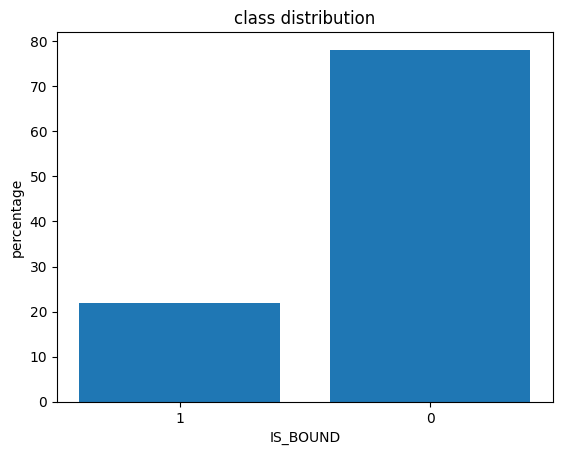

In [13]:
class_count_dict = Counter(insurance_train_data['IS_BOUND'].values)
n_rows = insurance_train_data.shape[0]
plt.bar(['1', '0'], [class_count_dict[1]*100/n_rows, class_count_dict[0]*100/n_rows])
plt.xlabel('IS_BOUND')
plt.ylabel('percentage')
plt.title('class distribution');

In [14]:
numerical_columns = list(insurance_train_data.select_dtypes(include = np.number).columns)
categorical_columns = [col for col in insurance_train_data.columns if col not in numerical_columns]
numerical_columns.remove('IS_BOUND')

In [15]:
class_0 = insurance_train_data.loc[insurance_train_data['IS_BOUND'] == 0]
class_1 = insurance_train_data.loc[insurance_train_data['IS_BOUND'] == 1]
purchase_level = class_1.shape[0]/n_rows
print('Purchase level: ', 100*round(purchase_level, 2), '%')

Purchase level:  22.0 %


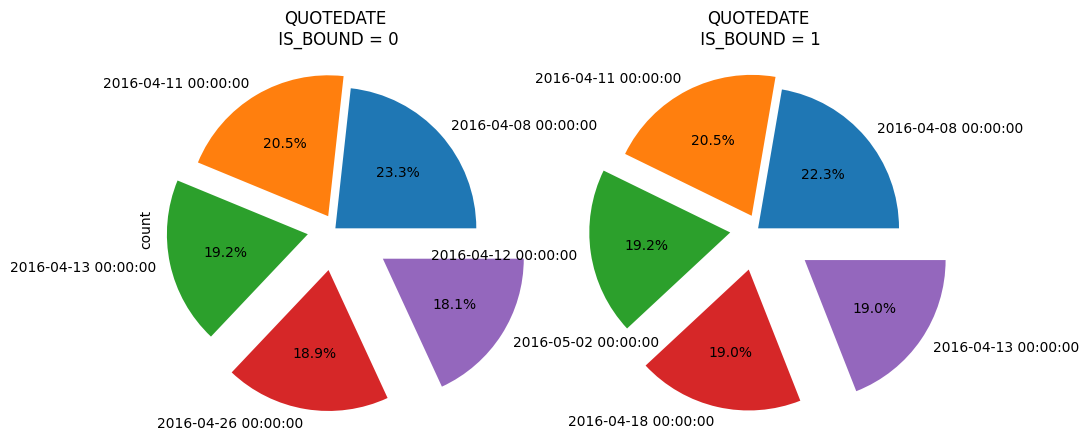

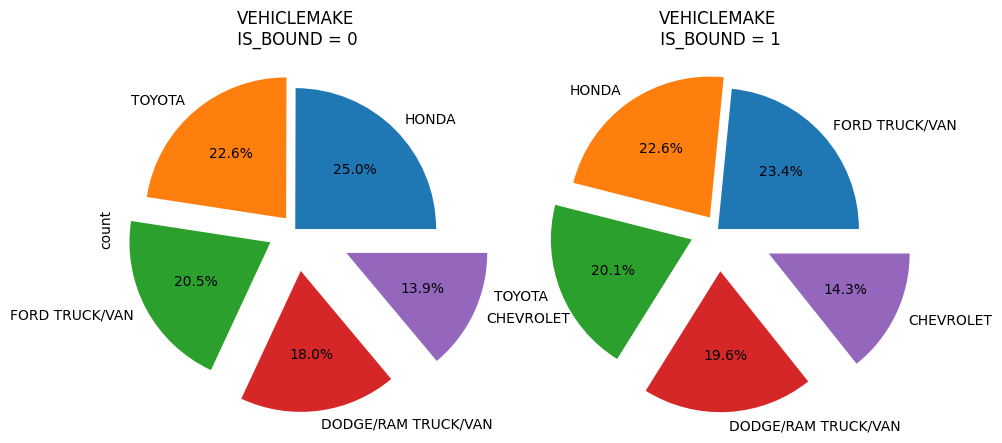

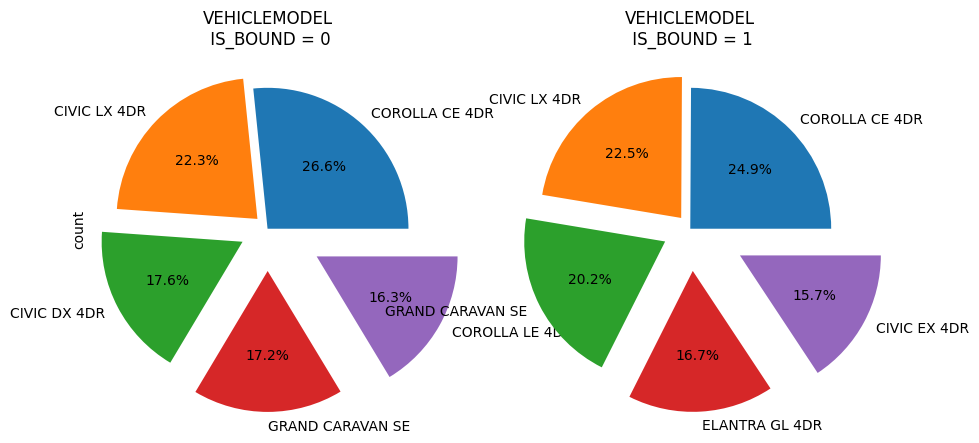

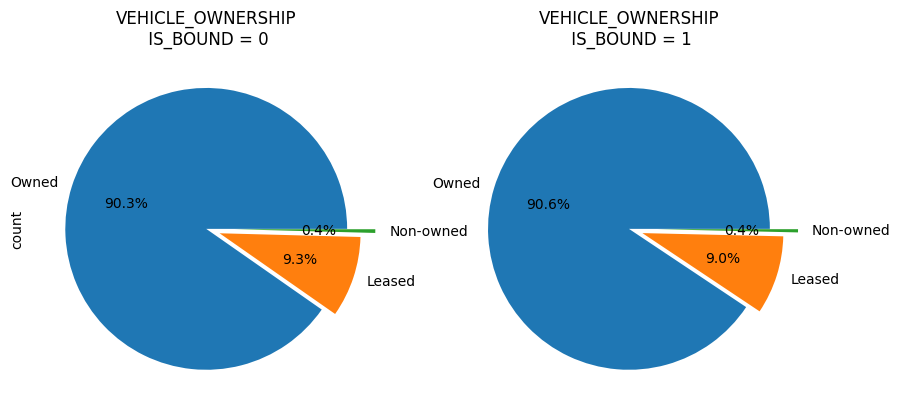

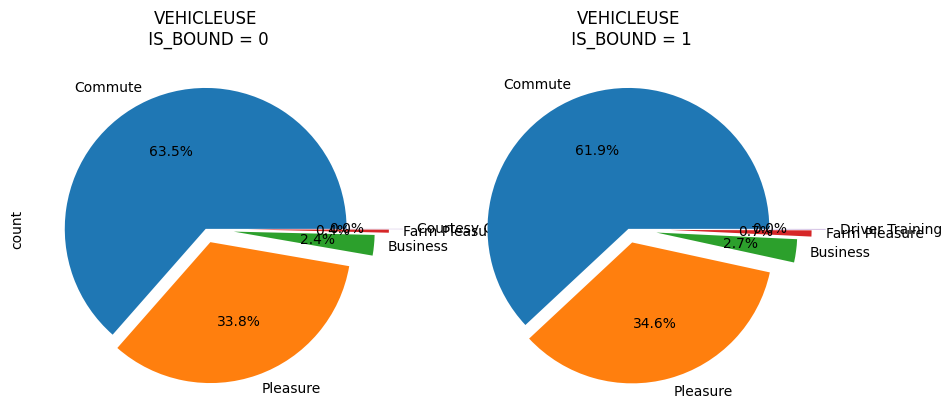

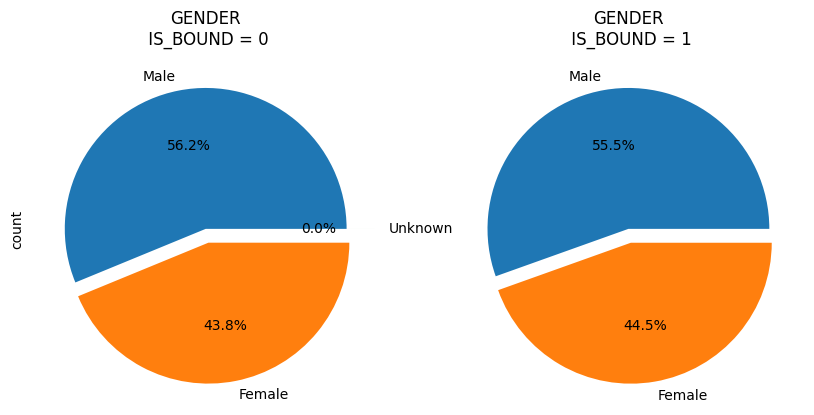

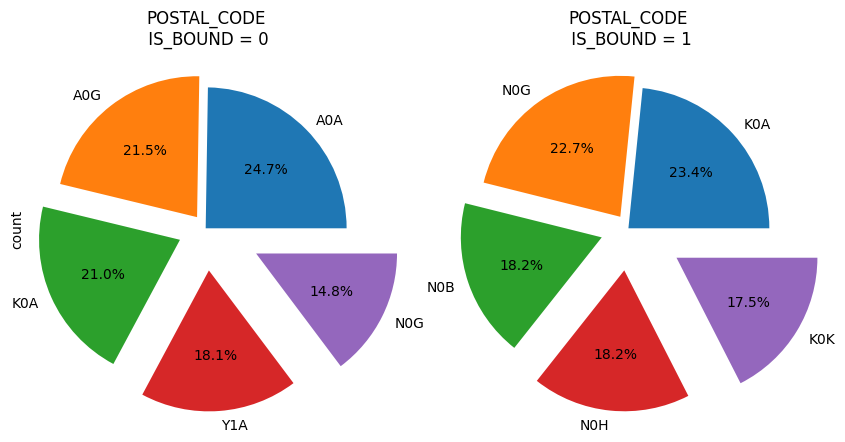

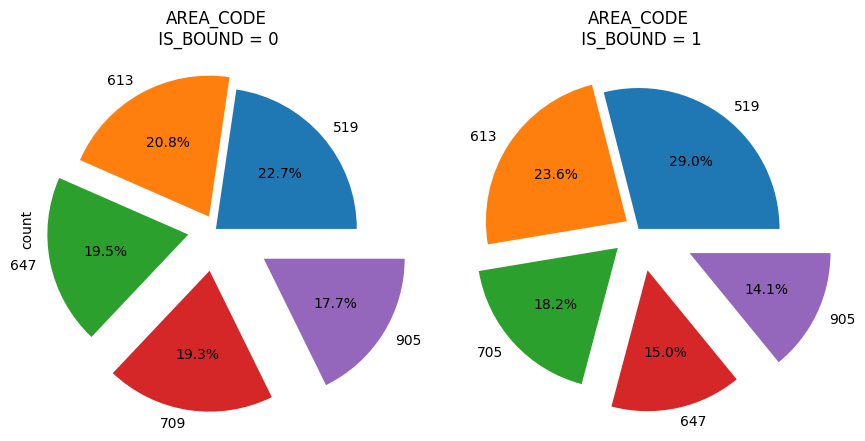

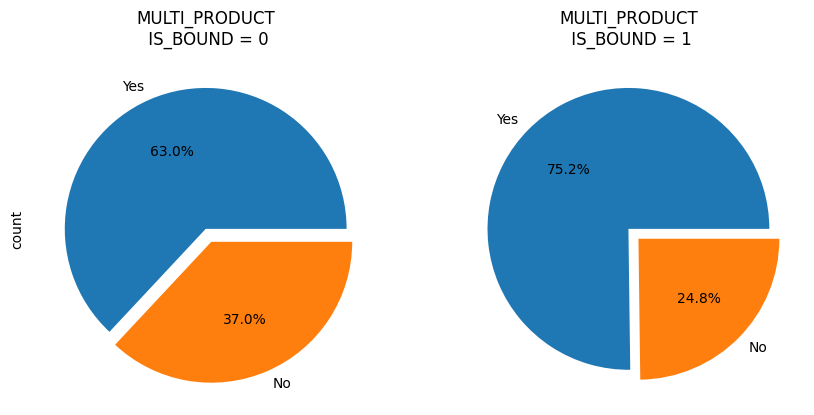

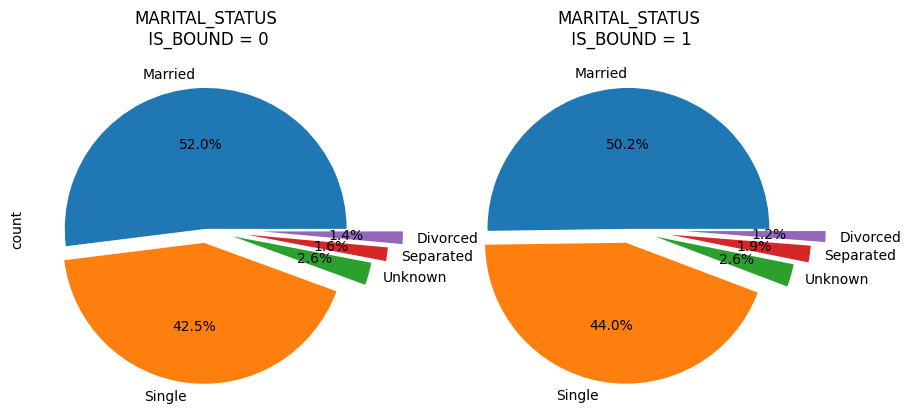

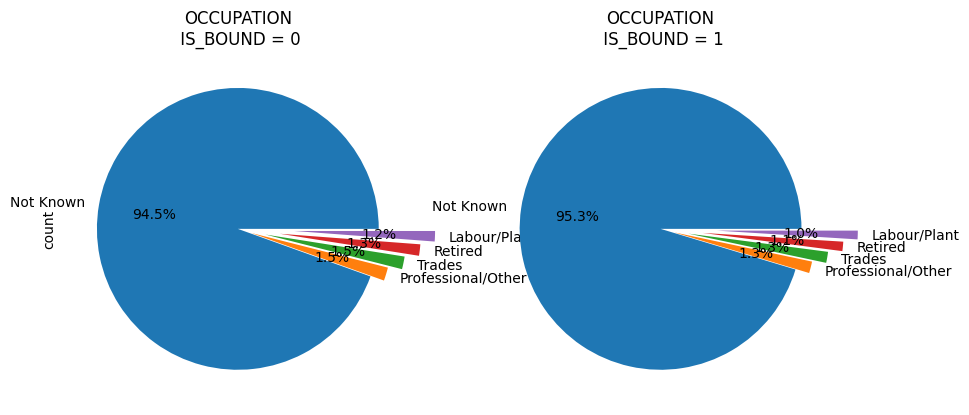

In [16]:
for col in categorical_columns:
    class_0_null = class_0[col].isnull().sum()
    class_1_null = class_1[col].isnull().sum()

    if (class_0_null/class_0.shape[0] < 0.95) & (class_1_null/class_1.shape[0]  < 0.95):
        pieplot(class_0, class_1, col, 'IS_BOUND = 0', 'IS_BOUND = 1', lim = 5)

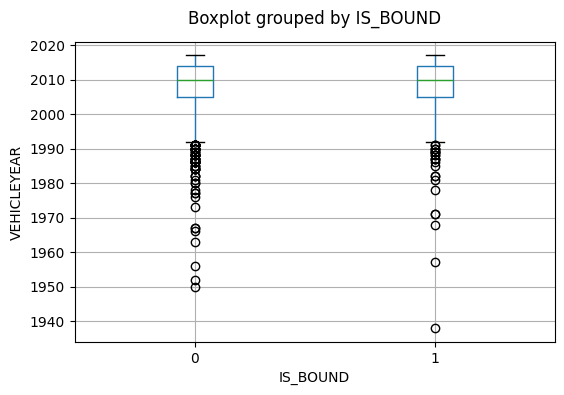

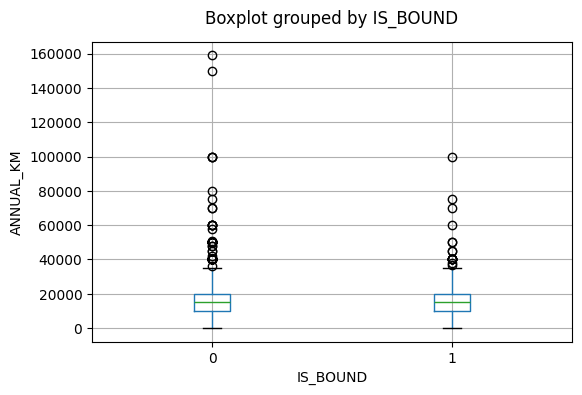

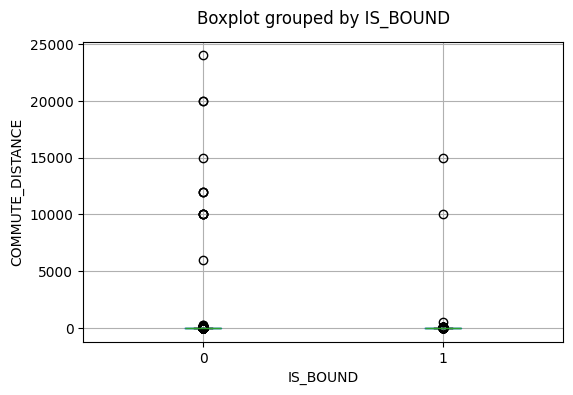

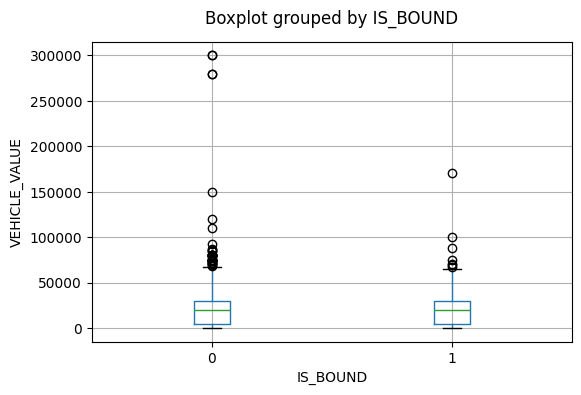

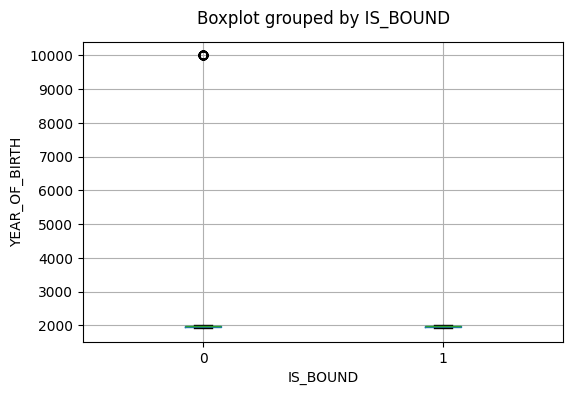

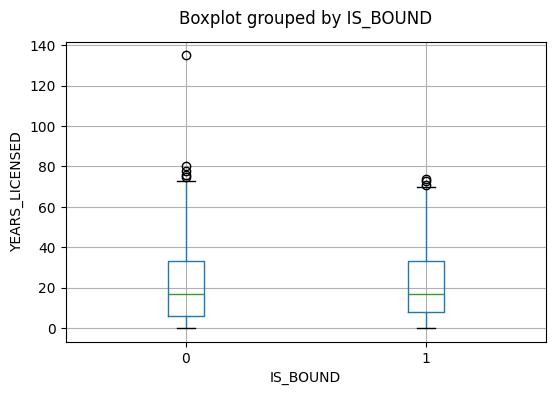

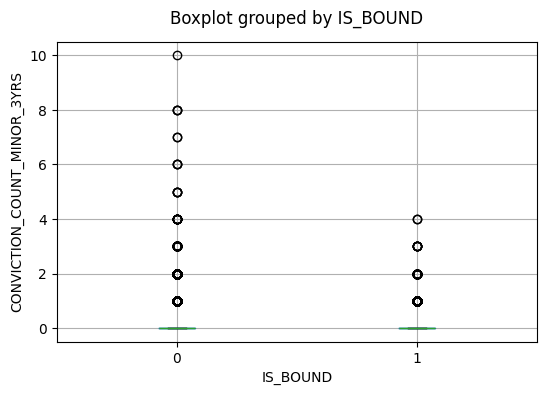

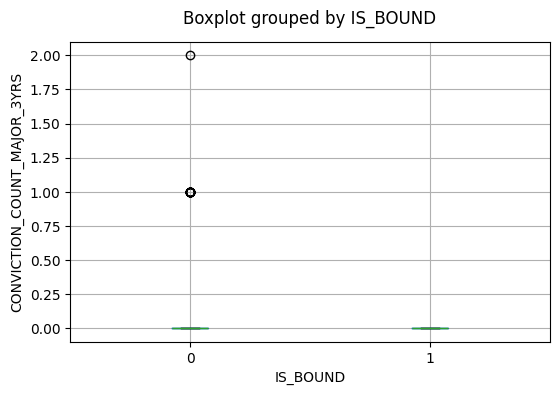

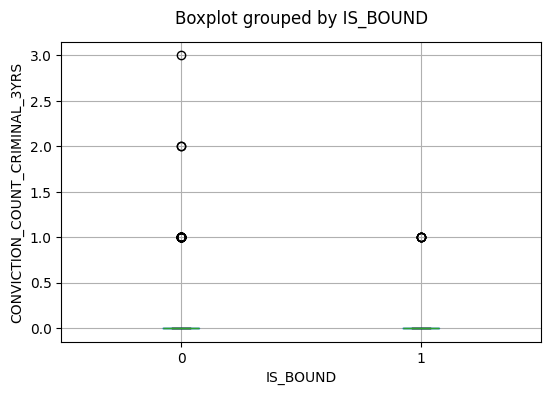

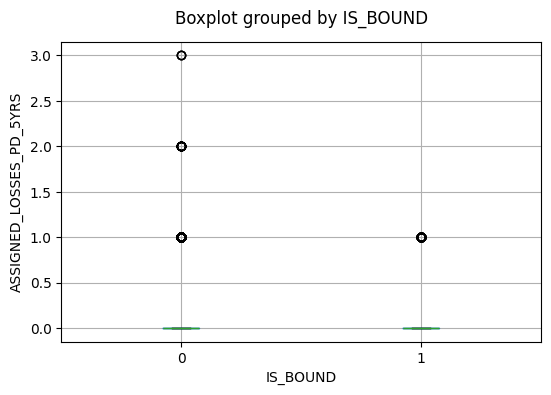

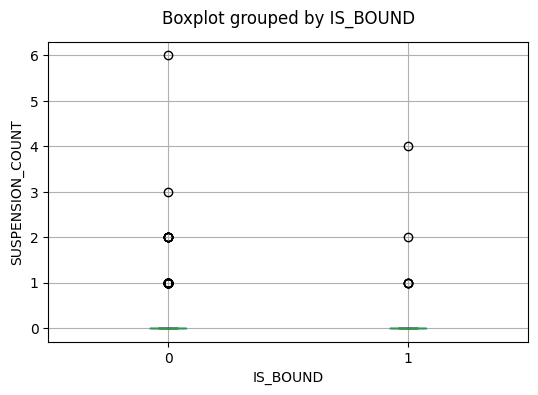

In [17]:
for col in numerical_columns:
    class_0_null = class_0[col].isnull().sum()
    class_1_null = class_1[col].isnull().sum()

    if (class_0_null/class_0.shape[0] < 0.95) & (class_1_null/class_1.shape[0]  < 0.95):
        boxplot(insurance_train_data, col, 'IS_BOUND')

# DATA PRE-PROCESSING

In this section, we will pre-process the data including:

**Feature Engineering**
* _Converting postal code to (latitude, longitude):_ We will use the package `pgeocode` to convert all postal codes to latitudes and longitudes. The benefit of this step is that there are more than 1000 postal codes, and one hot encoding them will create as many columns making our dataset sparse and large. Converting them to lat/long creates only two new columns. Additionally, it captures spatial distances as two lat/long values with small difference are geographically closer and large difference are farther apart. We also include some EDA to look at regions with higher and lower purchase rates than the national average.

**Data cleaning:**
* _Unstructured text:_ The `VEHICLEMAKE` column contains some typos such as 'ACCURA' in place of 'ACURA'. We will manually correct such entries.

**Imputing missing values**
* _Redundant columns:_ We will check if there are any redundant columns which have the same values for all entries. Columns `MARKING_SYSTEM` and `TRACKING_SYSTEM` contain more than 99% `null` values. Therefore, we drop these columns. Other columns such as number of convictions also contain the same value for over 99% of the rows. However, we keep them in the dataset since they do contain key information about the customers.
* _Unknown values:_ Some categorical columns such as `AREA_CODE` and `MARITAL_STATUS`contain entries such as 'Unk'/'Unknwon' or unknown. We will replace them by using other columns or most frequent values.
* _Missing values:_ We will drop columns (`YEARS_AS_PRINCIPAL_DRIVER`) that have more than 80% missing values. For the rest, we will impute them with the most frequent/median value or values predicted from other columns.

**Outlier analysis**

We iterate over every numerical column to check if they contain major outliers. Some columns contain outliers that look like data entry errors and therefore we correct them appropriately. Other columns contain values that have no feasible explanation and therefore we drop some of the entries.  

## Postal code to latitude and longitude

Let's use Postal Code information to find the location of the customer in (latitude, longitude). Also, this step is computationally intensive, therefore we convert all zipcodes only once and save them in a csv file for later use. The postal code column contains null values due to which some latitude/longitude values will be null. We will replace those values using `AREA_CODE` or the most frequent latitude/longitude pairs later.

In [18]:
def postal_code_to_location(df, country, code, filename):
    '''
    This function uses the pgeocode module to convert postal/zip codes to latitude
    and longitude coordinates. The postal codes and corresponding latitudes
    and longitudes are saved in a csv file for further use.
    Input: df or dataframe
        filename: name of output file
    '''
    # Create an instance of the Nominatim class with the country code Canada
    nomi = pgeocode.Nominatim(country)

    # Use the apply function to query the latitude and longitude for each postal code in the dataframe
    lat_long_df = df[code].apply(lambda x:nomi.query_postal_code(x))

    # Save the resulting dataframe to a CSV file named 'lat_long.csv'
    lat_long_df.to_csv(filename)

In [268]:
print('Total unique zipcodes:', len(Counter(insurance_train_data['POSTAL_CODE'])))

Total unique zipcodes: 1138


In [ ]:
# filename = 'supplementary_data/lat_long.csv'
# postal_code_to_location(insurance_train_data, 'ca', "POSTAL_CODE", filename)

In [20]:
# Read the latitude and longitude data from the 'lat_long.csv' file
lat_long_df = pd.read_csv('supplementary_data/lat_long.csv')

# Assign the latitude values from the lat_long_df to the 'latitude' column in the insurance_train_data DataFrame
insurance_train_data['latitude'] = lat_long_df['latitude'].values

# Assign the latitude values from the lat_long_df to the 'longitude' column in the insurance_train_data DataFrame
insurance_train_data['longitude'] = lat_long_df['longitude'].values

# Display the first few rows of the insurance_train_data DataFrame
insurance_train_data.head()

,QUOTEDATE,VEHICLEYEAR,VEHICLEMAKE,VEHICLEMODEL,ANNUAL_KM,COMMUTE_DISTANCE,MARKING_SYSTEM,TRACKING_SYSTEM,VEHICLE_OWNERSHIP,VEHICLE_VALUE,...,MARITAL_STATUS,OCCUPATION,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,SUSPENSION_COUNT,IS_BOUND,latitude,longitude
0,2016-01-02,2006,VOLKSWAGEN,JETTA 2.5 4P,10000.0,NaN,NaN,NaN,Owned,3000.0,...,Married,Trades,0,0,0,0,0,0,45.6442,-73.8448
1,2016-01-02,2017,HYUNDAI,ELANTRA GL 4DR,20000.0,NaN,NaN,NaN,Owned,1.0,...,Married,Not Known,0,0,0,0,0,0,43.1607,-79.7463
2,2016-01-02,2015,CHEVROLET TRUCK/VAN,SILVERADO 2500 HD LT CREW CAB 4WD,15000.0,NaN,NaN,NaN,NaN,NaN,...,Single,Not Known,0,0,0,0,0,0,53.5996,-113.4549
3,2016-01-02,2010,TOYOTA,COROLLA CE 4DR,20000.0,20.0,NaN,NaN,NaN,NaN,...,Single,Not Known,0,0,0,0,0,0,43.7196,-79.6854
4,2016-01-04,2013,HONDA,CIVIC LX 4DR,30000.0,30.0,NaN,NaN,NaN,NaN,...,Single,Not Known,0,0,0,0,0,0,43.8479,-79.3288


### EDA with latitude, longitude

Let's do some EDA with these two new columns using `plotly`.

* Key takeaway: The average rate of buying Cooperators auto-insurance policy is 22%. Places away from Toronto like Elmira, St. Katherine's, Stratford had above average percentage of customers buying the policy whereas regions closer to Toronto had less than average customers buying policies.

In [ ]:
# Extracting latitude values from lat_long_df
latitude = lat_long_df['latitude'].values

# Extracting longitude values from lat_long_df
longitude = lat_long_df['longitude'].values

# Creating a new column 'location' in insurance_train_data
# and assigning a tuple of latitude and longitude for each row
insurance_train_data['location'] = [(latitude[i], longitude[i]) for i in range(len(latitude))]

In [ ]:
# Create an empty DataFrame to store location data
location_df = pd.DataFrame()
# Create an empty list to store latitude values
latitudes = []
# Create an empty list to store longitude values
longitudes = []
# Create an empty list to store count values
counts = []

# Iterate over the unique locations in the insurance_train_data DataFrame
for key, value in Counter(insurance_train_data['location']).items():
    # Append the latitude value to the latitudes list
    latitudes.append(key[0])
    # Append the longitude value to the longitudes list
    longitudes.append(key[1])
    # Append the count value to the counts list
    counts.append(value)

# Add the latitude, longitude, and count lists as columns to the location_df DataFrame
location_df['latitude'] = latitudes
location_df['longitude'] = longitudes
location_df['count'] = counts

# Display the first few rows of the location_df DataFrame
location_df.head()

,latitude,longitude,count
0,45.6442,-73.8448,3
1,43.1607,-79.7463,431
2,53.5996,-113.4549,5
3,43.7196,-79.6854,125
4,43.8479,-79.3288,430


#### Location of customers

Let's view the location of the customers on the map on Canada with Yellow regions signifying more customers and Blue regions with less customers.

In [ ]:
# Data with latitude/longitude and values

fig = px.density_mapbox(location_df, lat = 'latitude', lon = 'longitude', z = 'count',
                        radius = 8,
                        center = dict(lat = 43.6,
                                      lon = -79.3),
                        zoom = 6,
                        mapbox_style = 'open-street-map')
fig.show()

#### Higher purchases

The average purchase rate was 22%. Let's look at the regions that had greater than average purchase rate.

In [ ]:
# Grouping the insurance_train_data by latitude and longitude and calculating the sum of customers who bought insurance (IS_BOUND)
is_bound_df = insurance_train_data.groupby(['latitude', 'longitude'])['IS_BOUND'].sum().reset_index()

# Merging the is_bound_df with location_df based on latitude and longitude
is_bound_df = is_bound_df.merge(location_df, on = ['latitude', 'longitude'])

# Calculating the purchase frequency by dividing IS_BOUND by count of customers in the region
is_bound_df['purchase_frequency'] = is_bound_df['IS_BOUND']/is_bound_df['count']

# Calculating the global average of IS_BOUND
global_average = sum(is_bound_df['IS_BOUND'])/insurance_train_data.shape[0]

# Printing the Canada-wide percentage of customers buying insurance
print('Canada-wide percentage of customers buying Cooperators insurance:', round(global_average,2)*100, '%')

# Calculating the purchase frequency deviation by subtracting global_average from purchase_frequency
is_bound_df['purchase_frequency_deviation'] = is_bound_df['purchase_frequency'] - global_average

# Displaying the first few rows of the is_bound_df
is_bound_df.head()

Canada-wide percentage of customers buying Cooperators insurance: 22.0 %


,latitude,longitude,IS_BOUND,count,purchase_frequency,purchase_frequency_deviation
0,42.0502,-82.7598,19,48,0.395833,0.177198
1,42.0549,-82.6062,34,120,0.283333,0.064698
2,42.1168,-83.0498,19,126,0.150794,-0.067842
3,42.1751,-82.8248,15,61,0.245902,0.027266
4,42.1783,-82.7715,69,247,0.279352,0.060717


In [ ]:
# Defining 'Big Markets' as regions with more that 100 customers
big_market_df = is_bound_df.loc[is_bound_df['count'] > 100]
big_market_df.head()

,latitude,longitude,IS_BOUND,count,purchase_frequency,purchase_frequency_deviation
1,42.0549,-82.6062,34,120,0.283333,0.064698
2,42.1168,-83.0498,19,126,0.150794,-0.067842
4,42.1783,-82.7715,69,247,0.279352,0.060717
5,42.2007,-83.0276,44,130,0.338462,0.119826
6,42.2187,-83.0801,30,121,0.247934,0.029298


In [ ]:
# Defining 'Top Markets' as locations where the percentage of buyers is 15% more than the Canada-wide average
big_market_df_top = big_market_df.loc[big_market_df['purchase_frequency_deviation'] > 0.15]

# Defining 'Bottom Markets' as locations where the percentage of buyers is 15% less than the Canada-wide average
big_market_df_bottom = big_market_df.loc[big_market_df['purchase_frequency_deviation'] < -0.15]

In [ ]:
# Displaying the first few rows of the top markets
big_market_df_top.head()

,latitude,longitude,IS_BOUND,count,purchase_frequency,purchase_frequency_deviation
18,42.3176,-82.9929,38,101,0.376238,0.157602
43,42.9403,-79.9450,63,160,0.393750,0.175114
65,43.0334,-80.8830,52,138,0.376812,0.158176
89,43.1923,-79.2559,50,125,0.400000,0.181364
120,43.3668,-80.9497,75,195,0.384615,0.165980


In [ ]:
# Looking at top markets on a map

fig = px.density_mapbox(big_market_df_top, lat = 'latitude', lon = 'longitude', z = 'purchase_frequency_deviation',
                        radius = 8,
                        center = dict(lat = 43.6,
                                      lon = -79.3),
                        zoom = 6,
                        mapbox_style = 'open-street-map',
                    )
fig.show()

In [ ]:
# Looking at bottom markets on a map

fig = px.density_mapbox(big_market_df_bottom, lat = 'latitude', lon = 'longitude', z = 'purchase_frequency_deviation',
                        radius = 8,
                        center = dict(lat = 43.6,
                                      lon = -79.3),
                        zoom = 6,
                        mapbox_style = 'open-street-map',
                    )
fig.show()

In [ ]:
# converting POSTAL CODE to (latitude, longitude)
# postal_code_to_location(insurance_test_data, 'ca', 'POSTAL_CODE', 'test_lat_long.csv')

In [22]:
# Read the latitude and longitude data from the 'test_lat_long.csv' file
test_lat_long_df = pd.read_csv('test_lat_long.csv')

# Assign the latitude values from the test_lat_long_df to the 'latitude' column in the insurance_test_data DataFrame
insurance_test_data['latitude'] = test_lat_long_df['latitude'].values

# Assign the latitude values from the test_lat_long_df to the 'longitude' column in the insurance_test_data DataFrame
insurance_test_data['longitude'] = test_lat_long_df['longitude'].values

# Display the first few rows of the insurance_test_data DataFrame
insurance_test_data.head()

,QUOTEDATE,VEHICLEYEAR,VEHICLEMAKE,VEHICLEMODEL,ANNUAL_KM,COMMUTE_DISTANCE,MARKING_SYSTEM,TRACKING_SYSTEM,VEHICLE_OWNERSHIP,VEHICLE_VALUE,...,MULTI_PRODUCT,MARITAL_STATUS,OCCUPATION,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,SUSPENSION_COUNT,latitude,longitude
0,2017-01-03,2002,HONDA,CIVIC EX 2DR COUPE [U.S. MODEL],10000,4.0,NaN,NaN,NaN,NaN,...,No,Single,Not Known,0,0,0,0,0,42.0549,-82.6062
1,2017-01-04,2010,FORD TRUCK/VAN,F150 XLT SUPERCREW 4WD,10000,10.0,NaN,NaN,NaN,NaN,...,Yes,Single,Not Known,0,0,0,0,0,48.4669,-81.3331
2,2017-01-04,2017,DODGE/RAM TRUCK/VAN,RAM 1500 REBEL CREW CAB 4WD,9000,3.0,NaN,NaN,Owned,72000.0,...,Yes,Single,Not Known,0,0,0,0,0,45.3501,-80.0330
3,2017-01-04,2013,DODGE/RAM TRUCK/VAN,RAM 1500 SPORT CREW CAB 4WD,10000,10.0,NaN,NaN,NaN,55000.0,...,No,Single,Not Known,0,0,0,0,0,60.7161,-135.0537
4,2017-01-04,2014,FORD,FOCUS SE 4DR,20000,10.0,NaN,NaN,NaN,NaN,...,No,Single,Student,0,0,0,0,0,46.2437,-60.2313


## Redundant columns

We will look for columns that have the same value for 99% of the rows. Such columns contain very little information distinguishing the two classes.

In [23]:
# Let's check for columns that have values that are repeated 99 percent of the time

def check_repeated_value(arr):
    '''
    The function checks if any value in the array is
    repeated more than 99% of the total number of elements in the array.
    '''
    # Count the occurrences of each value in the array
    col_values = Counter(arr)

    # Iterate through the unique values in the array
    for val in col_values.keys():
        # Check if the percentage of occurrences of the value is greater than 95%
        if col_values[val]/arr.shape[0] > 0.99:
            # If the condition is met, return True
            return True
    return False

In [24]:
# Checks for redundant columns that have high degree of repeated values. These columns may not add a lot of detail to our overall dataset

# Create an empty list to store redundant columns
redundant_columns = []

# Iterate through each column in the insurance_train_data dataframe
for col in insurance_train_data.columns.values:
    # Check if the column has repeated values
    if check_repeated_value(insurance_train_data[col].values):
        # If the column has repeated values, add it to the redundant_columns list
        redundant_columns.append(col)
print('redundant columns:\n')
# Iterate through each redundant column
for col in redundant_columns:
    print(col)

redundant columns:

MARKING_SYSTEM
TRACKING_SYSTEM
CONVICTION_COUNT_MAJOR_3YRS
CONVICTION_COUNT_CRIMINAL_3YRS
SUSPENSION_COUNT


In [25]:
# Let's check for columns that have values that are repeated 99 percent of the time

def check_repeated_value(arr):
    '''
    The function checks if any value in the array is
    repeated more than 99% of the total number of elements in the array.
    '''
    # Count the occurrences of each value in the array
    col_values = Counter(arr)

    # Iterate through the unique values in the array
    for val in col_values.keys():
        # Check if the percentage of occurrences of the value is greater than 95%
        if col_values[val]/arr.shape[0] > 0.99:
            # If the condition is met, return True
            return True
    return False

In [26]:
# Checks for redundant columns that have high degree of repeated values. These columns may not add a lot of detail to our overall dataset

# Create an empty list to store redundant columns
redundant_columns = []

# Iterate through each column in the insurance_train_data dataframe
for col in insurance_train_data.columns.values:
    # Check if the column has repeated values
    if check_repeated_value(insurance_train_data[col].values):
        # If the column has repeated values, add it to the redundant_columns list
        redundant_columns.append(col)
print('redundant columns:\n')
# Iterate through each redundant column
for col in redundant_columns:
    print(col)

redundant columns:

MARKING_SYSTEM
TRACKING_SYSTEM
CONVICTION_COUNT_MAJOR_3YRS
CONVICTION_COUNT_CRIMINAL_3YRS
SUSPENSION_COUNT


In [27]:
def sort_dict(d):
    '''
    this function sorts dictionaries based on their values.
    Args:
        d: dictionary
    '''
    return sorted(d.items(), key = lambda x: x[1], reverse = True)

In [28]:
# Count the number of missing values for MARKING_SYSTEM
sort_dict(Counter(insurance_train_data['MARKING_SYSTEM']))

[(nan, 101866),
 ('M - Sherlock Marking', 22),
 ('M - Autolock Marking', 2),
 ('M - Vin-Lock Marking', 1)]

In [29]:
# Count the number of missing values for TRACKING_SYSTEM
sort_dict(Counter(insurance_train_data['TRACKING_SYSTEM']))

[(nan, 101887),
 ('R - TAG', 1),
 ('R - SurtraQ', 1),
 ('R - Boomerang Espion Alerte', 1),
 ('R - Boomerang Espion Alerte Plus - Lojack', 1)]

In [30]:
# Count the number of missing values for CONVICTION_COUNT_MAJOR_3YRS
sort_dict(Counter(insurance_train_data['CONVICTION_COUNT_MAJOR_3YRS']))

[(0, 101562), (1, 306), (2, 16), (3, 6), (9, 1)]

In [31]:
# Count the number of missing values for CONVICTION_COUNT_CRIMINAL_3YRS
sort_dict(Counter(insurance_train_data['CONVICTION_COUNT_CRIMINAL_3YRS']))

[(0, 101330), (1, 513), (2, 38), (3, 9), (4, 1)]

In [32]:
# Count the number of missing values for SUSPENSION_COUNT
sort_dict(Counter(insurance_train_data['SUSPENSION_COUNT']))

[(0, 101307), (1, 483), (2, 76), (3, 13), (4, 10), (5, 1), (6, 1)]

In [33]:
# We will drop MARKING_SYSTEM AND TRACKING_SYSTEM as they have almost NULL values
drop_redundant_columns = ['MARKING_SYSTEM', 'TRACKING_SYSTEM']
insurance_train_data.drop(columns=drop_redundant_columns, inplace=True)
print('shape of train data:', insurance_train_data.shape)

shape of train data: (101891, 26)


In [34]:
# Dropping redundant columns from test set
insurance_test_data.drop(columns=drop_redundant_columns, inplace=True)
print('shape of test data:', insurance_test_data.shape)

shape of test data: (15114, 25)


## Data cleaning

In the `VEHICLEMAKE` column, there are multiple entries for the same vehicle make. To ensure accuracy and consistency, we will replace any duplicates or incorrectly categorized entries for vehicle makes in our dataset. For instance, 'ACURA' is misspelled as 'ACCURA,' despite both referring to the same make. Similar inconsistencies exist for other entries in this column. There are entries such as '1FTFW1EF8BFA01523' which we rename as 'UNDISCLOSED'.

### Vehiclemake

In [38]:
col = 'VEHICLEMAKE'

In [36]:
def vehicle_make_correction(df, column = "VEHICLEMAKE"):
    '''
    This function renames the mis-spelled vehicle makes.
    Args: df: orifinal dataframe with misspelled makes.
    Return: df: dataframe with corrected makes.
    '''
    df.loc[df[column] == "ACCURA", column] = 'ACURA'
    df.loc[df[column] == "ALTIMA", column] = 'NISSAN'
    df.loc[df[column] == "CAMRY", column] = 'TOYOTA'
    df.loc[df[column] == "CHALLENGER", column] = 'DODGE'
    df.loc[df[column] == "CIVIC", column] = 'HONDA'
    df.loc[df[column].isin(["ELANTRA", 'ELANTRA GT']), column] = 'HYUNDAI'
    df.loc[df[column].isin(["ARTCIT CAT", 'ARTIC CAT']), column] = 'ARCTIC CAT'
    df.loc[df[column].isin(["BOMBADIER"]), column] = 'BOMBARDIER'
    df.loc[df[column].isin(["CADILLIAC"]), column] = 'CADILLAC'
    df.loc[df[column].isin(["CEVROLET", 'CHCVIOE', 'CHERVOLET', 'CHEV', 'CHEVRELOT', 'CHEVROELT', 'CHEVROLE', 'CHEVROLER', 'CHEVY']), column] = 'CHEVROLET'
    df.loc[df[column].isin(["CHRSYLER", 'CHRYLSER', 'CHYRSLER', 'CRYSLER']), column] = 'CHRYSLER'
    df.loc[df[column].isin(["CORROLLA", 'COROLLA']), column] = 'TOYOTA'
    df.loc[df[column].isin(["DODGE RAM"]), column] = 'DODGE/RAM'
    df.loc[df[column].isin(["DOGDE"]), column] = 'DODGE'
    df.loc[df[column].isin(["F150", 'FORD F150']), column] = 'FORD 150'
    df.loc[df[column].isin(["GRAND"]), column] = 'GRAND CARAVAN'
    df.loc[df[column].isin(["HARLEY"]), column] = 'HARLEY DAVIDSON'
    df.loc[df[column].isin(['HONDA  CIVIC', 'HONDA CIVIC']), column] = 'HONDA'
    df.loc[df[column].isin(['HONODA']), column] = 'HONDA'
    df.loc[df[column].isin(['HUNDAI', 'HUNDAY', 'HYNDAI', 'HYNDEI', 'HYUANDAI', 'HYUNDIA']), column] = 'HYUNDAI'
    df.loc[df[column].isin(["INFINITY", 'INFINTI']), column] = 'INFINITI'
    df.loc[df[column].isin(["JEPP"]), column] = 'JEEP'
    df.loc[df[column].isin(["LAND ROVER"]), column] = 'LANDROVER'
    df.loc[df[column].isin(["MADZA", 'MAZDS']), column] = 'MAZDA'
    df.loc[df[column].isin(["MAZDA3"]), column] = 'MAZDA 3'
    df.loc[df[column].isin(["MECEDEZ"]), column] = 'MERCEDES'
    df.loc[df[column].isin(['MERCEDES BENZ', 'MERCEDEZ BENZ']), column] = 'MERCEDES-BENZ'
    df.loc[df[column].isin(["MITIBUSHI"]), column] = 'MITSUBISHI'
    df.loc[df[column].isin(['NISASN','NISSIAN','NISSSAN']), column] = 'NISSAN'
    df.loc[df[column].isin(['PONTAIC', 'PONTIIAC', 'POTIAC']), column] = 'PONTIAC'
    df.loc[df[column].isin(['PORCHE', 'PROSCHE']), column] = 'PORSCHE'
    df.loc[df[column].isin(['SKI-DOO']), column] = 'SKIDOO'
    df.loc[df[column].isin(['TOTOTA', 'TOYOATA', 'TOYOTO', 'TOYTO']), column] = 'TOYOTA'
    df.loc[df[column].isin(['TRAIL LIGHT']), column] = 'TRAILLITE'
    df.loc[df[column].isin(['TRIU']), column] =  'TRIUMPH'
    df.loc[df[column].isin(['VOLGSWAGEN', 'VOLKS', 'VOLKSWAGENJAVASCRIPT:VOID(0)', 'VOLKSWAGON', 'VOLKSWAGON JETTA', 'VOLSWAGEN', 'VW', 'WV', 'JETTA']), column] =  'VOLKSWAGEN'
    df.loc[df[column].isin(['1FTFW1EF8BFA01523', '2XXXXXXXXXXXXXXXXXX', 'Z28']), column] =  'UNDISCLOSED'

    return df

In [37]:
insurance_train_data = vehicle_make_correction(insurance_train_data, column = "VEHICLEMAKE")

In [39]:
# looking at test vehicle makes not in train set
veh_makes_not_in_train = set(Counter(insurance_test_data[col]).keys()).difference(Counter(insurance_train_data[col]).keys())
veh_makes_not_in_train

{'ACURA CAMION/VAN',
 'CAR',
 'CHALLENGER',
 'CHEV',
 'CIVIC',
 'DATSUN',
 'DIABLO',
 'DIHATSU',
 'DODDGE',
 'DODGE RAM',
 'FISKER',
 'HYNDAI',
 'LAND ROVER',
 'MAZERATI',
 'MERZ',
 'MINI COOPER',
 'MONICO',
 'NISAN',
 'NISSSAN',
 'PLYMONTH',
 'PONITAC',
 'PORCHE',
 'ROYAL',
 'TOYOTO',
 'UNITED',
 'VOLKSWAGON',
 'VOLLKS'}

In [40]:
# correcting data entry errors in test set
insurance_test_data.loc[insurance_test_data["VEHICLEMAKE"] == "ACURA CAMION/VAN", "VEHICLEMAKE"] = 'ACURA TRUCK/VAN'
insurance_test_data.loc[insurance_test_data["VEHICLEMAKE"] == "DATSUN", "VEHICLEMAKE"] = 'NISSAN'
insurance_test_data.loc[insurance_test_data["VEHICLEMAKE"] == "DIABLO", "VEHICLEMAKE"] = 'LAMBORGHINI'
insurance_test_data.loc[insurance_test_data["VEHICLEMAKE"].isin(["DIHATSU"]), "VEHICLEMAKE"] = 'TOYOTA'
insurance_test_data.loc[insurance_test_data["VEHICLEMAKE"].isin(["DODDGE"]), "VEHICLEMAKE"] = 'DODGE'
insurance_test_data.loc[insurance_test_data["VEHICLEMAKE"].isin(["MAZERATI"]), "VEHICLEMAKE"] = 'MASERATI'
insurance_test_data.loc[insurance_test_data["VEHICLEMAKE"].isin(["MERZ"]), "VEHICLEMAKE"] = 'MERCEDES-BENZ'
insurance_test_data.loc[insurance_test_data["VEHICLEMAKE"] == "MINI COOPER", "VEHICLEMAKE"] = 'MINI'
insurance_test_data.loc[insurance_test_data["VEHICLEMAKE"].isin(["MONICO"]), "VEHICLEMAKE"] = 'DODGE'
insurance_test_data.loc[insurance_test_data["VEHICLEMAKE"].isin(["NISAN"]), "VEHICLEMAKE"] = 'NISSAN'
insurance_test_data.loc[insurance_test_data["VEHICLEMAKE"].isin(["PLYMONTH"]), "VEHICLEMAKE"] = 'PLYMOUTH'
insurance_test_data.loc[insurance_test_data["VEHICLEMAKE"].isin(["PONITAC"]), "VEHICLEMAKE"] = 'PONTIAC'
insurance_test_data.loc[insurance_test_data["VEHICLEMAKE"].isin(["VOLLKS"]), "VEHICLEMAKE"] = 'VOLKSWAGEN'

## Unknown values

In this section, we will iterate over and inspect all columns that do not contain `NULL` values. Certain columns such as `AREA_CODE`, `MARITAL_STATUS` contains missing values in the form of 'Unk' which are null values but do not show up when performing the `pd.isna()` operation.

In [41]:
def missing_values(df):
    '''
    This function returns a list of columns containing missing values.
    Arg: df: dataframe
    Returns: columns_with_missing_vals: column containing missing values
    '''
    # Create an empty list to store column names with no missing values
    columns_with_missing_vals = []

    # Iterate through each column in the DataFrame
    for col in df.columns.values:
        # Count the number of missing values in the current column
        num_missing_vals = df[col].isna().sum()

        # If there are missing values in the current column
        if num_missing_vals > 0:
            # Add the column name to the list
            columns_with_missing_vals.append(col)

    # Print the list of column names with missing values
    return columns_with_missing_vals

In [42]:
columns_with_missing_vals = missing_values(insurance_train_data)
print('columns with missing values')
columns_with_missing_vals

columns with missing values


['ANNUAL_KM',
 'COMMUTE_DISTANCE',
 'VEHICLE_OWNERSHIP',
 'VEHICLE_VALUE',
 'GENDER',
 'YEARS_LICENSED',
 'YEARS_AS_PRINCIPAL_DRIVER',
 'OCCUPATION',
 'latitude',
 'longitude']

In [43]:
columns_with_no_missing_vals = [col for col in insurance_train_data.columns.values if col not in columns_with_missing_vals]
print('columns with no missing values')
columns_with_no_missing_vals

columns with no missing values


['QUOTEDATE',
 'VEHICLEYEAR',
 'VEHICLEMAKE',
 'VEHICLEMODEL',
 'VEHICLEUSE',
 'YEAR_OF_BIRTH',
 'POSTAL_CODE',
 'AREA_CODE',
 'MULTI_PRODUCT',
 'MARITAL_STATUS',
 'CONVICTION_COUNT_MINOR_3YRS',
 'CONVICTION_COUNT_MAJOR_3YRS',
 'CONVICTION_COUNT_CRIMINAL_3YRS',
 'ASSIGNED_LOSSES_PD_5YRS',
 'SUSPENSION_COUNT',
 'IS_BOUND']

In [44]:
# Loop through each column in the dataframe with no missing values and print the corresponding statistics
i = iter(range(len(columns_with_no_missing_vals)))

In [45]:
# See the details of the quote dates with no missing values using the describe function
col = columns_with_no_missing_vals[next(i)]
print(col)
insurance_train_data[col].describe()

QUOTEDATE


,QUOTEDATE
count,101891
mean,2016-07-08 13:42:40.889578240
min,2016-01-02 00:00:00
25%,2016-04-26 00:00:00
50%,2016-07-06 00:00:00
75%,2016-09-21 00:00:00
max,2016-12-30 00:00:00


In [46]:
# See the details of the vehicle years with no missing values using the describe function
col = columns_with_no_missing_vals[next(i)]
print(col)
insurance_train_data[col].describe()

VEHICLEYEAR


,VEHICLEYEAR
count,101891.000000
mean,2008.899677
std,5.823742
min,1930.000000
25%,2005.000000
50%,2010.000000
75%,2013.000000
max,2019.000000


In [49]:
# # Looking at VEHICLEMAKE
col = columns_with_no_missing_vals[next(i)]
print(col)
# Counter(insurance_train_data[col])

VEHICLEMAKE


In [50]:
# Looking at VEHICLEMODEL
col = columns_with_no_missing_vals[next(i)]
print(col)
# Counter(insurance_train_data[col])

VEHICLEMODEL


In [51]:
# Looking at VEHICLEUSE
col = columns_with_no_missing_vals[next(i)]
print(col)
Counter(insurance_train_data[col])

VEHICLEUSE


Counter({'Pleasure': 34579,
         'Business': 2462,
         'Commute': 64353,
         'Farm Pleasure': 437,
         'Driver Training': 29,
         'Courtesy Car': 23,
         'Fisherman': 2,
         'Police Emergency/Patrol': 4,
         'Fire Department -  Non-Emergency': 1,
         'Rally': 1})

In [53]:
# Entries for column YEAR_OF_BIRTH
col = columns_with_no_missing_vals[next(i)]
print((col))
# print([(year, Counter(insurance_train_data[col])[year]) for year in sorted(Counter(insurance_train_data[col]))])

YEAR_OF_BIRTH


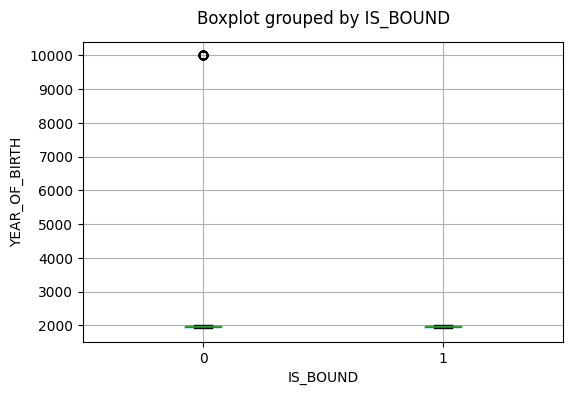

In [54]:
boxplot(insurance_train_data, col, 'IS_BOUND')

**Key insight:** We see that there are some `YEAR_OF_BIRTH` entries that contain the value '9999'. Interestingly, most of these values belong to `IS_BOUND = 0`. Perhaps this could be a proxy for undisclosed entries. Since they belong to one class, let's keep those entries as they are.   

In [55]:
# Counting the entries for POSTAL_CODE
col = columns_with_no_missing_vals[next(i)]
print(col)
count = Counter(insurance_train_data[col])
# list(count.keys())[:20]

POSTAL_CODE


In [ ]:
# Counting the entries for AREA_CODE
col = columns_with_no_missing_vals[next(i)]
print((col, 'Number of customers'))
sort_dict(Counter(insurance_train_data[col]))[0:20]

#### Area code

There are 1496 unknown values within the AREA_CODE column, which must be accounted for in our dataset. However, the POSTAL_CODE column is complete, and we will utilize that information to create a mapping that associates POSTAL_CODE entries with their corresponding AREA_CODE. This mapping will allow us to replace the unknown values within the AREA_CODE column.**

In [57]:
# making a list of all AREA_CODES
area_codes = Counter(insurance_train_data['AREA_CODE']).keys()

In [58]:
# Create an empty dictionary to store the postal codes and their corresponding area codes
area_codes_dict = {}
# iterating over all area codes
for area_code in area_codes:
    # Exclude the unknown area codes
    if area_code != 'Unk':
        postal_codes = insurance_train_data.loc[insurance_train_data['AREA_CODE'] == area_code]['POSTAL_CODE'].values
        # iterating over all postal codes for every area code
        for post_code in postal_codes:
            # Assign the area code to each postal code in the dictionary
            area_codes_dict[post_code] = area_code

In [59]:
# there are some unknown AREA_CODES which cannot be filled from
# the POSTAL_CODE value for the corresponding record.
# We replace these unkown codes with the most frequent area code.
most_frequent_area_code = 519

In [60]:
def impute_area_codes(df, area_codes_dict, most_frequent_area_code):
    '''
    This function imputes missing area codes using postal code information.
    Args: df: dataframe with missing area codes,
    area_codes_dict: dictionary containing postal code as key and area code as
    values,
    most_frequent_area_code: most frequent area code for instances where the
    postal code isn't part of the dictionary
    Returns: df: updated dataframe
    '''
    # iterating over all rows in the dataset
    for index, row in df.iterrows():
        # Get the value of the 'AREA_CODE' column for the current row
        area_code = row['AREA_CODE']

        # Check if the area code is unknown
        if area_code == 'Unk':

            # Get the value of the 'POSTAL_CODE' column for the current row
            postal_code = row['POSTAL_CODE']

            # Check if the postal code exists in the area_codes_dict dictionary
            if postal_code in area_codes_dict.keys():

                # If the postal code exists, update the area_code variable with the corresponding value from the dictionary
                area_code = area_codes_dict[postal_code]

                # Update the 'AREA_CODE' column in the dataframe with the new value
                df.at[index, 'AREA_CODE'] = area_code
            else:
                # Get a partial postal code by removing the last character
                postal_code_partial = postal_code[:-1]

                # Start with the ASCII value of 'a'
                char = 97

                # Create a postal code guess by appending a character to the partial postal code
                postal_code_guess = postal_code_partial + chr(char).upper()

                # Keep incrementing the character until a valid postal code guess is found or all characters have been exhausted
                while postal_code_guess not in area_codes_dict.keys() and char < 122:
                    char += 1
                    postal_code_guess = postal_code_partial + chr(char).upper()

                # If a valid postal code guess is found
                if char < 122:
                    # Update the area_code variable with the corresponding value from the dictionary
                    area_code = area_codes_dict[postal_code_guess]

                    # Update the 'AREA_CODE' column in the dataframe with the new value
                    df.at[index, 'AREA_CODE'] = area_code
                else:
                    # If no valid postal code guess is found, update the 'AREA_CODE' column with the most frequent area code
                    df.at[index, 'AREA_CODE'] = most_frequent_area_code
    return df

In [61]:
# Check the updated AREA_CODE column to verify all Unknown values have been removed
insurance_train_data = impute_area_codes(insurance_train_data, area_codes_dict, most_frequent_area_code)
# print(Counter(insurance_train_data['AREA_CODE']))

In [62]:
insurance_test_data = impute_area_codes(insurance_test_data, area_codes_dict, most_frequent_area_code)

In [63]:
# Next is the MULTI_PRODUCT column that contains yes or no values
col = columns_with_no_missing_vals[next(i)]
print(col)
Counter(insurance_train_data[col])

MULTI_PRODUCT


Counter({'No': 34949, 'Yes': 66942})

In [64]:
# MARITAL_STATUS
col = columns_with_no_missing_vals[next(i)]
print(col)
Counter(insurance_train_data[col])

MARITAL_STATUS


Counter({'Married': 52013,
         'Single': 43149,
         'Widow/Widower': 1064,
         'Separated': 1650,
         'Unknown': 2609,
         'Divorced': 1406})

#### Marital status

There are quite a few entries in this column labeled as unknown. To address this, we will fill the unknown values in the column using the `YEAR_OF_BIRTH` column. Our approach involves calculating the median birth year values of individuals in each category (e.g., median birth year of married individuals, widowers, etc.). Subsequently, we will utilize these calculated median birth year values to update the `MARITAL_STATUS` of individuals marked as unknown. This will be based on the proximity of their year of birth values to the calculated median of each category.

In [65]:
# Calculate the mean year of birth values for each category

married_median_yob = np.median(insurance_train_data.loc[insurance_train_data[col] == 'Married']['YEAR_OF_BIRTH'].values)
single_median_yob = np.median(insurance_train_data.loc[insurance_train_data[col] == 'Single']['YEAR_OF_BIRTH'].values)
separated_median_yob = np.median(insurance_train_data.loc[insurance_train_data[col] == 'Separated']['YEAR_OF_BIRTH'].values)
divorced_median_yob = np.median(insurance_train_data.loc[insurance_train_data[col] == 'Divorced']['YEAR_OF_BIRTH'].values)
widow_median_yob = np.median(insurance_train_data.loc[insurance_train_data[col] == 'Widow/Widower']['YEAR_OF_BIRTH'].values)

In [66]:
# Print the mean birth year values for each category

print('Median age of Married customers =', np.round(married_median_yob))
print('Median age of Single customers =', np.round(single_median_yob))
print('Median age of Separated customers =', np.round(separated_median_yob))
print('Median age of Divorced customers =', np.round(divorced_median_yob))
print('Median age of Widow/Widower customers =', np.round(widow_median_yob))

Median age of Married customers = 1968.0
Median age of Single customers = 1988.0
Median age of Separated customers = 1970.0
Median age of Divorced customers = 1964.0
Median age of Widow/Widower customers = 1946.0


In [ ]:
ttest_ind(insurance_train_data.loc[insurance_train_data[col] == 'Married']['YEAR_OF_BIRTH'].values, insurance_train_data.loc[insurance_train_data[col] == 'Single']['YEAR_OF_BIRTH'].values)

TtestResult(statistic=-5.693129910365389, pvalue=1.25097084463827e-08, df=95160.0)

In [ ]:
ttest_ind(insurance_train_data.loc[insurance_train_data[col] == 'Widow/Widower']['YEAR_OF_BIRTH'].values, insurance_train_data.loc[insurance_train_data[col] == 'Married']['YEAR_OF_BIRTH'].values)

TtestResult(statistic=-2.245284317958335, pvalue=0.02475398530297921, df=53075.0)

**Key insight**

* We see that Widows/Widowers have a median YOB of 1946, Married of 1968, and Single of 1988. We see that the difference between the ages of these 3 categories are statistically significant and impute missing marital status values based on age.**

* Even though Married, Separated and Divorced customers have relatively the same median age, we will impute missing entires with Married value for customers with ages closer to 1968 since it is the most frequent value in that age neighborhood.**

In [67]:
def impute_marital_status(df, mean_yobs):
    '''
    This function imputes missing marital status values using age.
    Args: df: dataframe with missing marital statuses
    median_yobs: median year of births of married, separated and divorced
    customers.
    Return: df: dataframe with imputed mising values
    '''
    married_median_yob = median_yobs[0]
    single_median_yob = median_yobs[1]
    widow_median_yob = median_yobs[2]

    # iterating over all rows in dataset
    for index, row in df.iterrows():

        # if marital status is unknown
        if row[col] == 'Unknown':

            # select year of birth
            unknown_yob = row['YEAR_OF_BIRTH']

            # calcualte difference between YOB and the median ages of married, single and widow/widowers
            diff = [abs(unknown_yob - married_median_yob), abs(unknown_yob - single_median_yob), abs(unknown_yob - widow_median_yob)]

            # calculate the minimum difference
            min_diff = min(diff)

            # assign unknown value to Married if YOB is close to 1967
            if min_diff == diff[0]:
                df.at[index, col] = 'Married'

            # assign unknown value to Single if YOB is close to 1983
            elif min_diff == diff[1]:
                df.at[index, col] = 'Single'

            # assign unknown value to Widow/Widower if YOB is close to 1947
            else:
                df.at[index, col] = 'Widow/Widower'

    return df

In [68]:
# Counter for updated MARITAL_STATUS column
median_yobs = [married_median_yob, single_median_yob, widow_median_yob]
insurance_train_data = impute_marital_status(insurance_train_data, median_yobs)
Counter(insurance_train_data[col])

Counter({'Married': 53112,
         'Single': 44109,
         'Widow/Widower': 1614,
         'Separated': 1650,
         'Divorced': 1406})

In [69]:
insurance_test_data = impute_marital_status(insurance_test_data, median_yobs)

In [70]:
# Summary for CONVICTION_COUNT_MINOR_3YRS
col = columns_with_no_missing_vals[next(i)]
print(col)
Counter(insurance_train_data[col])

CONVICTION_COUNT_MINOR_3YRS


Counter({0: 89480,
         1: 9325,
         2: 2316,
         3: 474,
         5: 76,
         4: 164,
         7: 14,
         10: 3,
         6: 26,
         8: 9,
         16: 1,
         9: 3})

In [71]:
# Summary for CONVICTION_COUNT_MAJOR_3YRS
col = columns_with_no_missing_vals[next(i)]
print(col)
Counter(insurance_train_data[col])

CONVICTION_COUNT_MAJOR_3YRS


Counter({0: 101562, 1: 306, 2: 16, 3: 6, 9: 1})

In [72]:
# Summary for CONVICTION_COUNT_CRIMINAL_3YRS
col = columns_with_no_missing_vals[next(i)]
print(col)
Counter(insurance_train_data[col])

CONVICTION_COUNT_CRIMINAL_3YRS


Counter({0: 101330, 1: 513, 2: 38, 3: 9, 4: 1})

In [73]:
# Summary for ASSIGNED_LOSSES_PD_5YRS
col = columns_with_no_missing_vals[next(i)]
print(col)
Counter(insurance_train_data[col])

ASSIGNED_LOSSES_PD_5YRS


Counter({0: 96165, 1: 5525, 2: 189, 3: 11, 4: 1})

In [74]:
# Summary for SUSPENSION_COUNT
col = columns_with_no_missing_vals[next(i)]
print(col)
Counter(insurance_train_data[col])

SUSPENSION_COUNT


Counter({0: 101307, 1: 483, 2: 76, 4: 10, 3: 13, 5: 1, 6: 1})

In [75]:
# Finally summary for our target variable IS_BOUND
col = columns_with_no_missing_vals[next(i)]
print(col)
Counter(insurance_train_data[col])

IS_BOUND


Counter({0: 79599, 1: 22292})

## Missing values

In [76]:
columns_with_missing_vals = [col for col in columns_with_missing_vals if col in insurance_train_data.columns.values]

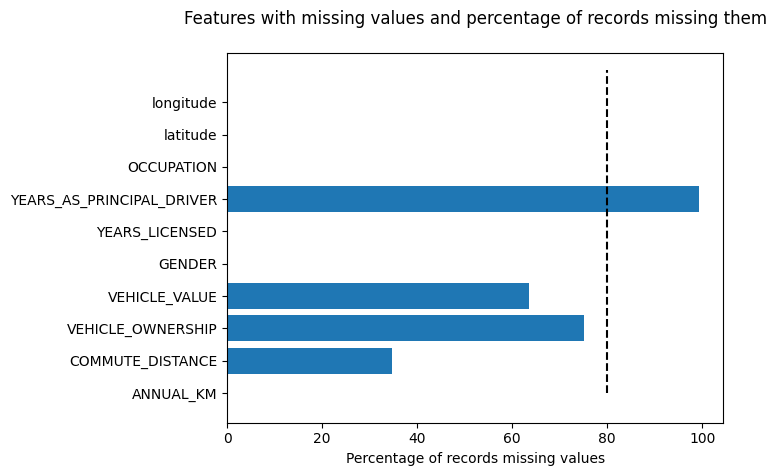

In [77]:
# After identifying the columns with missing values we will plot a bar graph to see the percent of missing values in each column.
columns_with_missing_vals_percentage = [100*insurance_train_data[col].isna().sum()/insurance_train_data.shape[0] for col in columns_with_missing_vals]
plt.barh([col for col in columns_with_missing_vals], columns_with_missing_vals_percentage)
plt.vlines(80,0,len(columns_with_missing_vals), ls = '--', color = 'black')
plt.xlabel('Percentage of records missing values')
plt.title('Features with missing values and percentage of records missing them\n');

In [78]:
# As evident in the plot above YEARS_AS_PRINCIPAL_DRIVER has almost 100 percent missing values so we will drop this column.
dropped_columns = ['YEARS_AS_PRINCIPAL_DRIVER']
insurance_train_data.drop(columns=dropped_columns, inplace=True)
print('shape of train data: ', insurance_train_data.shape)

shape of train data:  (101891, 25)


In [83]:
insurance_test_data.drop(columns=dropped_columns, inplace=True)

In [84]:
# recounting columns with missing values
columns_with_missing_vals = missing_values(insurance_train_data)
columns_with_missing_vals

['ANNUAL_KM',
 'COMMUTE_DISTANCE',
 'VEHICLE_OWNERSHIP',
 'VEHICLE_VALUE',
 'GENDER',
 'YEARS_LICENSED',
 'OCCUPATION',
 'latitude',
 'longitude']

In [85]:
# Again we will explore columns with missing values one by one as we did for columns with no missing values
j = iter(range(len(columns_with_missing_vals)))

#### Annual kilometer

In [86]:
# First is ANNUAL_KM
col = columns_with_missing_vals[next(j)]
print(f'missing values in {col}: {insurance_train_data[col].isna().sum()}')
insurance_train_data[col].describe()

missing values in ANNUAL_KM: 1


,ANNUAL_KM
count,101890.000000
mean,14912.352351
std,8255.201854
min,0.000000
25%,10000.000000
50%,15000.000000
75%,20000.000000
max,500000.000000


In [87]:
print('Zero values:', insurance_train_data.loc[insurance_train_data[col] == 0].shape[0])

Zero values: 105


* **Key insight:** Even though the annual km column has 1 null value, it also contains zero values which is improbable and could be placeholder values. Therefore, we will replace values below 100 km with the median value.

In [88]:
def impute_annual_km(df, median_annual_km, threshold_annual_km = 100):
    '''
    This function replaces the missing annual km values and values below
    threshold with the median value.
    Args: df: dataframe,
    median_annual_km: median annual km value (value to be replaced),
    threshold_annual_km: minimum value below which annual km will be replaced
    by median value.
    Returns: Updated dataframe
    '''
    df.loc[df[col] != df[col], col] = median_annual_km
    df.loc[df[col] <= threshold_annual_km, col] = median_annual_km
    return df

In [89]:
median_annual_km = insurance_train_data[col].median()
print(f'median ANNUAL KM: {median_annual_km}')
insurance_train_data = impute_annual_km(insurance_train_data, median_annual_km)

median ANNUAL KM: 15000.0


In [90]:
print(f'missing values in {col}: {insurance_train_data[col].isna().sum()}')
insurance_train_data[col].describe()

missing values in ANNUAL_KM: 0


,ANNUAL_KM
count,101891.000000
mean,15034.596863
std,8143.825490
min,150.000000
25%,10000.000000
50%,15000.000000
75%,20000.000000
max,500000.000000


In [91]:
insurance_test_data = impute_annual_km(insurance_test_data, median_annual_km)

#### Commute distance

In [92]:
# Next is COMMUTE_DISTANCE
col = columns_with_missing_vals[next(j)]
print(f'missing values in {col}: {insurance_train_data[col].isna().sum()}')
insurance_train_data[col].describe()

missing values in COMMUTE_DISTANCE: 35413


,COMMUTE_DISTANCE
count,66478.000000
mean,49.421478
std,839.710329
min,0.000000
25%,7.000000
50%,10.000000
75%,16.000000
max,98000.000000


In [93]:
def impute_commute_distance(df, median_commute_dist, threshold_commute_dist = 0):
    '''
    This function replaces the missing commute distance values and values
    below a threshold with the median value.
    Args: df: dataframe,
    median_commute_dist: median commute distance value (value to be replaced),
    threshold_annual_km: minimum value below which commute distance will be
    replaced by the median value.
    Returns: Updated dataframe
    '''
    df.loc[df[col] != df[col], col] = median_commute_dist
    df.loc[df[col] == threshold_commute_dist, col] = median_commute_dist

    return df

In [94]:
median_commute_dist = insurance_train_data[col].median()
print(f'median COMMUTE DISTANCE: {median_commute_dist}')
insurance_train_data = impute_commute_distance(insurance_train_data, median_commute_dist)

median COMMUTE DISTANCE: 10.0


In [95]:
print(f'missing values in {col}: {insurance_train_data[col].isna().sum()}')
insurance_train_data[col].describe()

missing values in COMMUTE_DISTANCE: 0


,COMMUTE_DISTANCE
count,101891.000000
mean,35.786782
std,678.521738
min,1.000000
25%,10.000000
50%,10.000000
75%,15.000000
max,98000.000000


In [96]:
insurance_test_data = impute_commute_distance(insurance_test_data, median_commute_dist)

#### Vehicle ownership

In [97]:
# Next is VEHICLE_OWNERSHIP
col = columns_with_missing_vals[next(j)]
print(f'missing values in {col}: {insurance_train_data[col].isna().sum()}')
Counter(insurance_train_data[col])

missing values in VEHICLE_OWNERSHIP: 76450


Counter({'Owned': 22990, nan: 76450, 'Leased': 2347, 'Non-owned': 104})

**Key insight:** The vehicle ownership categories do not include financing. Therefore, we do not replace the null values with the existing values. Instead, we create a new category named 'Undisclosed'.

In [98]:
replace_with = 'Undisclosed'

In [99]:
# Replace the missing values with the most frequent ownership which is owned in this case
insurance_train_data.loc[insurance_train_data[col] != insurance_train_data[col], col] = replace_with
Counter(insurance_train_data[col])

Counter({'Owned': 22990,
         'Undisclosed': 76450,
         'Leased': 2347,
         'Non-owned': 104})

In [101]:
insurance_test_data.loc[insurance_test_data[col] != insurance_test_data[col], col] = replace_with

#### Vehicle value

To address the missing vehicle values, we utilized information from the Vehicle Year, Vehicle Value, and Vehicle Make columns. Our approach involved creating a list for each of these combinations and calculating the average price for a vehicle in each category. For instance, we calculated the average cost of a 1952 Pontiac from examples where the information was available. If an example with such a vehicle had a missing vehicle value, we replaced the missing value with the average value of a 1952 Pontiac. For vehicles whose missing values couldn't be calculated from the other columns, we replaced them with the median vehicle value of $23000.

In [102]:
# VEHICLE_VALUE
col = columns_with_missing_vals[next(j)]
print(f'missing values in {col}: {insurance_train_data[col].isna().sum()}')
insurance_train_data[col].describe()

missing values in VEHICLE_VALUE: 64673


,VEHICLE_VALUE
count,37218.000000
mean,20739.369149
std,19469.412499
min,0.000000
25%,5000.000000
50%,20000.000000
75%,30000.000000
max,800000.000000


In [103]:
# Count the occurrences of each unique value in the vehicle value column of the training data
vehicle_val_dict = Counter(insurance_train_data.loc[insurance_train_data[col] == insurance_train_data[col]][col])

# Sort the unique values in the 'col' column of the insurance_train_data DataFrame
vehicle_val_dict_sorted = sorted(Counter(insurance_train_data.loc[insurance_train_data[col] == insurance_train_data[col]][col]))

In [104]:
# In this code block we will use the Vehicle year and Vehicle make entries to compare it's relationship with the vehicle value entries

# Create an empty dictionary to store vehicle values
vehicle_value_dict = {}

# Iterate through each row in the training data
for index, row in insurance_train_data.iterrows():
    # Get the vehicle year from the current row
    vehicle_year = row['VEHICLEYEAR']
    # Get the vehicle make from the current row
    vehicle_make = row['VEHICLEMAKE']
    # Get the vehicle value from the current row
    vehicle_value = row['VEHICLE_VALUE']
    # Check if the vehicle value is valid
    if vehicle_value > 1. and vehicle_value == vehicle_value:
        # Check if the vehicle year and make combination is not already in the dictionary
        if (vehicle_year, vehicle_make) not in vehicle_value_dict:
            # If not, add a new key-value pair with the vehicle year and make as the key and the vehicle value as the value
            vehicle_value_dict[(vehicle_year, vehicle_make)] = [vehicle_value]
        else:
            # If the key already exists, append the vehicle value to the existing list of values
            vehicle_value_dict[(vehicle_year, vehicle_make)].append(vehicle_value)

In [105]:
# Finally, we will calculate the average vehicle value for each combination of vehicle make and vehicle year and
# use that information to impute the missing values
vehicle_avg_value_dict = {}
for key in vehicle_value_dict.keys():
    vehicle_avg_value_dict[key] = np.mean(vehicle_value_dict[key])

In [106]:
# for those entries whose vehicle value can't be discerned from the vehicle make and year,
# we'll use the median vehicle value from the dataset
median_freq_vehicle_value = np.median(insurance_train_data.loc[(insurance_train_data['VEHICLE_VALUE'] > 1.) & (insurance_train_data['VEHICLE_VALUE'] == insurance_train_data['VEHICLE_VALUE'])]['VEHICLE_VALUE'].values)
print('median vehicle value =', round(median_freq_vehicle_value))

median vehicle value = 23000


In [107]:
def impute_vehicle_value(df, vehicle_avg_value_dict, median_vehicle_value):
    '''
    This fucntion uses the average vehicle value based on year and make and
    median vehicle value of the dataset (for cases where the year and make
    info is missing) to impute missing values of vehicle value.
    Args: df: dataframe,
    vehicle_avg_value_dict: dictionary containing (vehicle make, year) as key
    and average vehicle value as value.
    median_vehicle_value: median vehicle value.
    Returns: Updated dataframe
    '''
    for index, row in df.iterrows():
        # Check if the vehicle value is less than or equal to 1 or if it is NaN
        if row['VEHICLE_VALUE'] <= 1. or row['VEHICLE_VALUE'] != row['VEHICLE_VALUE']:
            # Get the vehicle year from the current row
            vehicle_year = row['VEHICLEYEAR']
            # Get the vehicle make from the current row
            vehicle_make = row['VEHICLEMAKE']
            # Check if the combination of vehicle year and make exists in the vehicle_avg_value_dict
            if (vehicle_year, vehicle_make) in vehicle_avg_value_dict.keys():
                df.at[index, 'VEHICLE_VALUE'] = vehicle_avg_value_dict[(vehicle_year, vehicle_make)]
            # If the combination does not exist, assign the median frequency vehicle value
            else:
                df.at[index, 'VEHICLE_VALUE'] = median_vehicle_value

    return df

In [108]:
insurance_train_data = impute_vehicle_value(insurance_train_data, vehicle_avg_value_dict, median_freq_vehicle_value)

In [109]:
insurance_test_data = impute_vehicle_value(insurance_test_data, vehicle_avg_value_dict, median_freq_vehicle_value)

#### Gender

In [110]:
# Next is gender. There are 5 missing values and 1 unknown value
col = columns_with_missing_vals[next(j)]
print(f'missing values in {col}: {insurance_train_data[col].isna().sum()}')
Counter(insurance_train_data[col])

missing values in GENDER: 5


Counter({'Male': 57103, 'Female': 44782, nan: 5, 'Unknown': 1})

In [111]:
# Replace the NaN and unknown values with Male as it's the most common entry
insurance_train_data.loc[(insurance_train_data[col] == "Unknown") |(insurance_train_data[col] != insurance_train_data[col]), col] = 'Male'
Counter(insurance_train_data['GENDER'])

Counter({'Male': 57109, 'Female': 44782})

In [112]:
insurance_test_data.loc[(insurance_test_data[col] == "Unknown") |(insurance_test_data[col] != insurance_test_data[col]), col] = 'Male'

#### Years licenced

To address the missing years licenced values, we initially examined whether the `YEARS_LICENCED` column displayed any linear relationship with the year of birth. To evaluate this, we calculated the Pearson's correlation coefficient (Pearson r = 0.87) and noted a strong linear relationship between the two. Utilizing this information, we performed a linear regression analysis to predict the missing values in the years licenced column based on the observed correlation with year of birth.

In [113]:
# Check the YEARS_LICENSED
col = columns_with_missing_vals[next(j)]
print(f'missing values in {col}: {insurance_train_data[col].isna().sum()}')
insurance_train_data[col].describe()

missing values in YEARS_LICENSED: 8


,YEARS_LICENSED
count,101883.000000
mean,20.748407
std,16.252289
min,0.000000
25%,6.000000
50%,17.000000
75%,33.000000
max,135.000000


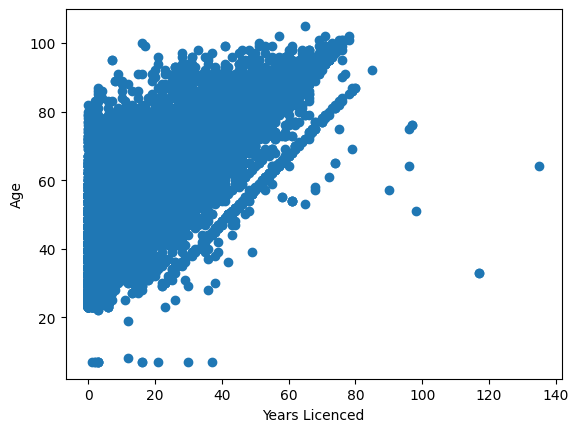

In [114]:
# Plot the age vs years licenced of the individuals requesting the quote
df = insurance_train_data.loc[insurance_train_data['YEAR_OF_BIRTH'] != 9999]
plt.scatter(df[col], [2023 - ent for ent in df['YEAR_OF_BIRTH'].values])
plt.xlabel('Years Licenced')
plt.ylabel('Age');

In [115]:
# Check to see if there is a linear relationship between the years licensed and the year of birth.
# Extracting the years licensed from the insurance train data
years_licensed = df[df[col] == df[col]][col].values

# Calculating the year of birth by subtracting the age from the current year
year_of_birth = [2023 - ent for ent in df.loc[df[col] == df[col]]['YEAR_OF_BIRTH'].values]

# Calculating the Pearson correlation coefficient between years licensed and year of birth
pearsonr(years_licensed, year_of_birth)

PearsonRResult(statistic=0.8752904288762418, pvalue=0.0)

In [116]:
# Based on the Pearson correlation coefficient r value of 0.87 it shows a positive linear relationship between years licensed and year of birth.
# We will use this information to fit a linear regression model between the two and use the model to predict the years licensed values
X = np.array(year_of_birth).reshape(-1,1)
y = np.array(years_licensed).reshape(-1,1)
lin_reg = LinearRegression()
lin_reg.fit(X, y)

LinearRegression()

In [117]:
def impute_years_licenced(df):
    '''
    This function uses the linear model trained to predict years licenced from
    year of birth to replace the missing YEAR_OF_BIRTH values with the
    predicted values.
    Args: df: dataframe with missing values
    Returns: df: dataframe with no missing values
    '''
    # iterating over rows in dataset
    for index, row in df.iterrows():
        # if years licenced is NaN
        if row[col] != row[col]:
            # predict years licenced using age
            pred = lin_reg.predict([[2023 - row['YEAR_OF_BIRTH']]])
            df.at[index, col] = int(pred[0][0])
    return df

In [118]:
insurance_train_data = impute_years_licenced(insurance_train_data)

In [119]:
print(f'missing values in {col}: {insurance_train_data[col].isna().sum()}')
insurance_train_data[col].describe()

missing values in YEARS_LICENSED: 0


,YEARS_LICENSED
count,101891.000000
mean,20.747819
std,16.252030
min,0.000000
25%,6.000000
50%,17.000000
75%,33.000000
max,135.000000


In [120]:
insurance_test_data = impute_years_licenced(insurance_test_data)

#### Occupation

In [121]:
# Next up is OCCUPATION
col = columns_with_missing_vals[next(j)]
print(f'missing values in {col}: {insurance_train_data[col].isna().sum()}')
Counter(insurance_train_data[col])

missing values in OCCUPATION: 1


Counter({'Trades': 1371,
         'Not Known': 91991,
         'Retired': 1218,
         'Professional/Social': 135,
         'Student': 631,
         'Professional/Other': 1441,
         'Office/Stores': 995,
         'Management/Administration': 512,
         'Government ': 160,
         'Service Work': 626,
         'Unemployed': 189,
         'Labour/Plant': 1117,
         'Farm/Fisher': 233,
         'Sales': 359,
         'Insurance': 74,
         'Homemaker': 493,
         'Professional/Health': 232,
         'Military': 106,
         'Tradesman': 7,
         nan: 1})

In [122]:
# Replace missing values with Not Known as that's the most common entry
insurance_train_data.loc[insurance_train_data[col] != insurance_train_data[col], col] = 'Not Known'
Counter(insurance_train_data[col])

Counter({'Trades': 1371,
         'Not Known': 91992,
         'Retired': 1218,
         'Professional/Social': 135,
         'Student': 631,
         'Professional/Other': 1441,
         'Office/Stores': 995,
         'Management/Administration': 512,
         'Government ': 160,
         'Service Work': 626,
         'Unemployed': 189,
         'Labour/Plant': 1117,
         'Farm/Fisher': 233,
         'Sales': 359,
         'Insurance': 74,
         'Homemaker': 493,
         'Professional/Health': 232,
         'Military': 106,
         'Tradesman': 7})

In [123]:
insurance_test_data.loc[insurance_test_data[col] != insurance_test_data[col], col] = 'Not Known'

#### Latitude/longitude

Some latitude and longitude values were missing. We imputed them using area codes with the help of data contained in:
[lat-log-area-code](https://github.com/ravisorg/Area-Code-Geolocation-Database/blob/master/ca-area-code-cities.csv)

In [124]:
# Next up is latitude
col = columns_with_missing_vals[next(j)]
print(f'missing values in {col}: {insurance_train_data[col].isna().sum()}')

missing values in latitude: 35


In [126]:
lat_long_nan_df = insurance_train_data.loc[insurance_train_data[col] != insurance_train_data[col]]
lat_long_nan_df.tail().T

,94825,97039,98302,99337,99443
QUOTEDATE,2016-11-24 00:00:00,2016-12-05 00:00:00,2016-12-08 00:00:00,2016-12-14 00:00:00,2016-12-14 00:00:00
VEHICLEYEAR,2005,2007,2009,2006,2008
VEHICLEMAKE,TOYOTA TRUCK/VAN,MAZDA TRUCK/VAN,CHEVROLET,NISSAN TRUCK/VAN,HYUNDAI
VEHICLEMODEL,RAV4 4DR 4WD,B3000 CAB PLUS 4DR 2WD,COBALT LT 2DR,X-TRAIL SE 4DR AWD,ELANTRA GL 4DR
ANNUAL_KM,10000.0,20000.0,15000.0,10000.0,10000.0
COMMUTE_DISTANCE,10.0,15.0,12.0,10.0,10.0
VEHICLE_OWNERSHIP,Undisclosed,Undisclosed,Undisclosed,Undisclosed,Undisclosed
VEHICLE_VALUE,6000.0,20000.0,16541.45977,20460.652174,14496.155172
VEHICLEUSE,Pleasure,Commute,Commute,Pleasure,Pleasure
GENDER,Male,Male,Female,Female,Female


**Key step:** Let's impute the missing latitude values using area codes.

In [127]:
area_codes_df = pd.read_csv('ca-area-code-cities.csv', names=['area_code', 'city', 'province', 'country', 'latitude', 'longitude'])
area_codes_df.tail()

,area_code,city,province,country,latitude,longitude
670,905,Welland,Ontario,CA,42.98342,-79.24958
671,905,Keswick,Ontario,CA,44.25011,-79.46632
672,905,Port Colborne,Ontario,CA,42.90012,-79.23288
673,905,Uxbridge,Ontario,CA,44.10012,-79.11628
674,905,Fort Erie,Ontario,CA,42.90012,-78.93286


In [128]:
# Create an empty dictionary to store area codes with their corresponding latitude and longitude
area_code_lat_long_dict = {}

# Get the list of area codes, latitudes, and longitudes from the area codes DataFrame
area_codes_list = area_codes_df['area_code'].values
latitudes_list = area_codes_df['latitude'].values
longitudes_list = area_codes_df['longitude'].values

# Iterate over the area_codes_list and store each area code with its latitude and longitude in the dictionary
for ind, area_code in enumerate(area_codes_list):
    # Check if the area code is not already in the dictionary
    if area_code not in area_code_lat_long_dict.keys():
        # Add the area code as the key and the corresponding latitude and longitude as the value
        area_code_lat_long_dict[area_code] = (latitudes_list[ind], longitudes_list[ind])

# Update the area_codes_list to contain only the unique area codes from the dictionary
area_codes_list = list(area_code_lat_long_dict.keys())

In [129]:
def lat_long_impute_func(df):
    '''
    The function takes a DataFrame df as input and imputes missing latitude
    and longitude values in the DataFrame based on their area codes.
    Args: df: dataframe with missing values.
    df: dataframe with no missing values.
    '''
    # Iterate over each row in the DataFrame
    for index, row in df.iterrows():
        # Check if the latitude value is missing
        if row['latitude'] != row['latitude']:
            # read area code for the row
            row_area_code = df.at[index, 'AREA_CODE']
            # If the area code is present in the dictionary, use the corresponding latitude and longitude values
            if row_area_code in area_code_lat_long_dict.keys():
                df.at[index, 'latitude'] = area_code_lat_long_dict[row_area_code][0]
                df.at[index, 'longitude'] = area_code_lat_long_dict[row_area_code][1]
            else:
                # If the area code is not present in the dictionary, find the nearest area code and use its latitude and longitude values
                area_codes_sorted_ind = np.argsort([abs(area_code - row_area_code) for area_code in area_codes_list])
                nearest_area_code = area_codes_list[area_codes_sorted_ind[0]]
                df.at[index, 'latitude'] = area_code_lat_long_dict[nearest_area_code][0]
                df.at[index, 'longitude'] = area_code_lat_long_dict[nearest_area_code][1]
                print('area code in data:', row_area_code, 'nearest area code:', nearest_area_code)
    return df

In [130]:
insurance_train_data = lat_long_impute_func(insurance_train_data)

area code in data: 511 nearest area code: 514
area code in data: 511 nearest area code: 514
area code in data: 862 nearest area code: 867
area code in data: 901 nearest area code: 902
area code in data: 40 nearest area code: 204
area code in data: 511 nearest area code: 514
area code in data: 50 nearest area code: 204
area code in data: 575 nearest area code: 579
area code in data: 231 nearest area code: 226
area code in data: 212 nearest area code: 204
area code in data: 313 nearest area code: 306
area code in data: 860 nearest area code: 867
area code in data: 511 nearest area code: 514
area code in data: 616 nearest area code: 613
area code in data: 231 nearest area code: 226
area code in data: 978 nearest area code: 905
area code in data: 511 nearest area code: 514
area code in data: 561 nearest area code: 579
area code in data: 511 nearest area code: 514
area code in data: 511 nearest area code: 514
area code in data: 919 nearest area code: 905


In [132]:
print(f'missing values in {col}: {insurance_train_data[col].isna().sum()}')

missing values in latitude: 0


In [131]:
insurance_test_data = lat_long_impute_func(insurance_test_data)

area code in data: 626 nearest area code: 639
area code in data: 857 nearest area code: 867
area code in data: 512 nearest area code: 514
area code in data: 626 nearest area code: 639


In [139]:
# Check for the completion of the dataset
print('Does the df have any null values?', insurance_train_data.isnull().values.any(), '\n')
insurance_train_data.info(verbose=True)

Does the df have any null values? False 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101891 entries, 0 to 101890
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   QUOTEDATE                       101891 non-null  datetime64[ns]
 1   VEHICLEYEAR                     101891 non-null  int64         
 2   VEHICLEMAKE                     101891 non-null  object        
 3   VEHICLEMODEL                    101891 non-null  object        
 4   ANNUAL_KM                       101891 non-null  float64       
 5   COMMUTE_DISTANCE                101891 non-null  float64       
 6   VEHICLE_OWNERSHIP               101891 non-null  object        
 7   VEHICLE_VALUE                   101891 non-null  float64       
 8   VEHICLEUSE                      101891 non-null  object        
 9   GENDER                          101891 non-null  object        
 10  YEAR_OF_BIRTH 

In [140]:
# Check for the completion of the dataset
print('Does the df have any null values?', insurance_test_data.isnull().values.any(), '\n')
insurance_test_data.info(verbose=True)

Does the df have any null values? False 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15114 entries, 0 to 15113
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   QUOTEDATE                       15114 non-null  datetime64[ns]
 1   VEHICLEYEAR                     15114 non-null  int64         
 2   VEHICLEMAKE                     15114 non-null  object        
 3   VEHICLEMODEL                    15114 non-null  object        
 4   ANNUAL_KM                       15114 non-null  int64         
 5   COMMUTE_DISTANCE                15114 non-null  float64       
 6   VEHICLE_OWNERSHIP               15114 non-null  object        
 7   VEHICLE_VALUE                   15114 non-null  float64       
 8   VEHICLEUSE                      15114 non-null  object        
 9   GENDER                          15114 non-null  object        
 10  YEAR_OF_BIRTH               

In [142]:
# dropping location (lat, long) tuples
if 'location' in insurance_train_data.columns.values:
  insurance_train_data.drop(columns=['location'], inplace=True)

In [143]:
if 'location' in insurance_test_data.columns.values:
  insurance_test_data.drop(columns=['location'], inplace=True)

## Outliers

In this section we look at data points that significantly deviate from the normal distribution of a dataset. They can have a significant impact on statistical analysis and machine learning models. Therefore, it is important to detect and handle outliers appropriately. We will define a function that can help us identify features with outliers and handle them effectively. Then, we will iterate through all numerical columns to check if they contain outliers and then take necessary steps to handle them.

In [144]:
# Let's check for outliers in our numerical columns by defining the function below. We will check for features with the most outliers
def outlier_func(df, numerical_columns):
    '''
    The function calculates the number of outliers for each numerical column
    using the Modified Z-score method and returns a list of tuples containing
    the feature name and the number of outliers.

    Input:
    df: dataframe
    numerical_columns: numerical features
    '''
    # List to store the outlier features
    outlier_features = []

    # iterate over numerical columns
    for feature in numerical_columns:
        # Remove NaN values from the feature column
        df_no_nan = df.loc[df[feature] == df[feature]]
        # Calculate outliers using Modified Z-score method
        outliers = po.ModifiedZscoreOutlier(df_no_nan[feature].values)
        # Count the number of outliers
        num_outliers = len(outliers)
        # Append the feature and number of outliers to the list
        outlier_features.append((feature, num_outliers))
    return outlier_features

In [145]:
# select columns with numerical values
numerical_columns = insurance_train_data.select_dtypes(include = np.number).columns

In [146]:
# Calling the outlier_func function to identify outlier features in the training data
outlier_features = outlier_func(insurance_train_data, numerical_columns)
# Sorting the outlier features based on the number of outliers in descending order
outlier_features = sorted(outlier_features, key = lambda x: x[1], reverse = True)
print('(outlier features, number of outliers)\n', )
# Iterating through each outlier feature
for ent in outlier_features:
    print(ent)

/usr/local/lib/python3.11/dist-packages/package_outlier/__init__.py:96: RuntimeWarning: divide by zero encountered in divide
  scores = deviation_from_med/(consistency_correction*mad)
/usr/local/lib/python3.11/dist-packages/package_outlier/__init__.py:96: RuntimeWarning: invalid value encountered in divide
  scores = deviation_from_med/(consistency_correction*mad)
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


(outlier features, number of outliers)

('longitude', 26638)
('latitude', 4123)
('VEHICLE_VALUE', 2185)
('VEHICLEYEAR', 1276)
('ANNUAL_KM', 947)
('YEAR_OF_BIRTH', 384)
('YEARS_LICENSED', 49)
('COMMUTE_DISTANCE', 0)
('CONVICTION_COUNT_MINOR_3YRS', 0)
('CONVICTION_COUNT_MAJOR_3YRS', 0)
('CONVICTION_COUNT_CRIMINAL_3YRS', 0)
('ASSIGNED_LOSSES_PD_5YRS', 0)
('SUSPENSION_COUNT', 0)
('IS_BOUND', 0)


In [147]:
# iterating over columns with outliers
j = iter(range(len(outlier_features)))

In [148]:
# looking at Longitude
col = outlier_features[next(j)][0]
print(col)

longitude


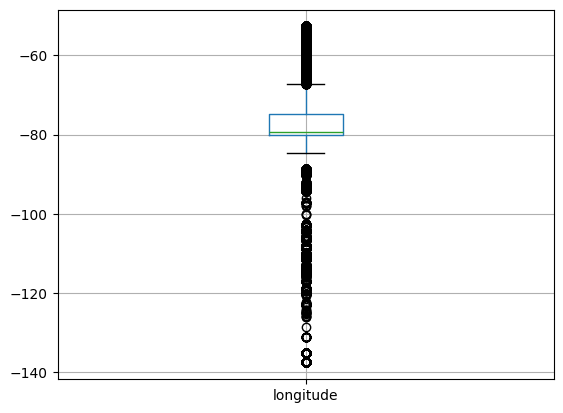

In [149]:
# let's look at box and whisker plot
insurance_train_data.boxplot(column = col);

Doesn't look like there are major outliers.

In [150]:
# looking at latitude
col = outlier_features[next(j)][0]
print(col)

latitude


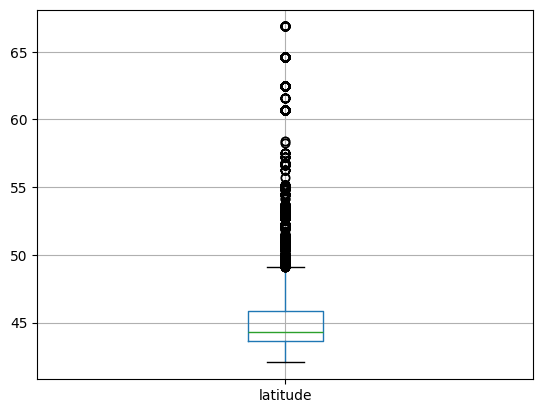

In [ ]:
# let's look at box and whisker plot
insurance_train_data.boxplot(column = col);

In [151]:
# looking at vehicle value
col = outlier_features[next(j)][0]
print(col)

VEHICLE_VALUE


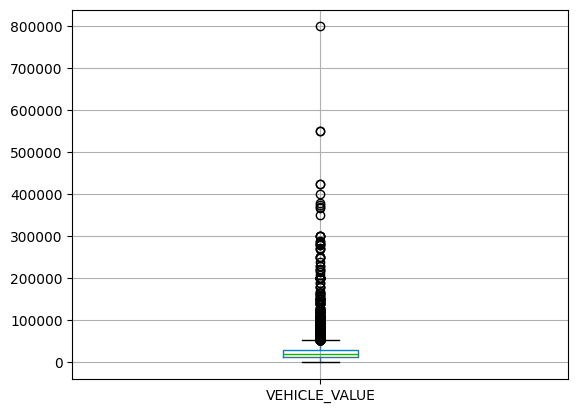

In [ ]:
# let's look at box and whisker plot
insurance_train_data.boxplot(column = col);

Looks like there is one major outlier.

In [ ]:
# arranging dataset by decreasing vehicle value
insurance_train_data.sort_values(by=[col],ascending=False)

,QUOTEDATE,VEHICLEYEAR,VEHICLEMAKE,VEHICLEMODEL,ANNUAL_KM,COMMUTE_DISTANCE,VEHICLE_OWNERSHIP,VEHICLE_VALUE,VEHICLEUSE,GENDER,...,MARITAL_STATUS,OCCUPATION,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,SUSPENSION_COUNT,IS_BOUND,latitude,longitude
95096,2016-11-25,2016,LAMBORGHINI,AVENTADOR LP750 SUPERVELOCE ROADSTER AWD,5000.0,10.0,Undisclosed,800000.0,Pleasure,Female,...,Married,Not Known,0,0,0,0,0,0,43.8227,-79.3946
7251,2016-02-29,2016,LAMBORGHINI,HURACAN LP610 SPYDER AWD,10000.0,10.0,Owned,550000.0,Pleasure,Male,...,Single,Not Known,0,0,0,0,0,0,42.9551,-81.6223
37851,2016-05-30,2016,LAMBORGHINI,HURACAN LP610 2DR AWD,10000.0,5.0,Owned,550000.0,Commute,Male,...,Single,Not Known,1,0,0,0,0,1,43.7673,-79.4111
89719,2016-11-05,2017,FERRARI,488 GTB 2DR,20000.0,15.0,Owned,425000.0,Commute,Male,...,Single,Not Known,1,0,0,0,0,0,43.7673,-79.4111
13449,2016-03-22,2017,FERRARI,CALIFORNIA T CONVERTIBLE,10000.0,15.0,Undisclosed,425000.0,Commute,Male,...,Single,Not Known,0,0,0,0,0,0,44.0001,-79.4663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94145,2016-11-22,2009,ACURA,TSX 4DR,30000.0,25.0,Undisclosed,2.0,Commute,Male,...,Married,Not Known,0,0,0,0,0,0,43.5924,-79.7611
31288,2016-05-10,2014,LANDROVER,LR2 SE 4DR 4WD,14500.0,10.0,Owned,2.0,Pleasure,Male,...,Married,Not Known,0,0,0,0,0,0,43.5637,-79.7202
94626,2016-11-23,2016,MERCEDES-BENZ TRUCK,GLA250 4DR AWD,20000.0,15.0,Owned,2.0,Commute,Female,...,Married,Not Known,0,0,0,0,0,0,43.5102,-79.6296
39208,2016-06-01,2013,HONDA,PILOT,10000.0,10.0,Undisclosed,2.0,Commute,Male,...,Married,Not Known,0,0,0,0,0,0,43.8432,-79.5644


$800k for LAMBORGHINI sounds reasonable. Let's keep it.

In [152]:
# looking at vehicle year
col = outlier_features[next(j)][0]
print(col)

VEHICLEYEAR


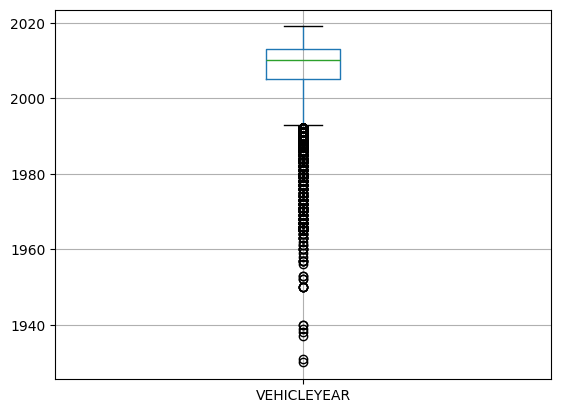

In [153]:
# let's look at box and whisker plot
insurance_train_data.boxplot(column = col);

`VEHICLEYEAR` seems fine. Moving on.

#### Annual km

In [154]:
# looking at Annual_km
col = outlier_features[next(j)][0]
print(col)

ANNUAL_KM


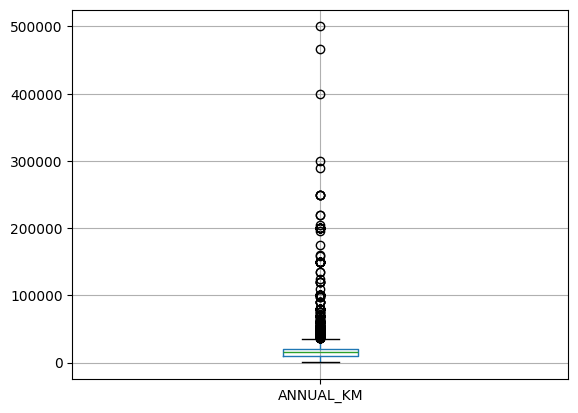

In [ ]:
# let's look at box and whisker plot
insurance_train_data.boxplot(column = col);

In [ ]:
# arranging data in descending order of annual km
insurance_train_data.sort_values(by=[col],ascending=False)

,QUOTEDATE,VEHICLEYEAR,VEHICLEMAKE,VEHICLEMODEL,ANNUAL_KM,COMMUTE_DISTANCE,VEHICLE_OWNERSHIP,VEHICLE_VALUE,VEHICLEUSE,GENDER,...,MARITAL_STATUS,OCCUPATION,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,SUSPENSION_COUNT,IS_BOUND,latitude,longitude
2735,2016-02-01,2016,HYUNDAI TRUCK/VAN,SANTA FE SPORT 2.0T 4DR AWD,500000.0,20.0,Owned,33681.135417,Commute,Male,...,Married,Not Known,0,0,0,0,0,0,43.3592,-80.3347
34754,2016-05-19,2013,DODGE/RAM TRUCK/VAN,RAM 1500 SPORT CREW CAB 4WD,466000.0,50.0,Owned,42000.000000,Commute,Male,...,Married,Not Known,0,0,0,0,0,0,44.1149,-79.5014
53351,2016-07-13,2007,NISSAN,VERSA 1.8 S 5DR,400000.0,10.0,Undisclosed,8000.000000,Business,Male,...,Married,Not Known,0,0,0,0,0,0,45.6138,-62.9506
54108,2016-07-14,2014,TOYOTA,RAV4,300000.0,20.0,Undisclosed,25000.000000,Commute,Male,...,Married,Not Known,1,0,1,0,0,0,43.9702,-80.0160
86016,2016-10-24,1997,ACURA,3.0CL 2DR,290000.0,10.0,Undisclosed,8146.250000,Pleasure,Male,...,Married,Not Known,0,0,0,0,0,0,43.4881,-79.7098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34282,2016-05-18,2016,ARCTIC CAT,WILD CAT TRAIL,200.0,10.0,Owned,14000.000000,Pleasure,Male,...,Married,Trades,0,0,0,0,0,1,54.4930,-104.3049
53836,2016-07-14,1989,GMC TRUCK/VAN,C/R 1500 PICKUP REG CAB 2WD,200.0,10.0,Undisclosed,12550.000000,Pleasure,Male,...,Married,Not Known,0,0,0,0,0,0,45.9976,-64.8483
85698,2016-10-23,2013,HYUNDAI TRUCK/VAN,SANTA FE 2.0T 4DR AWD,200.0,10.0,Undisclosed,30000.000000,Commute,Male,...,Single,Not Known,0,0,0,1,0,0,50.4855,-104.6163
51062,2016-07-06,2003,CHEVROLET,CAVALIER VL 2DR,150.0,6.0,Undisclosed,3700.000000,Commute,Female,...,Single,Not Known,0,0,0,0,0,1,44.6087,-79.4207


#### Key insight

Six figure `ANNUAL_KM` seems like a data entry error. An average annual km limit on a leased vehicle is 24,000 km. Therefore 100,000 km and above annually seems highly unkilely. Let's divide these values by 10 assuming these values are data entry errors to bring them to a more believable range.

In [155]:
def annual_km_above_threshold(df, threshold = 100000):
    '''
    This function returns corrected ANNUAL_KM for values over 100000 km by
    dividing them by 10. Assumption here is that this could be a data entry
    error.
    Args: df: dataframe
    threshold: value over which ANNUAL_KM is corrected
    Return: df: dataframe with ANNUAL_KM corrected value
    '''
    # iterating over rows in training data
    for index, row in df.iterrows():
        annual_km = row[col]
        # Check if the annual mileage is greater than or equal to 100,000
        if annual_km >= threshold:
            # Reduce the annual mileage by dividing it by 10
            df.at[index, col] = annual_km/10.
    return df

In [156]:
insurance_train_data = annual_km_above_threshold(insurance_train_data)

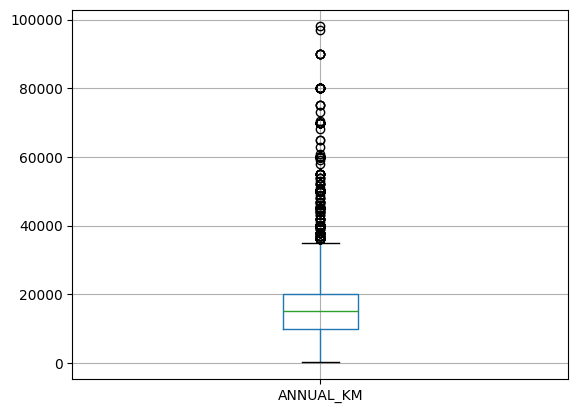

In [ ]:
# checking boxplot of annual km again
insurance_train_data.boxplot(column = col);

In [157]:
insurance_test_data = annual_km_above_threshold(insurance_test_data)

In [158]:
# looking at year of birth
col = outlier_features[next(j)][0]
print(col)

YEAR_OF_BIRTH


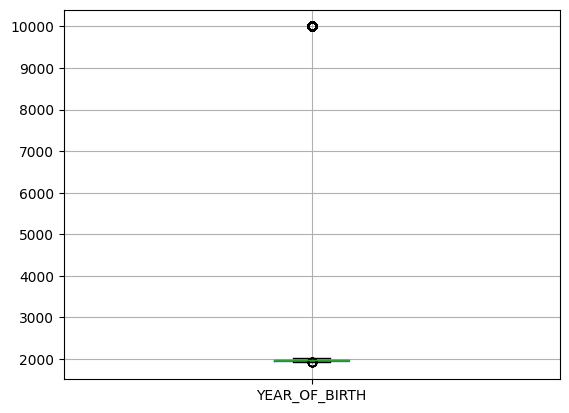

In [ ]:
# let's look at box and whisker plot
insurance_train_data.boxplot(column = col);

#### Years licenced

In [159]:
# looking at years licenced
col = outlier_features[next(j)][0]
print(col)

YEARS_LICENSED


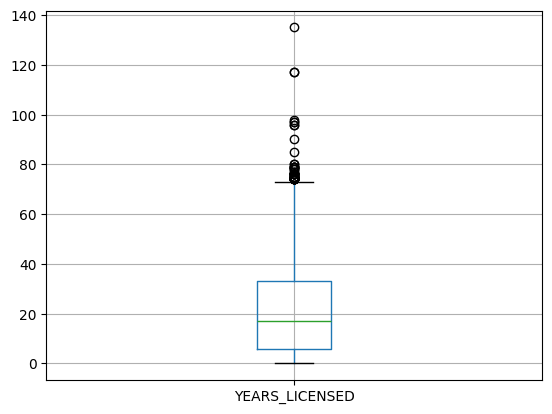

In [ ]:
# let's look at box and whisker plot
insurance_train_data.boxplot(column = col);

**Key insight:** Rows with 100 years or more of years licenced seem suspicious. Let's take a closer look. We see that there are some entries that have vehicles from 2013-16, year of birth between 1959 to 1990 and yet having licence for more than 100 years. This could be a data entry error where 117 years is actually 17 years. We will correct such entries.

In [ ]:
insurance_train_data.loc[insurance_train_data[col] > 100].T

,24380,27694,96374
QUOTEDATE,2016-04-22 00:00:00,2016-05-02 00:00:00,2016-12-01 00:00:00
VEHICLEYEAR,2016,2016,2013
VEHICLEMAKE,NISSAN,NISSAN,SUZUKI
VEHICLEMODEL,SENTRA 1.8 SV 4DR,SENTRA 1.8 SV 4DR,SX4 JX 5DR
ANNUAL_KM,20000.0,25000.0,15000.0
COMMUTE_DISTANCE,25.0,25.0,15.0
VEHICLE_OWNERSHIP,Owned,Undisclosed,Owned
VEHICLE_VALUE,22000.0,22000.0,23000.0
VEHICLEUSE,Commute,Commute,Commute
GENDER,Female,Female,Male


In [160]:
def years_licenced(df):
    '''
    This function replaces outliers with YEARS_LICENSED = 135 with 35 and 117
    with 11 assuming it could be a data entry error.
    Args: df: dataframe
    Returns: corrected dataframe
    '''
    df.loc[df['YEARS_LICENSED'] == 135., 'YEARS_LICENSED'] = 35.
    df.loc[df['YEARS_LICENSED'] == 117., 'YEARS_LICENSED'] = 11.

    return df

In [161]:
insurance_train_data = years_licenced(insurance_train_data)

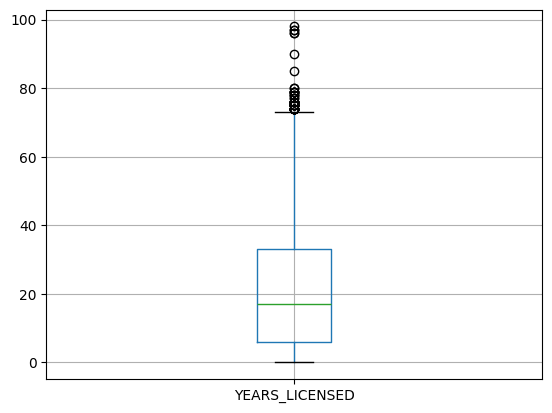

In [ ]:
insurance_train_data.boxplot(column = col);

In [162]:
insurance_test_data = years_licenced(insurance_test_data)

#### Commute distance

In [163]:
# looking at daily commute distance
col = outlier_features[next(j)][0]
print(col)

COMMUTE_DISTANCE


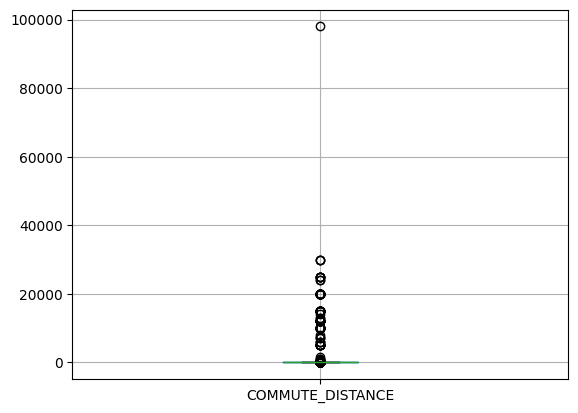

In [ ]:
# let's look at box and whisker plot
insurance_train_data.boxplot(column = col);

In [ ]:
# sorting the dataset in descending values of commute distance
insurance_train_data.sort_values(by=[col],ascending=False)

,QUOTEDATE,VEHICLEYEAR,VEHICLEMAKE,VEHICLEMODEL,ANNUAL_KM,COMMUTE_DISTANCE,VEHICLE_OWNERSHIP,VEHICLE_VALUE,VEHICLEUSE,GENDER,...,MARITAL_STATUS,OCCUPATION,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,SUSPENSION_COUNT,IS_BOUND,latitude,longitude
18895,2016-04-08,2015,FORD TRUCK/VAN,F150 XL SUPERCREW 4WD,9800.0,98000.0,Owned,43625.248826,Pleasure,Male,...,Married,Not Known,0,0,0,0,0,0,43.2788,-81.5442
93038,2016-11-17,2009,HONDA,CIVIC DX-G 4DR,15000.0,30000.0,Undisclosed,15685.272727,Commute,Female,...,Married,Not Known,0,0,0,0,0,0,46.2198,-64.5411
13663,2016-03-22,2002,AUDI,ALLROAD QUATTRO WAGON,15000.0,30000.0,Undisclosed,5000.000000,Commute,Male,...,Married,Not Known,2,0,0,1,0,1,44.0586,-79.6235
38057,2016-05-30,2008,VOLKSWAGEN,RABBIT 2.5 2DR HATCHBACK,15000.0,30000.0,Undisclosed,14281.866667,Commute,Male,...,Married,Professional/Other,0,0,0,0,0,0,48.1666,-53.9648
70391,2016-09-02,2011,BMW TRUCK/VAN,X5 35D 4DR AWD,15000.0,25000.0,Undisclosed,69750.000000,Commute,Male,...,Married,Not Known,2,0,0,0,0,1,43.8227,-79.3946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81881,2016-10-11,2016,CHEVROLET TRUCK/VAN,EQUINOX LT 4DR AWD,15000.0,1.0,Undisclosed,41164.842105,Commute,Male,...,Single,Not Known,0,0,0,0,0,0,46.1133,-61.0251
81941,2016-10-11,2008,DODGE/RAM TRUCK/VAN,NITRO SE 4DR 4WD,10000.0,1.0,Undisclosed,15000.000000,Commute,Female,...,Single,Not Known,0,0,0,0,0,0,47.2195,-53.1448
81943,2016-10-11,2014,JEEP,WRANGLER SPORT 4WD,20000.0,1.0,Owned,30000.000000,Commute,Male,...,Single,Not Known,0,0,0,0,0,0,47.7113,-53.2953
81954,2016-10-11,2006,CHEVROLET TRUCK/VAN,UPLANDER LS,20000.0,1.0,Undisclosed,18255.649351,Commute,Female,...,Single,Not Known,0,0,0,0,0,0,48.0075,-66.6727


**Key insight**

Daily commute distance cannot be greater than annual km. This could be a data entry error where the two numbers could have been swapped. Let's swap those columns where `ANNUAL_KM` is smaller than `COMMUTE_DISTANCE`.

In [164]:
def swap_annual_km_commute(df):
    '''
    This function swaps ANNUAL_KM and COMMUTE_DISTANCE in cases where
    ANNUAL_KM < COMMUTE_DISTANCE.
    Args: df: dataframe
    Returns: df: df with correct ANNUAL_KM and COMMUTE_DISTANCE.
    '''
    # iterating over rows in training set
    for index, row in df.iterrows():
        annual_km = row['ANNUAL_KM']
        commute_dist = row['COMMUTE_DISTANCE']
        if annual_km < commute_dist:
            # Swap the values of 'COMMUTE_DISTANCE' and 'ANNUAL_KM'
            df.at[index, 'COMMUTE_DISTANCE'] = annual_km
            df.at[index, 'ANNUAL_KM'] = commute_dist
    return df

In [165]:
insurance_train_data = swap_annual_km_commute(insurance_train_data)

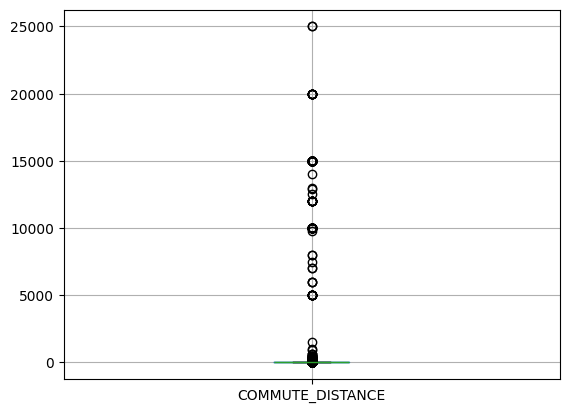

In [ ]:
# looking at COMMUTE_DISTANCE distribution again
insurance_train_data.boxplot(column = col);

In [166]:
insurance_test_data = swap_annual_km_commute(insurance_test_data)

In [167]:
# looking at the dataset again with COMMUTE_DISTACNE >= 5000
# since values above it seem to be extreme outliers.
outlier_df = insurance_train_data.loc[insurance_train_data[col] >= 5000]
print('number of outliers:', outlier_df.shape[0])
outlier_df.head()

number of outliers: 156


,QUOTEDATE,VEHICLEYEAR,VEHICLEMAKE,VEHICLEMODEL,ANNUAL_KM,COMMUTE_DISTANCE,VEHICLE_OWNERSHIP,VEHICLE_VALUE,VEHICLEUSE,GENDER,...,MARITAL_STATUS,OCCUPATION,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,SUSPENSION_COUNT,IS_BOUND,latitude,longitude
1216,2016-01-19,2012,TOYOTA TRUCK/VAN,HIGHLANDER V6 4DR 4WD,15000.0,15000.0,Undisclosed,26000.000000,Commute,Female,...,Married,Not Known,0,0,0,0,0,0,46.0771,-64.8529
1703,2016-01-22,2000,FORD TRUCK/VAN,EXPEDITION XLT 4DR 2WD,15000.0,10000.0,Undisclosed,12022.222222,Commute,Female,...,Married,Not Known,0,0,0,0,0,0,60.7161,-135.0537
2007,2016-01-26,2014,CHEVROLET,CRUZE LS 4DR,10000.0,10000.0,Undisclosed,23548.649635,Pleasure,Male,...,Married,Not Known,0,0,0,1,0,0,44.6573,-75.7146
2186,2016-01-27,2013,KIA,RIO EX 4DR,10000.0,10000.0,Undisclosed,20407.920000,Pleasure,Male,...,Single,Not Known,0,0,0,0,0,0,43.6655,-79.4378
3484,2016-02-05,2003,GMC TRUCK/VAN,SONOMA SLS EXT CAB 2WD,5000.0,5000.0,Undisclosed,5000.000000,Pleasure,Male,...,Single,Not Known,0,0,0,0,0,0,45.9188,-64.3845


**Key insight**

It seems like there are still suspicious entries with `COMMUTE_DISTANCE` greater than 5000 km. Since there are only 156 such records, let's drop these entries.

In [168]:
# dropping commute distance outliers
insurance_train_data.drop(index=outlier_df.index, inplace = True)

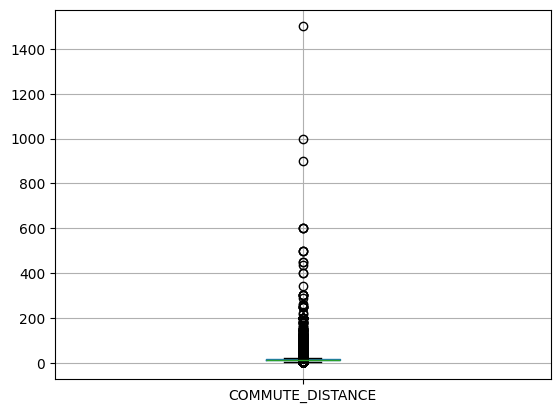

In [ ]:
# looking at the distribution of commute distance again
insurance_train_data.boxplot(column = col);

In [169]:
# looking at conviction count
col = outlier_features[next(j)][0]
print(col)

CONVICTION_COUNT_MINOR_3YRS


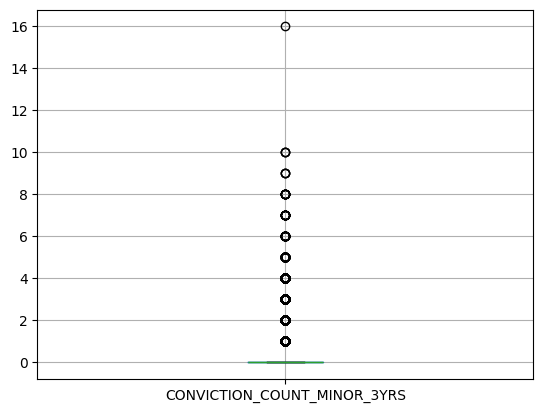

In [ ]:
insurance_train_data.boxplot(column = col);

In [ ]:
# looking at conviction count
col = outlier_features[next(j)][0]
print(col)

CONVICTION_COUNT_MAJOR_3YRS


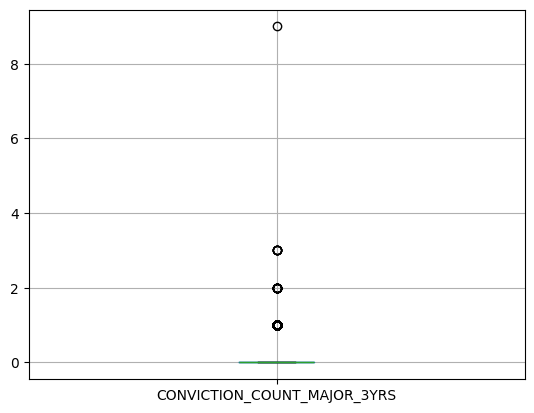

In [ ]:
insurance_train_data.boxplot(column = col);

In [ ]:
# looking at assigned losses
col = outlier_features[next(j)][0]
print(col)

CONVICTION_COUNT_CRIMINAL_3YRS


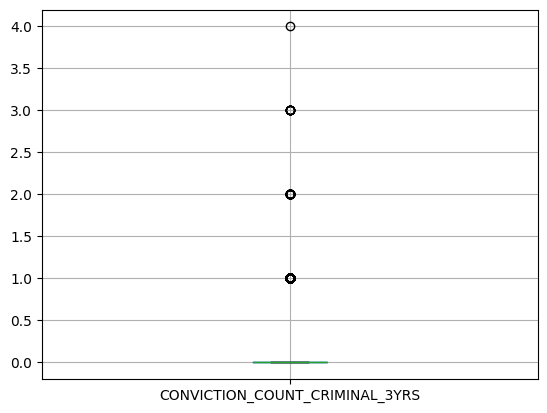

In [ ]:
insurance_train_data.boxplot(column = col);

In [ ]:
# looking at suspension count
col = outlier_features[next(j)][0]
print(col)

ASSIGNED_LOSSES_PD_5YRS


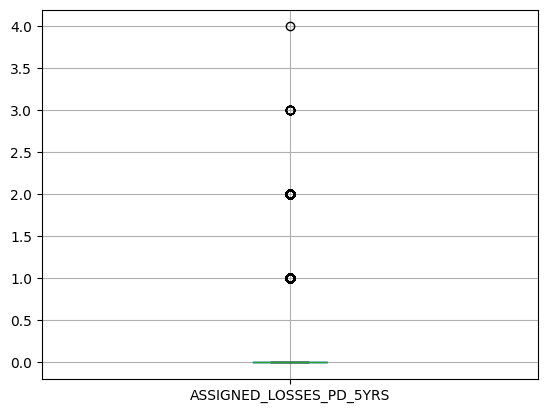

In [ ]:
insurance_train_data.boxplot(column = col);

# Univariate Analysis

In this section, we try to build an intuition about the most important features in our dataset that can distinguish between the positive and negative class. For numerical columns, we make boxplots to compare the distributions between the positive and negative class. Using t-test, we check if there are significant differences between the distributions. We find that longitude is the best feature distinguishing between the two classes in the dataset followed by the year of birth.

For categorical columns, we create contingency tables comparing the observed and expected distributions between classes. We use chi-square test to compare the distributions. We find that multi-product is the best categorical feature separating the two classes. Buyers more frequently bought multi/bundled products than non-buyers.

## Numerical feature importances

In [ ]:
# creating a list of float and integer values
# except IS_BOUND since it is the output variable
numerical_columns = list(insurance_train_data.select_dtypes(include = np.number).columns)
numerical_columns.remove('IS_BOUND')

In [ ]:
# Iterate over each numerical feature
for feature in numerical_columns:
    # Select values of the current feature where 'IS_BOUND' is 0
    feature_0 = insurance_train_data.loc[insurance_train_data['IS_BOUND'] == 0][feature].values
    # Select values of the current feature where 'IS_BOUND' is 1
    feature_1 = insurance_train_data.loc[insurance_train_data['IS_BOUND'] == 1][feature].values
    # Perform a t-test on the two sets of values
    ttest_result = ttest_ind(feature_0, feature_1, equal_var=False)
    if (ttest_result.pvalue < 0.05):
        print(feature)
        print('t-statistic =', round(ttest_result.statistic, 2), ', p-value =', ttest_result.pvalue)
        print('********')

VEHICLEYEAR
t-statistic = 5.46 , p-value = 4.89875208329829e-08
********
YEAR_OF_BIRTH
t-statistic = 17.28 , p-value = 8.749804151451406e-67
********
CONVICTION_COUNT_MAJOR_3YRS
t-statistic = 8.17 , p-value = 3.186189319966509e-16
********
CONVICTION_COUNT_CRIMINAL_3YRS
t-statistic = 6.97 , p-value = 3.0992903374806033e-12
********
SUSPENSION_COUNT
t-statistic = 4.65 , p-value = 3.3654669669409774e-06
********
latitude
t-statistic = 15.54 , p-value = 2.6488071805678657e-54
********
longitude
t-statistic = 27.92 , p-value = 5.202279890690949e-170
********


**Key observation:** From the p-values, we see that location (longitude and latitude) and year of birth are key features distinguishing customers who did or didn't buy insurance.

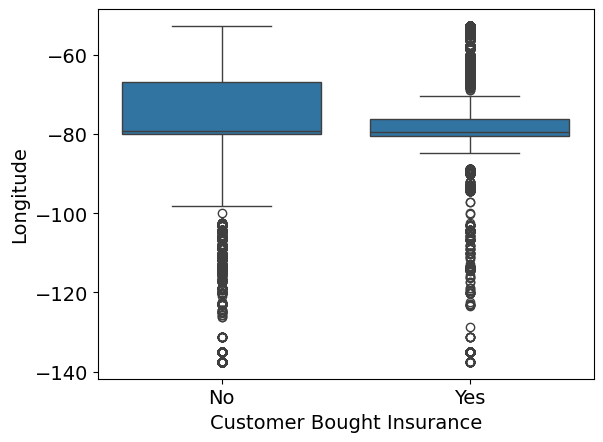

In [ ]:
ax = sns.boxplot(data=insurance_train_data, x='IS_BOUND', y='longitude')
plt.xlabel('Customer Bought Insurance',fontsize=14)
plt.ylabel('Longitude',fontsize=14)
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'], fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [ ]:
print('array([25%ile, 50%ile, 75%ile]) values of Longitude for non-buyers')
print(np.percentile(insurance_train_data.loc[insurance_train_data['IS_BOUND'] == 0]['longitude'], [25,50,75]))

array([25%ile, 50%ile, 75%ile]) values of Longitude for non-buyers
[-79.886  -79.2819 -66.9328]


In [ ]:
print('array([25%ile, 50%ile, 75%ile]) values of Longitude for buyers')
print(np.percentile(insurance_train_data.loc[insurance_train_data['IS_BOUND'] == 1]['longitude'], [25,50,75]))

array([25%ile, 50%ile, 75%ile]) values of Longitude for buyers
[-80.4414 -79.4207 -76.2494]


**Key observation:** From the comparison above we see that the 75 percentile of longitude is different for buyers (-76.25) and non-buyers (-66.93).

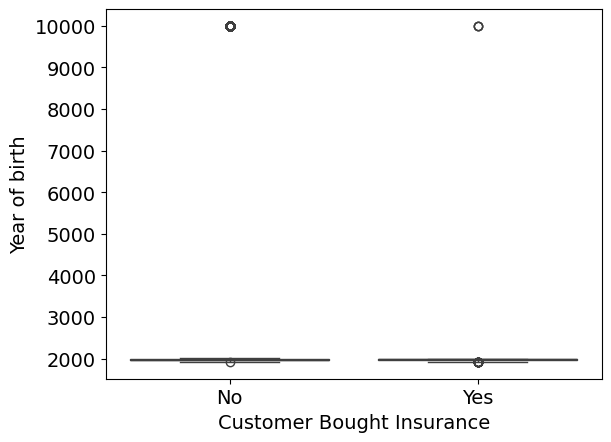

In [ ]:
ax = sns.boxplot(data=insurance_train_data, x='IS_BOUND', y='YEAR_OF_BIRTH')
plt.xlabel('Customer Bought Insurance',fontsize=14)
plt.ylabel('Year of birth',fontsize=14)
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'], fontsize=14)
plt.yticks(fontsize=14)
# plt.ylim(1900, 2010)
plt.show()

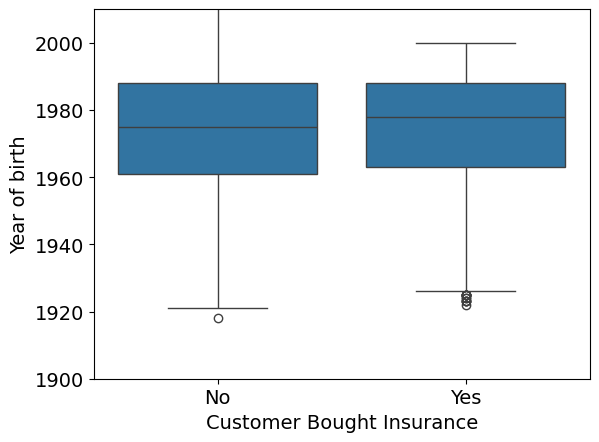

In [ ]:
ax = sns.boxplot(data=insurance_train_data, x='IS_BOUND', y='YEAR_OF_BIRTH')
plt.xlabel('Customer Bought Insurance',fontsize=14)
plt.ylabel('Year of birth',fontsize=14)
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'], fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(1900, 2010)
plt.show()

## Categorical columns

### Data pre-processing

In [170]:
# making list of columns containing strings/categories
string_columns = [col for col in insurance_train_data.columns if col not in numerical_columns]

In [171]:
# looking at categorical columns
string_columns

['QUOTEDATE',
 'VEHICLEMAKE',
 'VEHICLEMODEL',
 'VEHICLE_OWNERSHIP',
 'VEHICLEUSE',
 'GENDER',
 'POSTAL_CODE',
 'AREA_CODE',
 'MULTI_PRODUCT',
 'MARITAL_STATUS',
 'OCCUPATION']

In [172]:
# Let's count the total number of categories in each feature
for col in string_columns:
    print('Number of categories in column', col, '=', len(Counter(insurance_train_data[col])))

Number of categories in column QUOTEDATE = 346
Number of categories in column VEHICLEMAKE = 185
Number of categories in column VEHICLEMODEL = 5820
Number of categories in column VEHICLE_OWNERSHIP = 4
Number of categories in column VEHICLEUSE = 10
Number of categories in column GENDER = 2
Number of categories in column POSTAL_CODE = 1138
Number of categories in column AREA_CODE = 196
Number of categories in column MULTI_PRODUCT = 2
Number of categories in column MARITAL_STATUS = 5
Number of categories in column OCCUPATION = 19


**Key insight**

Since `VEHCILEMODEL` have lots of categories, let's only consider those with 50 entries. For lesser categories, we can club the entries together as a 'rare' category. `POSTAL_CODE` and `AREA_CODE` can be dropped since we made 2 columns containing latitudes and longitudes.

In [173]:
# dictionary containing vehicle models and counts
vehicle_models_dict = Counter(insurance_train_data['VEHICLEMODEL'])

In [174]:
def reduced_vehicle_model_column(df):
    '''
    The function takes the dataframe df as input and returns a list of the top
    vehicle models.
    '''
    # Create an empty list to store the top vehicle models
    top_vehicle_models = []
    # Iterate through each row in the dataframe
    for index, row in df.iterrows():
        # Get the vehicle model from the current row
        vehicle_model = row['VEHICLEMODEL']
        # Check if the count of the vehicle model is greater than 50
        if vehicle_models_dict[vehicle_model] > 50:
            # If it is, add the vehicle model to the top vehicle models list
            top_vehicle_models.append(vehicle_model)
        else:
            # If it's not, add 'rare' to the top vehicle models list
            top_vehicle_models.append('rare')
    # Return the list of top vehicle models
    return top_vehicle_models

In [175]:
# We will append column named TOPVEHICLEMODELS. Original name will be used if the frequency of that model in the column is greater than
# 50 else it will be labelled 'rare'
top_vehicle_models = reduced_vehicle_model_column(insurance_train_data)

In [176]:
# Let's drop the original VEHICLEMODEL, AREA_CODE and POSTAL_CODE columns
insurance_train_data_reduced = insurance_train_data.drop(columns=['VEHICLEMODEL', 'POSTAL_CODE', 'AREA_CODE'])
insurance_train_data_reduced.shape

(101735, 22)

In [177]:
insurance_train_data_reduced['TOPVEHICLEMODELS'] = top_vehicle_models

In [178]:
top_vehicle_models = reduced_vehicle_model_column(insurance_test_data)
insurance_test_data_reduced = insurance_test_data.drop(columns=['VEHICLEMODEL', 'POSTAL_CODE', 'AREA_CODE'])
insurance_test_data_reduced['TOPVEHICLEMODELS'] = top_vehicle_models

**Key step**

All `QUOTEDATE`s belong to year 2016. Therefore only month in the `QUOTEDATE`s are meaningful which are in numerical form. However, greater values of month don't necessarily imply that they play a greater role in whether customers buy the insurance. Let's extract month from `QUOTEDATE` and convert them to string.

In [179]:
# Using the QUOTEDATE column we will extract the month values from the entries and create a new feature called months and drop the original column.
month = insurance_train_data_reduced['QUOTEDATE'].dt.month
insurance_train_data_reduced['MONTH'] = [str(val) for val in month.values]
insurance_train_data_reduced.drop(columns=['QUOTEDATE'],inplace=True)

In [180]:
month = insurance_test_data_reduced['QUOTEDATE'].dt.month
insurance_test_data_reduced['MONTH'] = [str(val) for val in month.values]
insurance_test_data_reduced.drop(columns=['QUOTEDATE'],inplace=True)

### Feature importances

Let's perform statistical tests to examine features that distinguish between buyers and non-buyers the most.

In [ ]:
insurance_train_data_reduced.head()

,VEHICLEYEAR,VEHICLEMAKE,ANNUAL_KM,COMMUTE_DISTANCE,VEHICLE_OWNERSHIP,VEHICLE_VALUE,VEHICLEUSE,GENDER,YEAR_OF_BIRTH,YEARS_LICENSED,...,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,SUSPENSION_COUNT,IS_BOUND,latitude,longitude,TOPVEHICLEMODELS,MONTH
0,2006,VOLKSWAGEN,10000.0,10.0,Owned,3000.000000,Pleasure,Male,1975,25.0,...,0,0,0,0,0,0,45.6442,-73.8448,rare,1
1,2017,HYUNDAI,20000.0,10.0,Owned,27017.815126,Business,Male,1958,10.0,...,0,0,0,0,0,0,43.1607,-79.7463,ELANTRA GL 4DR,1
2,2015,CHEVROLET TRUCK/VAN,15000.0,10.0,Undisclosed,39222.673611,Pleasure,Male,1960,39.0,...,0,0,0,0,0,0,53.5996,-113.4549,rare,1
3,2010,TOYOTA,20000.0,20.0,Undisclosed,18757.525692,Commute,Male,1985,3.0,...,0,0,0,0,0,0,43.7196,-79.6854,COROLLA CE 4DR,1
4,2013,HONDA,30000.0,30.0,Undisclosed,23062.825243,Commute,Male,1982,2.0,...,0,0,0,0,0,0,43.8479,-79.3288,CIVIC LX 4DR,1


In [ ]:
# creating a list of categorical features
categorical_columns = [col for col in insurance_train_data_reduced.columns if col not in numerical_columns]
categorical_columns.remove('IS_BOUND')
categorical_columns

['VEHICLEMAKE',
 'VEHICLE_OWNERSHIP',
 'VEHICLEUSE',
 'GENDER',
 'MULTI_PRODUCT',
 'MARITAL_STATUS',
 'OCCUPATION',
 'TOPVEHICLEMODELS',
 'MONTH']

In [ ]:
def contingency_table(df, feature):
    '''
    The function takes a DataFrame df and a feature name
    as input and returns a contingency table. A contingency table is a
    table that shows the frequency distribution of two categorical variables.
    '''
    # Get the unique categories of the feature
    feature_categories = list(Counter(df[feature]).keys())
    # Calculate the number of categories
    dim = len(feature_categories)
    # Create a contingency table with 2 rows and dim columns
    table = np.zeros((2, dim))
    # Iterate over the rows and columns of the table
    for row in range(2):
        for column in range(dim):
            # Count the number of occurrences where IS_BOUND is equal to row and feature is equal to the category
            table[row, column] = df.loc[(df['IS_BOUND'] == row) & (df[feature] == feature_categories[column])].shape[0]

    return table

In [ ]:
print('feature name,', 'chi square value,', 'p value,', 'degree of freedom\n')
# iterate over categorical features
for feature in categorical_columns:
    # make contingency table
    table = contingency_table(insurance_train_data_reduced, feature)
    # calculate chi-square value for the contingency table
    stat, p, dof, expected = chi2_contingency(table)
    if p < 0.05:
        print(feature, ',', round(stat), ',', p, dof)

feature name, chi square value, p value, degree of freedom

VEHICLEMAKE , 280 , 6.182986688719945e-06 184
VEHICLEUSE , 74 , 2.20795575360826e-12 9
GENDER , 4 , 0.048663782750086274 1
MULTI_PRODUCT , 1141 , 3.838822940178035e-250 1
MARITAL_STATUS , 41 , 2.4734733526879345e-08 4
OCCUPATION , 82 , 4.0996961521779523e-10 18
TOPVEHICLEMODELS , 607 , 1.4321236916348883e-08 425


**Key observation:** `MULTI_PRODUCT` has the smallest p-value. Let's examine that feature.

In [ ]:
feature = 'MULTI_PRODUCT'
table = contingency_table(insurance_train_data_reduced, feature)
stat, p, dof, expected = chi2_contingency(table)
print(feature)
print('observed distribution:\n', table)
print('expected distribution:\n', np.around(expected))

MULTI_PRODUCT
observed distribution:
 [[29376. 50092.]
 [ 5523. 16744.]]
expected distribution:
 [[27261. 52207.]
 [ 7638. 14629.]]


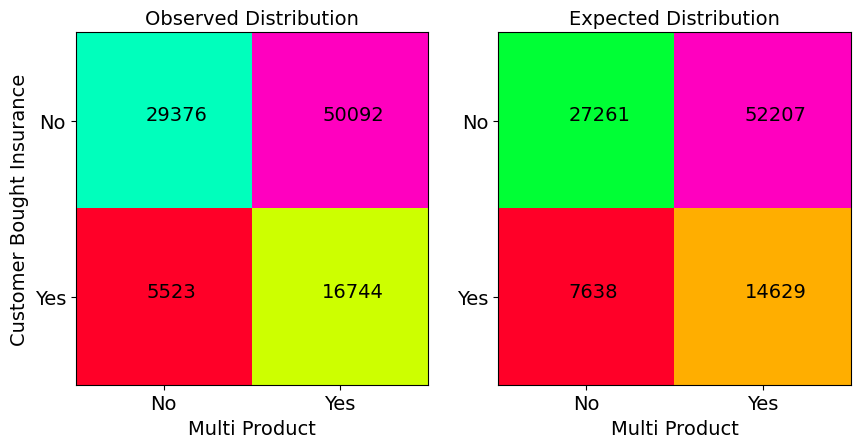

In [ ]:
figure(figsize=(10, 5))

plt.subplot(1,2,1)
plt.imshow(table, cmap=plt.cm.gist_rainbow)
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'], fontsize=14)
plt.yticks(ticks=[0, 1], labels=['No', 'Yes'], fontsize=14)
plt.ylabel('Customer Bought Insurance', fontsize=14)
plt.xlabel('Multi Product', fontsize=14)
plt.text(-0.1,0,round(table[0,0]), fontsize=14)
plt.text(0.9,0,round(table[0,1]), fontsize=14)
plt.text(-0.1,1,round(table[1,0]), fontsize=14)
plt.text(0.9,1,round(table[1,1]), fontsize=14)
plt.title('Observed Distribution', fontsize=14);

plt.subplot(1,2,2)
plt.imshow(expected, cmap=plt.cm.gist_rainbow)
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'], fontsize=14)
plt.yticks(ticks=[0, 1], labels=['No', 'Yes'], fontsize=14)
# plt.ylabel('Customer Bought Insurance', fontsize=14)
plt.xlabel('Multi Product', fontsize=14)
plt.text(-0.1,0,round(expected[0,0]), fontsize=14)
plt.text(0.9,0,round(expected[0,1]), fontsize=14)
plt.text(-0.1,1,round(expected[1,0]), fontsize=14)
plt.text(0.9,1,round(expected[1,1]), fontsize=14)
plt.title('Expected Distribution', fontsize=14);

**Key step:** At this stage, let's save the processed dataset before the next section.

In [181]:
insurance_train_data_reduced.to_csv('processed_data/insurance_train_data_reduced.csv', index=False)
insurance_test_data_reduced.to_csv('processed_data/insurance_test_data_reduced.csv', index=False)

# Model Development

## Data processing:
In this section, we continue processing the dataset before building the predictive model. Steps included in this section are:
* Correlation analysis: We analyze correlation between pairs of features. If the R2 value between two features is above 0.9, we drop one of the features. We did not find any highly correlated features in the dataset.
* Encoding categorical columns: We encode our nominal, categorical columns using one hot encoding.
* Train-validation split: Before scaling the dataset, we split the data into training and hold-out validation sets.
* Feature scaling: We scale our training dataset using the min-max scaler. Using the training parameters for scaling, we then scale the validation set.

### Correlation Analysis

In [182]:
insurance_train_data_reduced = pd.read_csv('processed_data/insurance_train_data_reduced.csv')
insurance_train_data_reduced.head()

,VEHICLEYEAR,VEHICLEMAKE,ANNUAL_KM,COMMUTE_DISTANCE,VEHICLE_OWNERSHIP,VEHICLE_VALUE,VEHICLEUSE,GENDER,YEAR_OF_BIRTH,YEARS_LICENSED,...,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,SUSPENSION_COUNT,IS_BOUND,latitude,longitude,TOPVEHICLEMODELS,MONTH
0,2006,VOLKSWAGEN,10000.0,10.0,Owned,3000.000000,Pleasure,Male,1975,25.0,...,0,0,0,0,0,0,45.6442,-73.8448,rare,1
1,2017,HYUNDAI,20000.0,10.0,Owned,27017.815126,Business,Male,1958,10.0,...,0,0,0,0,0,0,43.1607,-79.7463,ELANTRA GL 4DR,1
2,2015,CHEVROLET TRUCK/VAN,15000.0,10.0,Undisclosed,39222.673611,Pleasure,Male,1960,39.0,...,0,0,0,0,0,0,53.5996,-113.4549,rare,1
3,2010,TOYOTA,20000.0,20.0,Undisclosed,18757.525692,Commute,Male,1985,3.0,...,0,0,0,0,0,0,43.7196,-79.6854,COROLLA CE 4DR,1
4,2013,HONDA,30000.0,30.0,Undisclosed,23062.825243,Commute,Male,1982,2.0,...,0,0,0,0,0,0,43.8479,-79.3288,CIVIC LX 4DR,1


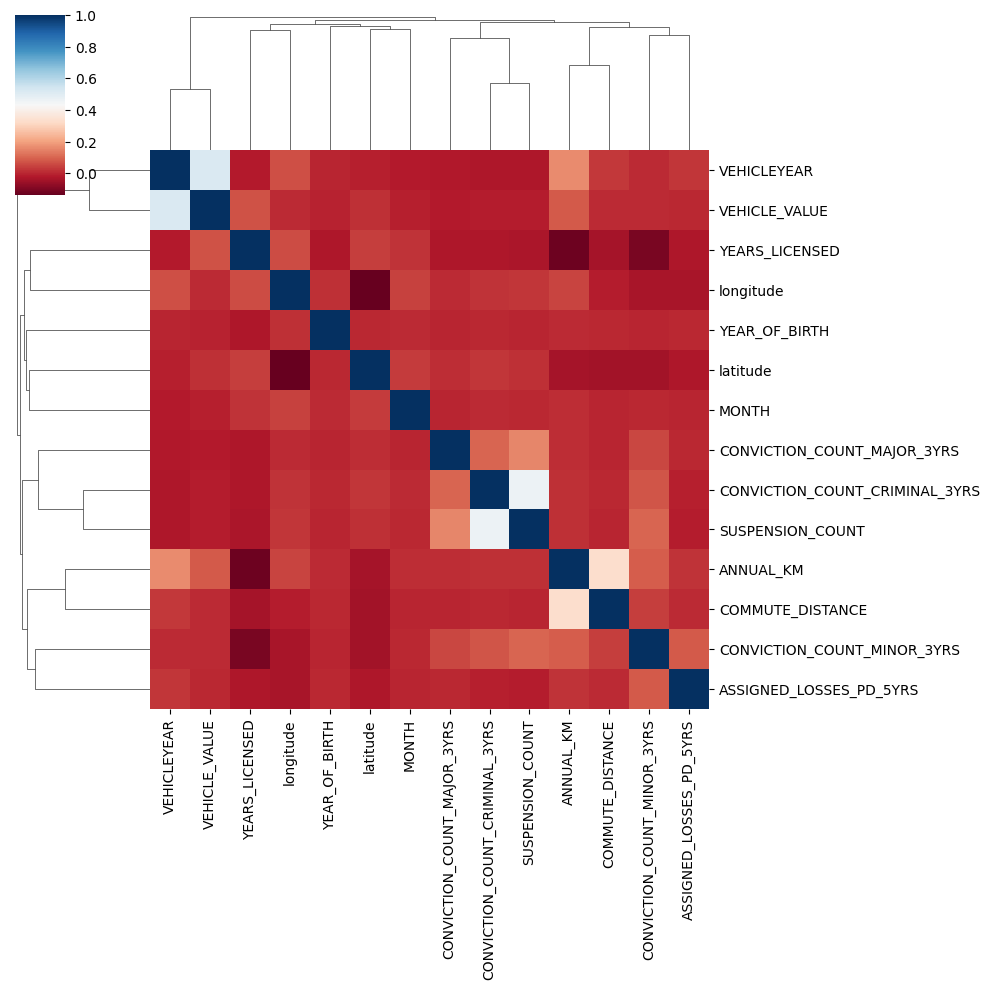

In [183]:
df = insurance_train_data_reduced.drop(columns=['IS_BOUND'])
numerical_columns = list(df.select_dtypes(include=np.number).columns.values)
if 'IS_BOUND' in numerical_columns:
    numerical_columns.remove('IS_BOUND')
sns.clustermap(df[numerical_columns].corr().fillna(value=0), cmap='RdBu');

In [184]:
# Initialize an empty list to store correlated feature pairs
correlated_pairs = []
# Calculate the correlation matrix for the normalized training data
train_set_corr_mat = df[numerical_columns].corr()
print('correlated pairs of features: \n')
# Iterate over the columns of the correlation matrix
for row in train_set_corr_mat.columns.values:
    # Iterate over the columns of the correlation matrix
    for col in train_set_corr_mat.columns.values:
          # Check if the R2 is greater than 0.9 and the features are not the same
        r2 = train_set_corr_mat.loc[row, col]**2
        if r2 > 0.9 and row != col:
            print(row, col, 'R2 =', round(r2, 3))
            # Add the correlated feature pair to the list
            correlated_pairs.append((row, col))

correlated pairs of features: 



### One hot encoding

In [185]:
# Now that our dataset is ready let's convert the categorical variables into dummy variables
# the converted numerical columns will have the original categorical columns as prefix
categorical_columns = [col for col in insurance_train_data_reduced.columns if col not in numerical_columns]
if 'IS_BOUND' in categorical_columns:
    categorical_columns.remove('IS_BOUND')
prefix = {col: col for col in categorical_columns}
insurance_train_data_reduced_numerical = pd.get_dummies(insurance_train_data_reduced, prefix = prefix, drop_first=True)

In [186]:
insurance_train_data_reduced_numerical.shape

(101735, 660)

In [187]:
insurance_train_data_reduced_numerical.head()

,VEHICLEYEAR,ANNUAL_KM,COMMUTE_DISTANCE,VEHICLE_VALUE,YEAR_OF_BIRTH,YEARS_LICENSED,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,...,TOPVEHICLEMODELS_WRANGLER SAHARA 4WD,TOPVEHICLEMODELS_WRANGLER SPORT 4WD,TOPVEHICLEMODELS_WRANGLER UNLIMITED SAHARA 4DR 4WD,TOPVEHICLEMODELS_WRANGLER UNLIMITED SPORT 4DR 4WD,TOPVEHICLEMODELS_X1 28I 4DR AWD,TOPVEHICLEMODELS_X3 28I 4DR AWD,TOPVEHICLEMODELS_XV CROSSTREK TOURING 5DR AWD,TOPVEHICLEMODELS_YARIS 4DR,TOPVEHICLEMODELS_YARIS LE 4DR HATCHBACK,TOPVEHICLEMODELS_rare
0,2006,10000.0,10.0,3000.000000,1975,25.0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,True
1,2017,20000.0,10.0,27017.815126,1958,10.0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,2015,15000.0,10.0,39222.673611,1960,39.0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,True
3,2010,20000.0,20.0,18757.525692,1985,3.0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,2013,30000.0,30.0,23062.825243,1982,2.0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [188]:
# Assign the target variable (y) and the features (X) that will be used to predict the target variable
y = insurance_train_data_reduced_numerical['IS_BOUND'].values
X = insurance_train_data_reduced_numerical.drop(columns = 'IS_BOUND')

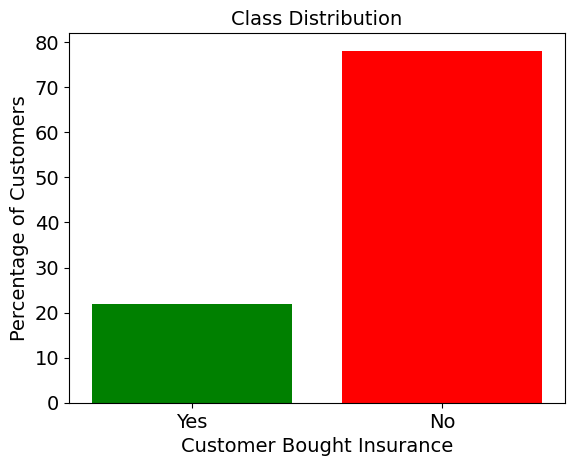

In [189]:
# Let's look at the distribution of the classes in the IS_BOUND i.e. the frequency of people buying insurance vs not. Seems like roughly
# 20 percent of the people end up buying insurance.
plt.bar([0,1],[100*sum(y)/len(y), 100*(1-sum(y)/len(y))],tick_label = ['Yes', 'No'], color=['green', 'red'])
plt.xlabel('Customer Bought Insurance', fontsize=14)
plt.ylabel('Percentage of Customers', fontsize=14)
plt.yticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.title('Class Distribution', fontsize=14);

**Key insight:** The dataset contains unbalanced target class distribution with only 20% belonging to the positive class. We will take this into account during model training and evaluation in the next section.

In [190]:
# Creating a train validation split using a test size of 0.2 i.e. 20 percent of the dataset
randN = 1
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state = randN, test_size = 0.2)

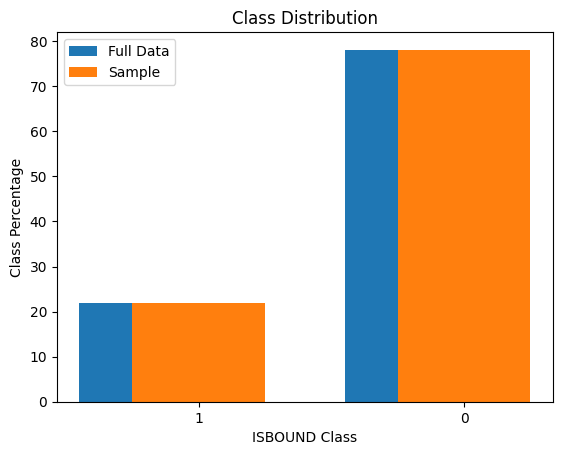

In [191]:
x = [0,1]
plt.bar(x,[100*sum(y)/len(y), 100*(len(y)-sum(y))/len(y)],tick_label=['1', '0'], label = 'Full Data',width=0.5)
x = list(map(lambda x: x+0.2, x))
plt.bar(x,[100*sum(y_train)/len(y_train), 100*(len(y_train)-sum(y_train))/len(y_train)],tick_label=['1', '0'],width=0.5, label='Sample')
plt.xlabel('ISBOUND Class')
plt.ylabel('Class Percentage')
plt.title('Class Distribution')
plt.legend();

# Model Training and Evaluation

**Class Imbalance:**

The data has class imbalance as only 22% of the customers bought insurance. We used the undersampling technique to create a balanced training set so that the models have equal number of samples from both classes to train on.
* Unbalanced training:
    * Same weights: The simplest step is to train a model on the training data as it is. This will be our baseline model.
* Balanced training:
    * Undersampling: We will start with selecting as many negative class samples as the positive class so that both have equal number in the training set.
    
**Model Selection:**
* We short-list 5 ML models in our work:
    * Logistic Regression
    * Support Vector Classifier
    * Random Forest
    * XGBoost
    * Neural network
* We do a crude grid search 5-fold cross-validation with few parameters for all models to select the best model.
* We then do a finer grid search 5-fold cross-validation to fine-tune the XGBoost model. We select the model with the highest mean ROC AUC.
* Once the final model is selected, we train the model on the entire training set to make predictions on the holdout validation set.
* For final model evaluation, we calculate the following performance measures on the validation set:
    * ROC AUC
    * Precision
    * Recall
    * F1 score
    * F2 score
    * Maximum lift

**Model Evaluation:**

We repeat the above steps for both the baseline and undersampling model. We find that XGBoost is the best model with the highest ROC AUC. Even though the ROC AUC of the baseline model is comparable to that of the undersampled model (0.673 vs. 0.669), the $F_1$, $F_2$ and recall scores of the undersampled model is a lot better because of balanced learning from both classes. Therefore, the final model selected is the model trained on undersampled data.  

Even though the undersampled model outperforms the baseline, it doesn't perform quite well on the validation set. Typically, the ROC AUC scores can be viewed as follows:

  * 0.50 - 0.59: no signal in data
  * 0.60 - 0.69: modest performance
  * 0.70 - 0.79: fair
  * 0.80 - 0.89: good
  * 0.90 and above: excellent

The ROC AUC of the final model on the validation set is only 0.669 making it a modestly performing model. The $F_1$, $F_2$, precision, and recall values are: 0.417, 0.535, 0.305, 0.659 respectively. Therefore, overall the dataset has limitations and can only modestly predict the outcome of buying insurance.  

**Feature importance:**

We also studied the features that were most important for the model in predicting the outcome. Multi-product and longitude were the two most important features, just like from univariate analysis.

## Imbalanced learning

### Normalization

In [192]:
# Extract numerical features from the reduced insurance training data
numerical_columns = list(X_train.select_dtypes(include=np.number).columns.values)

In [193]:
# Normalize our dataset

# Initialize MinMaxScaler to scale numerical features
scaler = MinMaxScaler()
# Fit the scaler to the training data for numerical features
X_transformer = scaler.fit(X_train[numerical_columns])
# Transform the training data using the fitted scaler
X_transform = X_transformer.transform(X_train[numerical_columns])

In [194]:
def normalized_matrix_to_df(original_df, normalized_matrix, normalized_features):
    '''
    This function returns a dataframe containing categorical columns and
    normalized numerical columns from a matrix containing normalized values.
    Args: original_df: Un-normalized dataframe
        normalized_matrix: matrix containing normalized values
        normalized_features: normalized feature names
    Returns: transformed_data_df: transformed/normalized dataframe
    '''
    # making a deep copy of training data
    transformed_data_df = original_df.copy()
    # replacing numerical values with normalized values
    transformed_data_df[normalized_features] = normalized_matrix

    return transformed_data_df

In [195]:
# converting normalized values to dataframe
transformed_train_data_df = normalized_matrix_to_df(X_train, X_transform, numerical_columns)

# looking at the first few rows of dataset
transformed_train_data_df.head()

,VEHICLEYEAR,ANNUAL_KM,COMMUTE_DISTANCE,VEHICLE_VALUE,YEAR_OF_BIRTH,YEARS_LICENSED,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,...,TOPVEHICLEMODELS_WRANGLER SAHARA 4WD,TOPVEHICLEMODELS_WRANGLER SPORT 4WD,TOPVEHICLEMODELS_WRANGLER UNLIMITED SAHARA 4DR 4WD,TOPVEHICLEMODELS_WRANGLER UNLIMITED SPORT 4DR 4WD,TOPVEHICLEMODELS_X1 28I 4DR AWD,TOPVEHICLEMODELS_X3 28I 4DR AWD,TOPVEHICLEMODELS_XV CROSSTREK TOURING 5DR AWD,TOPVEHICLEMODELS_YARIS 4DR,TOPVEHICLEMODELS_YARIS LE 4DR HATCHBACK,TOPVEHICLEMODELS_rare
4052,0.908046,0.101704,0.000667,0.031248,0.006809,0.226804,0.0000,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2427,0.873563,0.204956,0.002668,0.012498,0.005199,0.360825,0.0000,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
92279,0.942529,0.153330,0.006004,0.069998,0.007428,0.092784,0.0625,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
12461,0.908046,0.256582,0.026017,0.022998,0.005694,0.319588,0.0000,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
22332,0.954023,0.256582,0.009340,0.039998,0.008418,0.123711,0.0000,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True


In [196]:
X_val_transform = X_transformer.transform(X_val[numerical_columns])
transformed_val_data_df = normalized_matrix_to_df(X_val, X_val_transform, numerical_columns)
transformed_val_data_df.head()

,VEHICLEYEAR,ANNUAL_KM,COMMUTE_DISTANCE,VEHICLE_VALUE,YEAR_OF_BIRTH,YEARS_LICENSED,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,...,TOPVEHICLEMODELS_WRANGLER SAHARA 4WD,TOPVEHICLEMODELS_WRANGLER SPORT 4WD,TOPVEHICLEMODELS_WRANGLER UNLIMITED SAHARA 4DR 4WD,TOPVEHICLEMODELS_WRANGLER UNLIMITED SPORT 4DR 4WD,TOPVEHICLEMODELS_X1 28I 4DR AWD,TOPVEHICLEMODELS_X3 28I 4DR AWD,TOPVEHICLEMODELS_XV CROSSTREK TOURING 5DR AWD,TOPVEHICLEMODELS_YARIS 4DR,TOPVEHICLEMODELS_YARIS LE 4DR HATCHBACK,TOPVEHICLEMODELS_rare
29628,0.839080,0.256582,0.010007,0.010895,0.009037,0.041237,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
44267,0.977011,0.153330,0.009340,0.031706,0.008666,0.092784,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
7353,0.908046,0.256582,0.026017,0.019662,0.008789,0.082474,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
94201,0.885057,0.081053,0.006004,0.020198,0.003590,0.402062,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
69318,0.505747,0.101704,0.004670,0.001341,0.004085,0.463918,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True


In [197]:
# verifying that normalized train data shape is same as original train data
assert transformed_train_data_df.shape == X_train.shape

In [198]:
def convert_bool_to_int(df, features):
    '''
    This function converts boolean columns (obtained after converting
    categorical columns to dummy variables) to intergers.
    Args: df: dataframe containing boolean values
        features: boolean feature names
    Returns: df: updated dataframe containing integer values.
    '''
    # loop over categorical features
    for col in features:
        # converting boolean categorical variables to integer
        df[col] = df[col].astype(int)
    return df

In [199]:
# making a list of categorical variables
categorical_features = list(transformed_train_data_df.select_dtypes(include=['bool']).columns.values)
# converting boolean values to integer
transformed_train_data_df = convert_bool_to_int(transformed_train_data_df, categorical_features)

In [200]:
transformed_val_data_df = convert_bool_to_int(transformed_val_data_df, categorical_features)

In [201]:
transformed_train_data_df.head()

,VEHICLEYEAR,ANNUAL_KM,COMMUTE_DISTANCE,VEHICLE_VALUE,YEAR_OF_BIRTH,YEARS_LICENSED,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,...,TOPVEHICLEMODELS_WRANGLER SAHARA 4WD,TOPVEHICLEMODELS_WRANGLER SPORT 4WD,TOPVEHICLEMODELS_WRANGLER UNLIMITED SAHARA 4DR 4WD,TOPVEHICLEMODELS_WRANGLER UNLIMITED SPORT 4DR 4WD,TOPVEHICLEMODELS_X1 28I 4DR AWD,TOPVEHICLEMODELS_X3 28I 4DR AWD,TOPVEHICLEMODELS_XV CROSSTREK TOURING 5DR AWD,TOPVEHICLEMODELS_YARIS 4DR,TOPVEHICLEMODELS_YARIS LE 4DR HATCHBACK,TOPVEHICLEMODELS_rare
4052,0.908046,0.101704,0.000667,0.031248,0.006809,0.226804,0.0000,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2427,0.873563,0.204956,0.002668,0.012498,0.005199,0.360825,0.0000,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
92279,0.942529,0.153330,0.006004,0.069998,0.007428,0.092784,0.0625,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
12461,0.908046,0.256582,0.026017,0.022998,0.005694,0.319588,0.0000,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
22332,0.954023,0.256582,0.009340,0.039998,0.008418,0.123711,0.0000,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1


### Model selection

In [202]:
# let's try out some classifiers
estimators = {'logreg': LogisticRegression(solver = 'saga'),
'svc': LinearSVC(),
'rfc': RandomForestClassifier(),
'xgbc': XGBClassifier(),
'mlp': MLPClassifier(),
}

In [203]:
# creating grid serach parameters for each single model.
param_grid = {
    'logreg':
    {'C': [0.01, 0.1, 1, 10],
      'penalty': ['l1', 'l2']},

    'svc':
    {'C': [0.1,1,1.0]
    },

    'rfc': {'max_depth': [3, 5],
     'min_samples_leaf': [1, 3],
    'n_estimators': [100, 200]},

    'xgbc': {'max_depth': [1, 5, 10],
     'learning_rate': [0.1, 1., 10.],},

    'mlp':
    {'hidden_layer_sizes': [2,3,5,7]},
    }

In [204]:
def f2_score(true, pred):
    '''
    This function calculates F2 scores from ground truth and perdictions.
    Args: true: ground truth
        pred: predictions
    Returns: f2: F2 score
    '''
    tn, fp, fn, tp = confusion_matrix(true, pred).ravel()
    p = tp/(tp+fp)
    r = tp/(tp+fn)
    f2 = (5 * p * r) / (4 * p + r)
    return f2

def lift(true, pred):
    '''
    Function that calculates maximum lift value.
    Arguments:
        true: ground truth
        pred: predicted probabilities
    '''
    sorted_indices = np.argsort(pred)[::-1]
    n = len(sorted_indices)
    n_decile = n//10
    avg_rate = sum(true)/len(true)

    true = np.array(true)

    deciles = {}
    previous_decile = []
    split_arrays = np.array_split(sorted_indices, 10)
    decile_vals = [true[j] for j in split_arrays[0]]
    pred_rate = sum(decile_vals)/(len(decile_vals))

    return pred_rate/avg_rate

# dictionary containing verious performance metrics
scoring = {
    'roc_auc': 'roc_auc',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'f2': make_scorer(f2_score),
    'max_lift': make_scorer(lift, needs_proba = True)
          }

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


In [205]:
def model_testing(X, y, est, estimator):
    '''
    This function performs cross validation for variety of models.
    Args: X: training data
        y: output variable
        estimators: list of estimators
    Returns: est_scores_dict: dictionary containing performance scores from
    models
    '''
    # initialize dictionary containing estimators as keys and perforances scores as output.
    est_scores_dict = {}

    # Get the estimator object
    print(f'Start\n')
    # Record the start time for performance measurement
    start = time.time()
    # Perform cross-validation with the current estimator
    est_scores_dict[est] = cross_validate(estimator, X, y, n_jobs=-1, scoring=scoring);
    # Print a message indicating the completion of processing with the current estimator
    print(f'Finish\n')
    print('Time taken = ', round((time.time() - start)/60.,2) ,'mins \n')

    return est_scores_dict

In [206]:
def model_score(scores_dict, scoring):
    '''
    This function displays the scores from different classifiers in a
    dataframe.
    Args: scores_dict: Output dictionary from model_testing function
        scoring: dictionary containing various perfomance metrics
    Returns: mean_df: dataframe containing mean scores over k-fold
            cross-validation sets
            std_df: dataframe containing standard deviation scores over k-fold
            cross-validation sets
    '''
    # Create a set of score names with 'test_' prefix
    score_set = {'test_' + score for score in scoring.keys()}
    # Initialize dictionaries to store mean and standard deviation values
    mean_dict = {}
    std_dict = {}

    # Calculate mean and standard deviation for each estimator
    for estimator in scores_dict.keys():
        # Calculate mean for each score in the score set
        mean_dict[estimator] = {score: round(np.mean(scores_dict[estimator][score]),3) for score in score_set}
        # Calculate standard deviation for each score in the score set
        std_dict[estimator] = {score: round(np.std(scores_dict[estimator][score]),3) for score in score_set}

    # Create DataFrames from the mean and standard deviation dictionaries
    mean_df = pd.DataFrame(mean_dict)
    std_df = pd.DataFrame(std_dict)

    return mean_df, std_df

In [207]:
def best_scores_function(estimator, train_df, y_true, model_score_dict):
    '''
    The function sets up and performs grid search cv for any of the candidate models.
    Args: estimator: single/ensemble estimator
        model_score_dict: dictionary containing ROC AUC scores
    Returns:
        model_score_dict: dictionary containing updated ROC AUC scores
    '''
    # Check if the estimator is a single estimator or an ensemble estimator
    est = estimators[estimator]
    grid_search = GridSearchCV(est, param_grid[estimator], cv = 5, scoring = 'roc_auc', n_jobs=-1, refit=False)

    start = time.time()
    # Fit the grid search based on the estimator type
    grid_search.fit(train_df, y_true);
    print(f'{estimator} Grid Search Time Taken: ', round( (time.time() - start)/60., 3), ' mins')

    # grid search cv results
    est_scores = grid_search.cv_results_
    # Update the model F1 score dictionary with the maximum F1 score
    model_score_dict[estimator] = max(est_scores['mean_test_score'])

    return model_score_dict

In [208]:
# converting the training data to sparse matrix for faster computation
transformed_train_data_df_sparse = sparse.csr_matrix(transformed_train_data_df.values)

In [209]:
model_score_dict = {}
for est in estimators.keys():
    model_score_dict = best_scores_function(est, transformed_train_data_df_sparse, y_train, model_score_dict)

logreg Grid Search Time Taken:  0.376  mins
svc Grid Search Time Taken:  0.078  mins
rfc Grid Search Time Taken:  0.126  mins
xgbc Grid Search Time Taken:  0.057  mins
mlp Grid Search Time Taken:  0.692  mins


In [210]:
sort_dict(model_score_dict)

[('xgbc', 0.6731531451091115),
 ('rfc', 0.6342271188338076),
 ('logreg', 0.6081077599035212),
 ('svc', 0.5976622386398576),
 ('mlp', 0.5942709785161225)]

### Model Fine Tuning

In [211]:
# Setting up hyperparameter tuning
best_model_grid = {'max_depth': [1, 3, 5, None],
             'n_estimators': [50, 100, 150, None],
             'learning_rate': [0.01, 0.1, 1., None]}
best_model = estimators['xgbc']

In [212]:
grid_search = GridSearchCV(best_model, best_model_grid, cv = 5, scoring = 'roc_auc', refit=True, n_jobs=-1, return_train_score=True)

In [213]:
grid_search.fit(transformed_train_data_df_sparse, y_train);

In [214]:
best_est_unbalanced = grid_search.best_estimator_
best_est_unbalanced

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [215]:
best_est_unbalanced.fit(transformed_train_data_df_sparse, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

### Model evaluation

In [216]:
def calculate_metrics(true, prob, pred):
    '''
    Function that calculates various performance metrics.
    Arguments:
        true: ground truth
        prob: predicted probabilities
        pred: predicted output class
    '''
    roc_auc = roc_auc_score(true, prob)
    max_lift = lift(true, prob)
    f1 = metrics.f1_score(true, pred)
    f2 = metrics.fbeta_score(true, pred, beta = 2)
    precision = metrics.precision_score(true, pred)
    recall = metrics.recall_score(true, pred)

    scores_dict = {
        'roc_auc': round(roc_auc, 4),
        'max_lift': round(max_lift, 4),
        'f1': round(f1, 4),
        'f2': round(f2, 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
    }

    return scores_dict

In [217]:
transformed_val_data_df_sparse = sparse.csr_matrix(transformed_val_data_df.values)

In [218]:
y_prob_unbalanced = best_est_unbalanced.predict_proba(transformed_val_data_df_sparse)
y_pred_unbalanced = best_est_unbalanced.predict(transformed_val_data_df_sparse)

In [219]:
positive_class_probs = y_prob_unbalanced[:, 1]
scores_dict = calculate_metrics(y_val, positive_class_probs, y_pred_unbalanced)

val_scores_dict = {
'unbalanced': scores_dict
}

## Balanced learning

We try the balanced learning technique where we use random undersampling to select the same number of examples from both classes. Using this approach, the classifier has enough examples of both classes to learn from and might be better at predicting the output variable.

### Normalization

In [220]:
# Since the majority class is 0. Let's use the random under sampler to balance the class distribution in our training dataset as 80 percent of our dataset
# is under one class.  This is done so that our model works equally well for both the classes
rus = RandomUnderSampler(random_state = randN)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

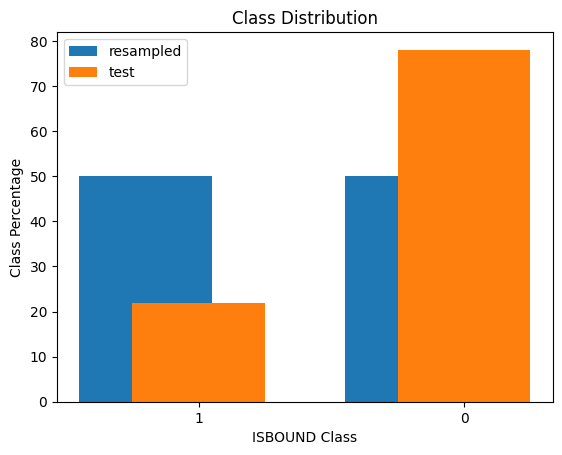

In [221]:
# See how the data will look after applying the random under sampler.
# We'll keep the class imbalance in the test set because
# that is reflective of the true distribution.
x = [0,1]
plt.bar(x,[100*sum(y_resampled)/len(y_resampled), 100*(1-sum(y_resampled)/len(y_resampled))],tick_label=['1', '0'],label='resampled', width = 0.5)
x = list(map(lambda x: x+0.2, x))
plt.bar(x,[100*sum(y_val)/len(y_val), 100*(1-sum(y_val)/len(y_val))],tick_label=['1', '0'],label='test', width = 0.5)
plt.xlabel('ISBOUND Class')
plt.ylabel('Class Percentage')
plt.title('Class Distribution')
plt.legend();

In [222]:
# Normalize our dataset
scaler = MinMaxScaler()
X_transformer = scaler.fit(X_resampled[numerical_columns])
X_transform = X_transformer.transform(X_resampled[numerical_columns])

In [223]:
# The one hot encoding function returns a matrix. let's extract the training set and convert it to dataframe.
resampled_train_data_df = normalized_matrix_to_df(X_resampled, X_transform, numerical_columns)
resampled_train_data_df = convert_bool_to_int(resampled_train_data_df, categorical_features)
resampled_train_data_df.head()

,VEHICLEYEAR,ANNUAL_KM,COMMUTE_DISTANCE,VEHICLE_VALUE,YEAR_OF_BIRTH,YEARS_LICENSED,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,...,TOPVEHICLEMODELS_WRANGLER SAHARA 4WD,TOPVEHICLEMODELS_WRANGLER SPORT 4WD,TOPVEHICLEMODELS_WRANGLER UNLIMITED SAHARA 4DR 4WD,TOPVEHICLEMODELS_WRANGLER UNLIMITED SPORT 4DR 4WD,TOPVEHICLEMODELS_X1 28I 4DR AWD,TOPVEHICLEMODELS_X3 28I 4DR AWD,TOPVEHICLEMODELS_XV CROSSTREK TOURING 5DR AWD,TOPVEHICLEMODELS_YARIS 4DR,TOPVEHICLEMODELS_YARIS LE 4DR HATCHBACK,TOPVEHICLEMODELS_rare
34970,0.790698,0.123356,0.006004,0.023269,0.001610,0.577320,0.0,0.0,0.00,0.0,...,0,0,0,0,0,0,0,0,0,0
54425,0.895349,0.123356,0.011341,0.039997,0.006438,0.072165,0.0,0.0,0.00,0.0,...,0,0,0,0,0,0,0,0,0,0
19584,0.965116,0.185974,0.006004,0.065888,0.007800,0.020619,0.1,0.0,0.25,0.0,...,0,0,0,0,0,0,0,0,0,1
85047,0.953488,0.085786,0.006004,0.040349,0.002229,0.608247,0.0,0.0,0.00,0.0,...,0,0,0,0,0,0,0,0,0,0
64539,0.697674,0.023168,0.006004,0.001815,0.004829,0.402062,0.0,0.0,0.00,0.0,...,0,0,0,0,0,0,0,0,0,1


In [224]:
# asserting shape of transformed dataframe is same as original dataframe
assert resampled_train_data_df.shape == X_resampled.shape

In [225]:
X_val_transform = X_transformer.transform(X_val[numerical_columns])
resampled_val_data_df = normalized_matrix_to_df(X_val, X_val_transform, numerical_columns)
resampled_val_data_df = convert_bool_to_int(resampled_val_data_df, categorical_features)
resampled_val_data_df.head()

,VEHICLEYEAR,ANNUAL_KM,COMMUTE_DISTANCE,VEHICLE_VALUE,YEAR_OF_BIRTH,YEARS_LICENSED,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,...,TOPVEHICLEMODELS_WRANGLER SAHARA 4WD,TOPVEHICLEMODELS_WRANGLER SPORT 4WD,TOPVEHICLEMODELS_WRANGLER UNLIMITED SAHARA 4DR 4WD,TOPVEHICLEMODELS_WRANGLER UNLIMITED SPORT 4DR 4WD,TOPVEHICLEMODELS_X1 28I 4DR AWD,TOPVEHICLEMODELS_X3 28I 4DR AWD,TOPVEHICLEMODELS_XV CROSSTREK TOURING 5DR AWD,TOPVEHICLEMODELS_YARIS 4DR,TOPVEHICLEMODELS_YARIS LE 4DR HATCHBACK,TOPVEHICLEMODELS_rare
29628,0.837209,0.311209,0.010007,0.015847,0.008914,0.041237,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
44267,0.976744,0.185974,0.009340,0.046117,0.008543,0.092784,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
7353,0.906977,0.311209,0.026017,0.028600,0.008667,0.082474,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
94201,0.883721,0.098309,0.006004,0.029379,0.003467,0.402062,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
69318,0.500000,0.123356,0.004670,0.001951,0.003962,0.463918,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1


In [226]:
# converting the balanced training set into sparse matrix
resampled_train_data_df_sparse = sparse.csr_matrix(resampled_train_data_df.values)

In [227]:
resampled_val_data_df_sparse = sparse.csr_matrix(resampled_val_data_df.values)

### Model selection

In [228]:
model_score_dict = {}
for est in estimators.keys():
    model_score_dict = best_scores_function(est, resampled_train_data_df_sparse, y_resampled, model_score_dict)

logreg Grid Search Time Taken:  0.126  mins
svc Grid Search Time Taken:  0.023  mins
rfc Grid Search Time Taken:  0.055  mins
xgbc Grid Search Time Taken:  0.032  mins
mlp Grid Search Time Taken:  0.393  mins


In [229]:
sort_dict(model_score_dict)

[('xgbc', 0.6679830957928994),
 ('rfc', 0.6355087713656056),
 ('logreg', 0.6063098505458336),
 ('svc', 0.5964201339856887),
 ('mlp', 0.5897161725293069)]

### Model fine-tuning

In [230]:
grid_search = GridSearchCV(best_model, best_model_grid, cv = 5, scoring = 'roc_auc', refit=True, n_jobs=-1, return_train_score=True)

In [231]:
grid_search.fit(resampled_train_data_df_sparse, y_resampled);

In [232]:
best_est_undersampled = grid_search.best_estimator_
best_est_undersampled

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [233]:
best_est_undersampled.fit(resampled_train_data_df_sparse, y_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

### Model evaluation

In [234]:
y_prob_undersampled = best_est_undersampled.predict_proba(resampled_val_data_df_sparse)
y_pred_undersampled = best_est_undersampled.predict(resampled_val_data_df_sparse)
positive_class_probs = y_prob_undersampled[:, 1]
scores_dict = calculate_metrics(y_val, positive_class_probs, y_pred_undersampled)

val_scores_dict['undersampled'] = scores_dict

In [235]:
val_scores_df = pd.DataFrame.from_dict(val_scores_dict, orient = 'index')
val_scores_df.head()

,roc_auc,max_lift,f1,f2,precision,recall
unbalanced,0.6732,1.8809,0.0040,0.0025,0.5294,0.0020
undersampled,0.6686,1.8293,0.4174,0.5353,0.3053,0.6594


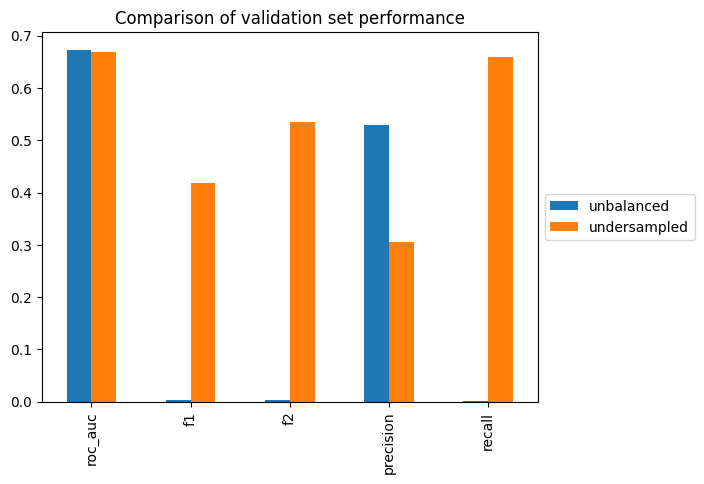

In [236]:
val_scores_df.drop(columns=['max_lift']).T.plot.bar()
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.title('Comparison of validation set performance');

In [237]:
def lift_chart(true, pred, n_splits = 10):
    '''
    Function that creates data points (x = sample proportion, y = lift values) for plotting lift curve.
    Arguments:
        true: ground truth
        pred: predicted probabilities
        n_splits: number of splits to be created in the sample
    '''
    sorted_indices = np.argsort(pred)[::-1]
    avg_rate = sum(true)/len(true)

    true = np.array(true)

    lift_vals = {}
    previous_decile = []
    split_arrays = np.array_split(sorted_indices, n_splits)
    composition = np.array([])
    for i, current in enumerate(split_arrays):
        decile_vals = [true[j] for j in current]
        decile_vals = np.concatenate((decile_vals, composition), axis=None)
        pred_rate = sum(decile_vals)/(len(decile_vals))
        lift_vals[i + 1] = pred_rate/avg_rate
        composition = decile_vals

    return lift_vals

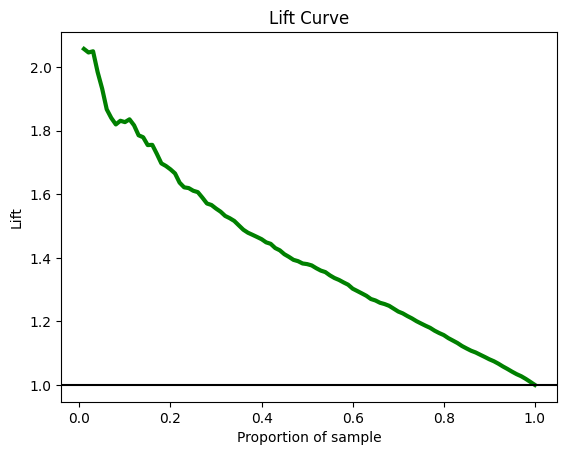

In [238]:
n_splits = 100
lift_values = lift_chart(y_val, y_prob_undersampled[:,1], n_splits)
x_vals = sorted(lift_values.keys())
y_vals = [lift_values[i] for i in x_vals]
plt.plot([val/n_splits for val in x_vals], y_vals, 'g-', linewidth = 3, markersize = 5)
plt.axhline(1, color = 'black')
plt.xlabel('Proportion of sample')
plt.ylabel('Lift')
plt.title('Lift Curve');

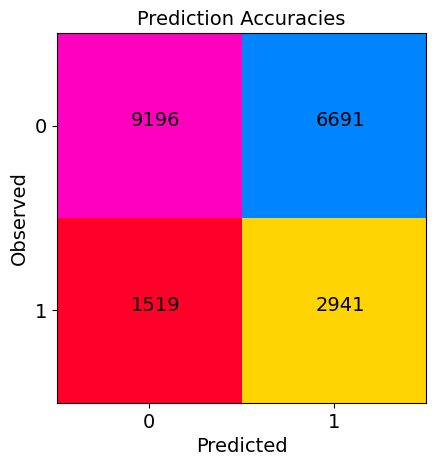

In [239]:
cm = confusion_matrix(y_val, y_pred_undersampled, labels=[0, 1])
plt.imshow(cm, cmap=plt.cm.gist_rainbow)
plt.xticks(ticks=[0, 1], labels=['0', '1'], fontsize=14)
plt.yticks(ticks=[0, 1], labels=['0', '1'], fontsize=14)
plt.ylabel('Observed', fontsize=14)
plt.xlabel('Predicted', fontsize=14)
plt.text(-0.1,0,round(cm[0,0]), fontsize=14)
plt.text(0.9,0,round(cm[0,1]), fontsize=14)
plt.text(-0.1,1,round(cm[1,0]), fontsize=14)
plt.text(0.9,1,round(cm[1,1]), fontsize=14)
plt.title('Prediction Accuracies', fontsize=14);

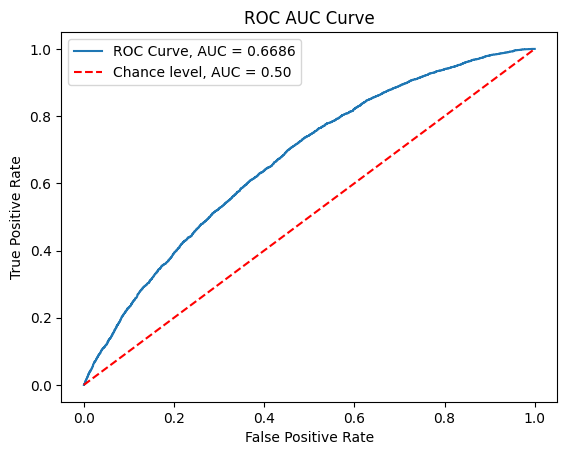

In [240]:
fpr, tpr, threshold = roc_curve(y_val, y_prob_undersampled[:, 1])
plt.plot(fpr, tpr, label = f'ROC Curve, AUC = {round(scores_dict["roc_auc"], 4)}')
plt.plot([0, 1], [0, 1],'r--', label = 'Chance level, AUC = 0.50')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC AUC Curve')
plt.legend();

## Feature Importances

We also look at feature importances to understand what features were important in distinguishing between the two classes. The most important feature is `MULTI_PRODUCT` which describes whether the insurance quote covers multiple products such as auto-home bundling or two or more vehicles covered by the same insurance policy. Longitude was the second most important feature.

In [ ]:
# looking at top 10 features
feature_importances_ind = np.argsort(best_est_undersampled.feature_importances_)[::-1]
feature_importances_ind[:10]

array([210,  12,   5, 199,   4, 211,  11,   8, 213, 473])

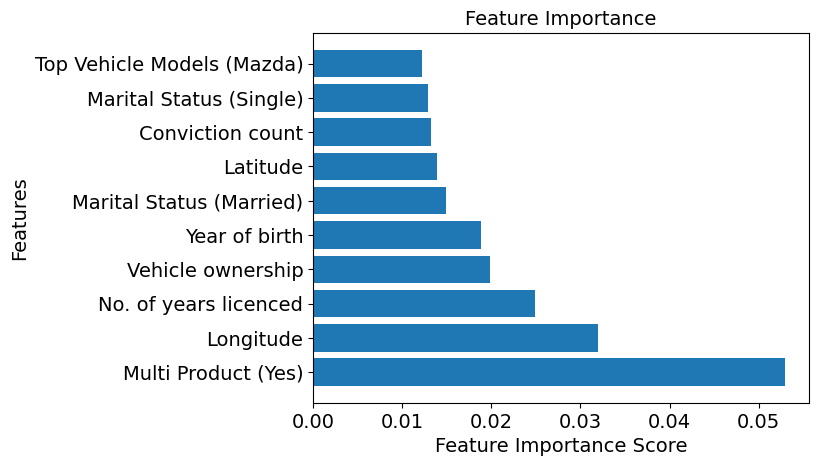

In [ ]:
top_10_features = feature_importances_ind[:10]
plt.barh(X_val.columns.values[top_10_features], best_est_undersampled.feature_importances_[top_10_features])
plt.xlabel('Feature Importance Score', fontsize = 14)
plt.ylabel('Features', fontsize = 14)
plt.title('Feature Importance', fontsize = 14)
plt.xticks(fontsize = 14);
plt.yticks(ticks = range(0,10), labels = ['Multi Product (Yes)', 'Longitude', 'No. of years licenced',
'Vehicle ownership', 'Year of birth', 'Marital Status (Married)', 'Latitude',
'Conviction count', 'Marital Status (Single)', 'Top Vehicle Models (Mazda)'], fontsize = 14);


## Final training

Let's do a final training of the best model using all Class 1 entries and an equal number of Class 0 entries in the training set. We'll use this model to predict the external test set.

In [241]:
X_resampled_final, y_resampled_final = rus.fit_resample(X, y)
print('Class Counts')
Counter(y_resampled_final)

Class Counts


Counter({0: 22267, 1: 22267})

In [242]:
X_transformer = scaler.fit(X_resampled_final[numerical_columns])

In [243]:
def data_preparation(df, numerical_features, categorical_features, transformer):
    '''
    This function uses the fitted scaler to scale the numerical features in
    the data, converts categorical columns to numerical using OHE and returns
    the final dataset.
    Args: df: dataframe,
    numerical_features: list of numerical features to be scaled,
    categorical_features: list of categorical features,
    transformer: fitted scaler on training set used to scale data
    Returns: resampled_final_data_df: Scaled and OHE dataset.
    '''
    # normalizing the dataset
    X_final_scaled = transformer.transform(df[numerical_features])
    # dataframe
    resampled_final_data_df = normalized_matrix_to_df(df, X_final_scaled, numerical_features)
    # bool to int
    resampled_final_data_df = convert_bool_to_int(resampled_final_data_df, categorical_features)

    return resampled_final_data_df

In [244]:
resampled_final_data_df = data_preparation(X_resampled_final, numerical_columns, categorical_features, X_transformer)

In [245]:
# training XGBoost on balanced data
final_model = best_est_undersampled.fit(resampled_final_data_df, y_resampled_final)

# Test set

Let's finish setting up the test set exactly like the train set. In the last step, we will make predictions using the final model. For sanity check, we will compare the probability distributions of the predicted values from the validation and test sets. We will also compare the number of positive and negative class predictions from the two sets.

In [269]:
insurance_test_data_reduced = pd.read_csv('processed_data/insurance_test_data_reduced.csv')
insurance_test_data_reduced.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15114 entries, 0 to 15113
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   VEHICLEYEAR                     15114 non-null  int64  
 1   VEHICLEMAKE                     15114 non-null  object 
 2   ANNUAL_KM                       15114 non-null  int64  
 3   COMMUTE_DISTANCE                15114 non-null  float64
 4   VEHICLE_OWNERSHIP               15114 non-null  object 
 5   VEHICLE_VALUE                   15114 non-null  float64
 6   VEHICLEUSE                      15114 non-null  object 
 7   GENDER                          15114 non-null  object 
 8   YEAR_OF_BIRTH                   15114 non-null  int64  
 9   YEARS_LICENSED                  15114 non-null  float64
 10  MULTI_PRODUCT                   15114 non-null  object 
 11  MARITAL_STATUS                  15114 non-null  object 
 12  OCCUPATION                      

In [248]:
insurance_test_data_reduced.head()

,VEHICLEYEAR,VEHICLEMAKE,ANNUAL_KM,COMMUTE_DISTANCE,VEHICLE_OWNERSHIP,VEHICLE_VALUE,VEHICLEUSE,GENDER,YEAR_OF_BIRTH,YEARS_LICENSED,...,OCCUPATION,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,SUSPENSION_COUNT,latitude,longitude,TOPVEHICLEMODELS,MONTH
0,2002,HONDA,10000,4.0,Undisclosed,8398.516667,Commute,Male,1993,7.0,...,Not Known,0,0,0,0,0,42.0549,-82.6062,rare,1
1,2010,FORD TRUCK/VAN,10000,10.0,Undisclosed,30210.791045,Commute,Male,1987,13.0,...,Not Known,0,0,0,0,0,48.4669,-81.3331,F150 XLT SUPERCREW 4WD,1
2,2017,DODGE/RAM TRUCK/VAN,9000,3.0,Owned,72000.000000,Commute,Male,1967,33.0,...,Not Known,0,0,0,0,0,45.3501,-80.0330,rare,1
3,2013,DODGE/RAM TRUCK/VAN,10000,10.0,Undisclosed,55000.000000,Commute,Male,1992,9.0,...,Not Known,0,0,0,0,0,60.7161,-135.0537,RAM 1500 SPORT CREW CAB 4WD,1
4,2014,FORD,20000,10.0,Undisclosed,26080.808000,Commute,Female,1995,4.0,...,Student,0,0,0,0,0,46.2437,-60.2313,FOCUS SE 4DR,1


In [249]:
# creating dummy variables
string_columns = insurance_test_data_reduced.select_dtypes(include='O').columns.values
prefix = {col: col for col in string_columns}
insurance_test_data_reduced_numerical = pd.get_dummies(insurance_test_data_reduced, prefix = prefix,
                          drop_first=True)

**Key Step**

Some categories in train set may not be present in test set. In order to overcome this, we use pd.reindex method to create such columns in the test set and set their values to zero.

In [250]:
insurance_test_data_reduced_numerical = insurance_test_data_reduced_numerical.reindex(columns = insurance_train_data_reduced_numerical.columns, fill_value=0)
insurance_test_data_reduced_numerical.drop(columns = ['IS_BOUND'], inplace = True)

In [252]:
final_test_data_df = data_preparation(insurance_test_data_reduced_numerical, numerical_columns, categorical_features, X_transformer)
final_test_data_df.head()

,VEHICLEYEAR,ANNUAL_KM,COMMUTE_DISTANCE,VEHICLE_VALUE,YEAR_OF_BIRTH,YEARS_LICENSED,CONVICTION_COUNT_MINOR_3YRS,CONVICTION_COUNT_MAJOR_3YRS,CONVICTION_COUNT_CRIMINAL_3YRS,ASSIGNED_LOSSES_PD_5YRS,...,TOPVEHICLEMODELS_WRANGLER SAHARA 4WD,TOPVEHICLEMODELS_WRANGLER SPORT 4WD,TOPVEHICLEMODELS_WRANGLER UNLIMITED SAHARA 4DR 4WD,TOPVEHICLEMODELS_WRANGLER UNLIMITED SPORT 4DR 4WD,TOPVEHICLEMODELS_X1 28I 4DR AWD,TOPVEHICLEMODELS_X3 28I 4DR AWD,TOPVEHICLEMODELS_XV CROSSTREK TOURING 5DR AWD,TOPVEHICLEMODELS_YARIS 4DR,TOPVEHICLEMODELS_YARIS LE 4DR HATCHBACK,TOPVEHICLEMODELS_rare
0,0.806818,0.100664,0.002001,0.010496,0.008790,0.072165,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
1,0.897727,0.100664,0.006004,0.037761,0.008048,0.134021,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0.977273,0.090445,0.001334,0.089998,0.005571,0.340206,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
3,0.931818,0.100664,0.006004,0.068748,0.008667,0.092784,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0.943182,0.202862,0.006004,0.032599,0.009038,0.041237,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [253]:
# asserting that the number of columns in test dataset is same as training set
assert final_test_data_df.shape[1] == resampled_train_data_df.shape[1]

In [254]:
y_preds = final_model.predict(final_test_data_df)

In [255]:
y_preds_list = y_preds.tolist()

In [262]:
test_proba = final_model.predict_proba(final_test_data_df)

**Key observation:** The distribution of predicted probabilities for the validation and test set are comparable. Additionally, the frequency of positive class predicted in both validation and test sets are comparable.

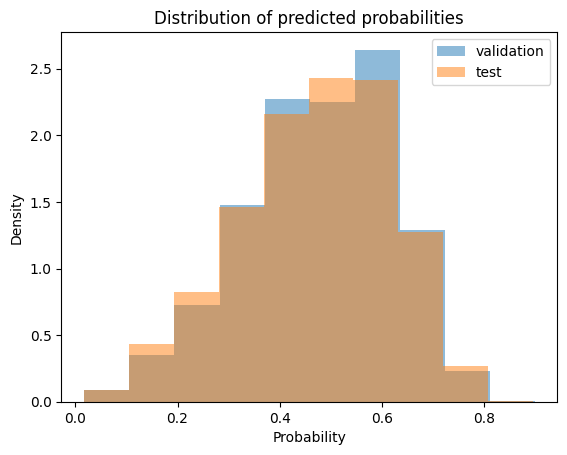

In [272]:
plt.hist(y_prob_undersampled[:,1], density = True, alpha = 0.5, label = 'validation')
plt.hist(test_proba[:,1], density = True, alpha = 0.5, label = 'test')
plt.title('Distribution of predicted probabilities')
plt.xlabel('Probability')
plt.ylabel('Density')
plt.legend();

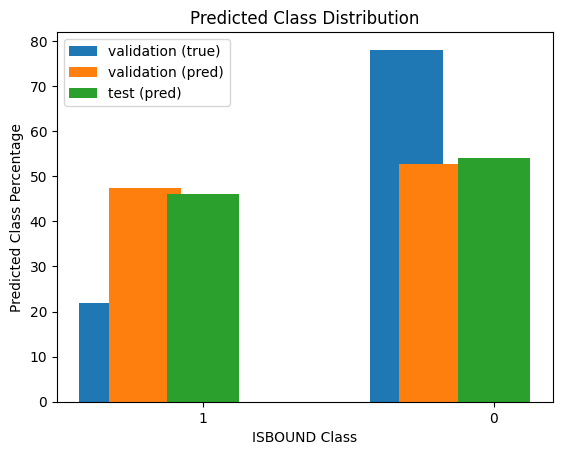

In [282]:
x = [0,1]
plt.bar(x,[100*sum(y_val)/len(y_val), 100*(1-sum(y_val)/len(y_val))],tick_label=['1', '0'],label='validation (true)', width = 0.25)
x = list(map(lambda x: x+0.1, x))
plt.bar(x,[100*sum(y_pred_undersampled)/len(y_pred_undersampled), 100*(1-sum(y_pred_undersampled)/len(y_pred_undersampled))],tick_label=['1', '0'],label='validation (pred)', width = 0.25)
x = list(map(lambda x: x+0.2, x))
plt.bar(x,[100*sum(y_preds)/len(y_preds), 100*(1-sum(y_preds)/len(y_preds))],tick_label=['1', '0'],label='test (pred)', width = 0.25)
plt.xlabel('ISBOUND Class')
plt.ylabel('Predicted Class Percentage')
plt.title('Predicted Class Distribution')
plt.legend();